# DBTS Train-Only Diagnostic — Full Architecture (In-Sample Sanity Check)

**Goal:** Can the system learn *anything* on data it has already seen?

**Pipeline (train set only):**
1. `build_panel` — regressors (shadow + return) for ALL candidates, walk-forward OOS features
2. `GlobalSignalClassifier.fit` — trained on 100% of train, no validation split, balanced class weights
3. DBTS daily scoring — Thompson Sampling + |residual_z| + |predicted_return| + ADF
4. `PositionManager` — rules-based ENTER / HOLD / EXIT / FLIP per sector
5. Metrics + plots — Sharpe, Win Rate, Drawdown, Equity Curve

**No OOS. No tuning. No validation. Pure memorization check.**


In [1]:
# Cell 1 — TRAIN-ONLY safety switch
TRAIN_ONLY_MODE = True
ALLOW_ANY_NON_TRAIN_DATA = False

assert TRAIN_ONLY_MODE is True
assert ALLOW_ANY_NON_TRAIN_DATA is False

print("TRAIN-ONLY MODE ACTIVE")
print("TRAIN used for fitting: YES")
print("TRAIN used for DBTS diagnostics/evaluation: YES")
print("Any non-train data used: NO")


TRAIN-ONLY MODE ACTIVE
TRAIN used for fitting: YES
TRAIN used for DBTS diagnostics/evaluation: YES
Any non-train data used: NO


In [2]:
# Cell 2 — imports and project path setup
import os
import sys
import math
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings("ignore")
%matplotlib inline

# Adjust this if your project lives elsewhere.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "strategy").exists():
    candidate = Path(r"C:\algo-trading-project")
    if candidate.exists():
        PROJECT_ROOT = candidate

sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")


Project root: C:\algo-trading-project


In [3]:
# Cell 3 — project imports
from config import SECTORS
from strategy.strategy_config import StrategyConfig
from strategy.pipeline import StrategyPipeline
from strategy.splits import chrono_split, walk_forward_folds
from strategy.predictor_selector import PredictorSelector
from strategy.regressors import DynamicShadowPriceModel, DynamicReturnModel
from strategy.residual_features import ResidualFeatureBuilder
from strategy.technical_features import TechnicalRuleFeatureBuilder
from strategy.bandit_target_selector import BanditTargetSelector
from strategy.classifier import GlobalSignalClassifier, make_labels

print("Project imports loaded.")


Project imports loaded.


In [4]:
# Cell 4 — helpers

def safe_price(prices, ticker, date):
    try:
        v = float(prices.at[date, ticker])
        return v if math.isfinite(v) and v > 0 else float("nan")
    except Exception:
        return float("nan")


def make_actual_label(price_series, cfg):
    return make_labels(price_series, cfg)


def signal_name(x):
    return {-1: "short", 0: "flat", 1: "long"}.get(int(x), str(x)) if pd.notna(x) else "nan"


def max_drawdown(equity):
    if equity.empty:
        return float("nan")
    peak = equity.cummax()
    return float((equity / peak - 1.0).min())


def pm_portfolio_metrics(pm_df, periods_per_year=252):
    """
    Portfolio metrics from PositionManager output.
    pm_df has one row per (date, sector/target) with columns:
      net_pnl, position, is_entry, is_exit, action, signal, date, sector, target
    Sectors trade in parallel → average net_pnl across active sectors per day,
    then compound.
    """
    if pm_df.empty:
        return pd.Series(dtype=float)

    # daily portfolio return = average net_pnl across all sectors that day
    daily_ret = pm_df.groupby("date")["net_pnl"].mean().sort_index()
    if daily_ret.empty:
        return pd.Series(dtype=float)

    equity = (1.0 + daily_ret).cumprod()
    cum = float(equity.iloc[-1] - 1.0)
    n = len(daily_ret)
    ann_ret = float((1.0 + cum) ** (periods_per_year / max(n, 1)) - 1.0)
    ann_vol = float(daily_ret.std(ddof=1) * np.sqrt(periods_per_year)) if n > 1 else np.nan
    sharpe = ann_ret / ann_vol if ann_vol and np.isfinite(ann_vol) and ann_vol != 0 else np.nan
    dn = daily_ret[daily_ret < 0]
    dn_vol = float(dn.std(ddof=1) * np.sqrt(periods_per_year)) if len(dn) > 1 else np.nan
    sortino = ann_ret / dn_vol if dn_vol and np.isfinite(dn_vol) and dn_vol != 0 else np.nan

    entries = pm_df[pm_df.get("is_entry", pd.Series(False, index=pm_df.index)) == True]
    active = pm_df[pm_df["position"] != 0]

    return pd.Series({
        "trading_days":          n,
        "total_entries":         int(len(entries)),
        "long_entries":          int((entries["position"] == 1).sum()) if not entries.empty else 0,
        "short_entries":         int((entries["position"] == -1).sum()) if not entries.empty else 0,
        "active_days":           int((active["position"] != 0).sum()),
        "cumulative_return":     round(cum, 4),
        "annualized_return":     round(ann_ret, 4),
        "annualized_volatility": round(ann_vol, 4) if np.isfinite(ann_vol) else np.nan,
        "sharpe":                round(sharpe, 4) if np.isfinite(sharpe) else np.nan,
        "sortino":               round(sortino, 4) if np.isfinite(sortino) else np.nan,
        "max_drawdown":          round(max_drawdown(equity), 4),
        "win_rate_days":         round(float((daily_ret > 0).mean()), 4),
        "avg_daily_pnl":         round(float(daily_ret.mean()), 6),
    })


In [5]:
# Cell 5 — load data and define TRAIN ONLY index
# This cell creates exactly one active date index: train_idx.
# No validation/test index is created, counted, printed, or used.

cfg = StrategyConfig(force_recompute=True, make_plots=False)
pipeline = StrategyPipeline(cfg)

print("Loading market data...")
md = pipeline.load_data()
split = chrono_split(md.prices.index, cfg)

train_idx = pd.DatetimeIndex(split.train_idx).sort_values()
horizon_buffer = int(max(getattr(cfg, "label_horizon", 1), getattr(cfg, "return_horizon", 1)))

# Dates that can safely have forward labels/exits without looking outside train.
train_fit_idx = train_idx[:-horizon_buffer] if len(train_idx) > horizon_buffer else train_idx[:0]
train_run_idx = train_idx[:-horizon_buffer] if len(train_idx) > horizon_buffer else train_idx[:0]

print("ACTIVE EXPERIMENT SPLIT USAGE:")
print(f"TRAIN used for fitting: YES | {train_idx[0].date()} -> {train_idx[-1].date()} | n={len(train_idx)}")
print(f"TRAIN safe fit/eval dates: {train_fit_idx[0].date()} -> {train_fit_idx[-1].date()} | n={len(train_fit_idx)}")
print("Any non-train dates used: NO")
print(f"Forward horizon buffer removed from train tail: {horizon_buffer} trading days")

assert len(train_idx) > 0
assert len(train_fit_idx) > 0
assert train_fit_idx.max() <= train_idx.max()
assert train_run_idx.max() <= train_idx.max()


Loading market data...
[cache] FORCE market_data__4adce62649ea.pkl -> computing
[fetch] 120 tickers | 2021-01-01 -> today | 1d


[INFO] 203 returns exceed 15% — kept
[load] Ready — 1361 trading days x 120 stocks
ACTIVE EXPERIMENT SPLIT USAGE:
TRAIN used for fitting: YES | 2021-01-04 -> 2024-04-03 | n=817
TRAIN safe fit/eval dates: 2021-01-04 -> 2024-04-02 | n=816
Any non-train dates used: NO
Forward horizon buffer removed from train tail: 1 trading days


In [6]:
# Cell 6 — build TRAIN-only panel and fit classifier on 100% of TRAIN
# NO internal 80/20 split. NO validation. NO test.
# Balanced class weights are applied in the single fit call so SHORT is not suppressed.
#
# DIAGNOSTIC OVERRIDE: Production cfg uses min_train_days=756 which with 816
# train days produces only 2 walk-forward folds (~59 predict dates: Jan-Apr 2024).
# For a full-period diagnostic we override to min_train_days=120 (6 months),
# giving ~14 folds that cover the ENTIRE train period from mid-2021 onward.
# This does NOT change the production pipeline or strategy_config.py.
import dataclasses
_diag_cfg = dataclasses.replace(cfg, min_train_days=120)
train_folds = walk_forward_folds(train_fit_idx, _diag_cfg)
print(f"TRAIN-only folds (diagnostic, min_train_days=120): {len(train_folds)}")
for i, f in enumerate(train_folds, 1):
    print(f"  fold {i:02d}: train={len(f.train_idx):4d} | predict={len(f.predict_idx):3d} | retrain={f.retrain_date.date()}")

# ── Bug 1 fix: guarantee a fresh feature panel regardless of force_recompute ──
_panel_cache_path = pipeline.cache._path("feature_panel", "pkl", "panel")
if _panel_cache_path.exists():
    _panel_cache_path.unlink()
    print(f"Deleted stale feature_panel cache: {_panel_cache_path.name}")
else:
    print("No stale feature_panel cache found — building fresh.")

print("Building TRAIN-only feature panel...")
panel = pipeline.build_panel(md, train_folds, split)
panel["date"] = pd.to_datetime(panel["date"])
panel = panel[panel["date"].isin(train_fit_idx)].copy()
print(f"Panel rows after strict TRAIN-only filter: {len(panel):,}")
print(f"Panel dates covered: {panel['date'].nunique()} | {panel['date'].min().date()} → {panel['date'].max().date()}")

excluded = (
    "date", "etf", "sector", "target", "predictors", "target_price",
    "shadow_price", "next_ret", "label", "spread_signal",
    "ann_vol", "residual_z", "price_residual", "residual_ewm_mean",
    "residual_ewm_std", "residual_roll_mean", "residual_roll_std",
    # predicted_return is the raw walk-forward OOS regressor output.
    # It is kept in the panel for DBTS scoring (Cell 8) but must NOT be a
    # classifier feature — it would be a direct proxy for the label.
    "predicted_return",
    # --- Suspect leaks removed (per user request, 2026-06-03) ---
    # candidate_price : raw $-level price → non-stationary + ticker identity proxy
    # dbts_score      : aggregate of residual_z + bandit posterior + predicted_return
    #                   (residual_z & predicted_return are explicitly excluded above —
    #                    do not let them back in via this aggregate).
    # was_selected_by_dbts : 0/1 "did DBTS pick me today". At inference time it is
    #                   always 1 (we only classify the selected candidate), so it
    #                   is a soft proxy for the DBTS score itself.
    "candidate_price", "dbts_score", "was_selected_by_dbts",
)
feature_cols = [c for c in panel.columns if c not in excluded]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(panel[c])]

if not feature_cols:
    raise ValueError("No numeric feature columns found in TRAIN-only panel.")

data = panel.dropna(subset=["label"]).copy()
X = data[feature_cols].apply(pd.to_numeric, errors="coerce")
X = X.groupby(data["target"]).ffill().fillna(0.0)
for c in feature_cols:
    data[c] = X[c]
data = data.sort_values("date")

print(f"Classifier training rows — 100% TRAIN, no split: {len(data):,}")
print("Label distribution:")
display(data["label"].value_counts().sort_index().rename(index={-1: "short", 0: "flat", 1: "long"}).to_frame("count"))

# Visibility on what dropped vs. what stayed
_all_panel_cols = list(panel.columns)
_dropped_excluded = [c for c in _all_panel_cols if c in excluded]
_dropped_nonnumeric = [c for c in _all_panel_cols
                      if c not in excluded and not pd.api.types.is_numeric_dtype(panel[c])]
print(f"\nFeature accounting:")
print(f"  total panel cols : {len(_all_panel_cols)}")
print(f"  excluded         : {len(_dropped_excluded)}")
print(f"  non-numeric      : {len(_dropped_nonnumeric)} ({_dropped_nonnumeric})")
print(f"  classifier feats : {len(feature_cols)}")

# ── Fit on ALL TRAIN data with balanced class weights in one pass ───────────
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier as _XGBCls

_p = dict(cfg.clf_params)
_p.update({"num_class": 3, "objective": "multi:softprob", "verbosity": 0,
           "random_state": int(cfg.random_state)})

_X = data[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)
_y = data["label"].map({-1: 0, 0: 1, 1: 2}).astype(int)
_sw = compute_sample_weight(class_weight="balanced", y=_y)

clf = GlobalSignalClassifier(cfg)
clf.features_ = feature_cols
clf_bal = _XGBCls(**_p)
clf_bal.fit(_X, _y, sample_weight=_sw)
clf.model_ = clf_bal

_wmap = {nm: round(float(_sw[(_y == i).values].mean()), 3)
         for i, nm in enumerate(["short", "flat", "long"])}
print(f"\nClassifier fit complete.")
print(f"  Samples: {len(_y):,}  |  Balanced weights: {_wmap}")

imp = pd.Series(clf_bal.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Top 20 feature importances:")
display(imp.head(20).to_frame("importance"))


TRAIN-only folds (diagnostic, min_train_days=120): 14
  fold 01: train= 120 | predict= 50 | retrain=2021-06-25
  fold 02: train= 170 | predict= 50 | retrain=2021-09-07
  fold 03: train= 220 | predict= 50 | retrain=2021-11-16
  fold 04: train= 270 | predict= 50 | retrain=2022-01-28
  fold 05: train= 320 | predict= 50 | retrain=2022-04-11
  fold 06: train= 370 | predict= 50 | retrain=2022-06-23
  fold 07: train= 420 | predict= 50 | retrain=2022-09-02
  fold 08: train= 470 | predict= 50 | retrain=2022-11-14
  fold 09: train= 520 | predict= 50 | retrain=2023-01-27
  fold 10: train= 570 | predict= 50 | retrain=2023-04-11
  fold 11: train= 620 | predict= 50 | retrain=2023-06-22
  fold 12: train= 670 | predict= 50 | retrain=2023-09-01
  fold 13: train= 720 | predict= 50 | retrain=2023-11-13
  fold 14: train= 770 | predict= 46 | retrain=2024-01-26
Deleted stale feature_panel cache: feature_panel__4e683b3501b5.pkl
Building TRAIN-only feature panel...
[cache] FORCE feature_panel__4e683b3501b5.pk


  OOS modelling — Materials (XLB)



  OOS modelling — Communication (XLC)



  OOS modelling — Energy (XLE)



  OOS modelling — Financials (XLF)


...

Panel rows after strict TRAIN-only filter: 76,560
Panel dates covered: 696 | 2021-06-25 → 2024-04-02
Classifier training rows — 100% TRAIN, no split: 75,190
Label distribution:


,count
label,
short,7528
flat,60776
long,6886



Feature accounting:
  total panel cols : 87
  excluded         : 20
  non-numeric      : 0 ([])
  classifier feats : 67



Classifier fit complete.
  Samples: 75,190  |  Balanced weights: {'short': 3.329, 'flat': 0.412, 'long': 3.64}
Top 20 feature importances:


,importance
residual_ewm_z,0.295188
price_residual_z,0.270737
residual_excursion_bucket,0.257900
residual_rank,0.045556
residual_percentile,0.038389
residual_abs_z,0.022653
rule_breakout_20,0.003940
shadow_price_gap_pct,0.002884
residual_ewm_slope,0.002562
px_ema200_ratio_z,0.002374


In [7]:
# Cell 6b — panel shape diagnostic
print(f"panel total rows:         {len(panel):,}")
print(f"panel dates (unique):     {panel['date'].nunique()}")
print(f"panel date range:         {panel['date'].min().date()} → {panel['date'].max().date()}")
print(f"panel targets (unique):   {panel['target'].nunique() if 'target' in panel.columns else panel.get('candidate', panel).nunique()}")
print(f"panel label non-NaN rows: {panel['label'].notna().sum():,}")
print(f"panel predicted_return:   {'YES' in str('YES' if 'predicted_return' in panel.columns else 'NO')}")
print(f"\ntrain_fit_idx range: {train_fit_idx[0].date()} → {train_fit_idx[-1].date()} | n={len(train_fit_idx)}")
print(f"train_folds: {len(train_folds)} folds")
if train_folds:
    print(f"  first fold predict_idx: {train_folds[0].predict_idx[0].date()} → {train_folds[0].predict_idx[-1].date()}")
    print(f"  last  fold predict_idx: {train_folds[-1].predict_idx[0].date()} → {train_folds[-1].predict_idx[-1].date()}")


panel total rows:         76,560
panel dates (unique):     696
panel date range:         2021-06-25 → 2024-04-02
panel targets (unique):   110
panel label non-NaN rows: 75,190
panel predicted_return:   True

train_fit_idx range: 2021-01-04 → 2024-04-02 | n=816
train_folds: 14 folds
  first fold predict_idx: 2021-06-25 → 2021-09-03
  last  fold predict_idx: 2024-01-26 → 2024-04-02


---

## SECTION B — Label Diagnostics (Cells 6c → 6i)

These cells were the investigative chain that led to the **production switch to reversion labels** now active in `strategy/pipeline.py` (`cfg.use_reversion_labels=True`).

### Run order (top-to-bottom)
| # | Cell | Produces (used by later cells) |
|---|---|---|
| 6c | OPTION C diagnostic A/B | `clf_old`, `clf_new`, `panel_rev`, `feature_cols` |
| 6d | Horizon sweep (Check 3) | `res_df` |
| 6e | Bucketed horizon sweep | `res_b` |
| 6f | Upstream residual_z audit | `audit` |
| 6g | PM sweep on prod labels (zero trades) | `res_df` (sweep) |
| 6h | Entry-gate funnel | reveals classifier saturation |
| 6i | A/B PM with reversion classifier | `clf_h12`, `sp_h12`, `sweep_df` — the validating run |

### Re-running for fresh comparison
Production now uses reversion labels, so `panel["label"]` IS the reversion label. To reproduce the OLD vs NEW A/B in 6c, temporarily set `cfg.use_reversion_labels = False` before Cell 5 and re-run Cells 5 → 6.

### Production change applied
- `strategy/strategy_config.py`: added `use_reversion_labels` (=True), `reversion_label_horizon` (=5), `reversion_entry_band` (=1.0), `reversion_close_band` (=0.5), `use_class_balanced_weights` (=True).
- `strategy/pipeline.py`: `build_panel` emits reversion labels from `residual_ewm_z` when the flag is on.
- `strategy/classifier.py`: `fit` applies `class_weight='balanced'` sample weights when the flag is on.

---

OPTION C DIAGNOSTIC — reversion-based labels (no production changes)
Parameters: h=5 days | entry_band=1.0 | close_band=0.5

── CHECK 1: Reversion label distribution ──
  Valid rows: 75,190 / 76,560 (98.2%)


,share
label_reversion,
short,0.1001
flat,0.8083
long,0.0916


  ✓ flat share 80.8% — within healthy range.

── CHECK 2: Economic validity (label vs realized residual_z change) ──


,count,mean,median,std
label_reversion,,,,
short(-1),7528,-1.3588,-1.0652,0.9835
flat(0),60776,0.0197,0.0183,0.8550
long(+1),6886,1.3239,1.0492,1.1959


  Expected:  long(+1) mean delta_rz > 0  (got 1.324)
             short(-1) mean delta_rz < 0 (got -1.359)
  Tautology note: labels are derived from delta_rz, so signs MUST match by construction.
  Real check: |mean delta| should be substantially > close_band=0.5.

── CHECK 3: Base rate of reversion ──
  Of all panel rows with |residual_z| > 1.0,
  what % have |residual_z(t+5)| < 0.5?
  n extreme rows: 28,076
  base rate of reversion: 17.8%
  starts expensive (rz>+1.0): reversion rate = 16.2% (n=15,117)
  starts cheap     (rz<-1.0): reversion rate = 19.7% (n=12,959)

  ⚠ Base rate < 25% — reversion is weak in this data. 
     Switching label scheme alone is unlikely to fix the engine.

── CHECK 4: A/B classifier max-prob comparison (same X, two labels) ──


  Aligned rows for A/B: 75,190
  y_old (fwd_return ±1%) distribution: {'flat': 60776, 'short': 7528, 'long': 6886}
  y_new (reversion)     distribution: {'flat': 60776, 'short': 7528, 'long': 6886}



,max_prob_threshold,OLD pass_n,OLD pass_%,NEW pass_n,NEW pass_%
0,0.40,75190,100.00,75190,100.00
1,0.45,75190,100.00,75190,100.00
2,0.50,75190,100.00,75190,100.00
3,0.55,75184,99.99,75184,99.99
4,0.60,75170,99.97,75170,99.97
5,0.65,75136,99.93,75136,99.93
6,0.70,75043,99.80,75043,99.80


  OLD max-prob: mean=0.955 | median=1.000 | max=1.000
  NEW max-prob: mean=0.955 | median=1.000 | max=1.000

  Δ pass-rate at 0.60 gate: +0.00 percentage points
  ✗ No improvement — softmax flatness is driven by the FEATURES, not the labels.



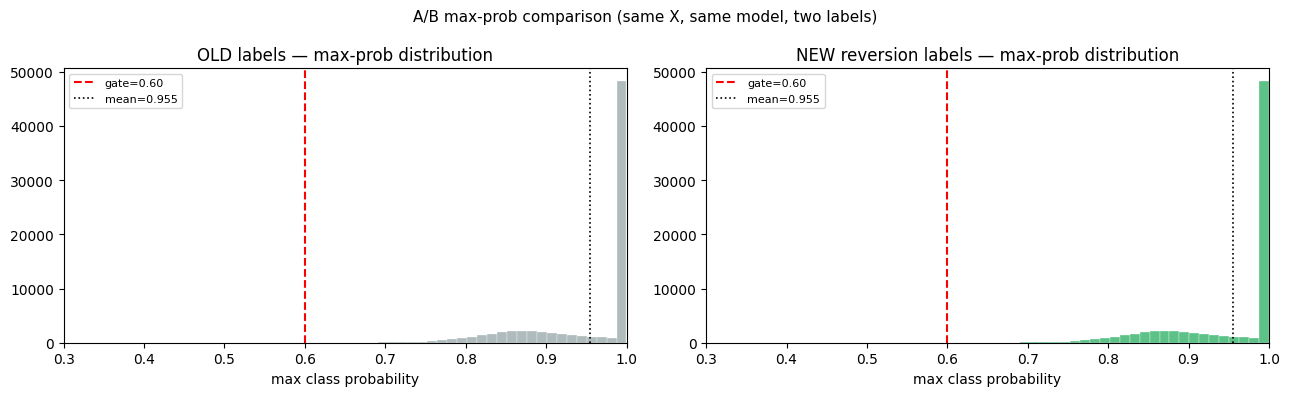

END OPTION C DIAGNOSTIC — production cfg/classifier untouched.


In [8]:
# Cell 6c — OPTION C diagnostic: reversion-based labels (A/B vs current)
# READ-ONLY w.r.t. production:
#   - does NOT modify build_panel, strategy_config, or make_labels.
#   - re-uses the already-built `panel`, `feature_cols`, and `data` from Cell 6.
#   - trains a second XGBClassifier on the same X with reversion labels, then
#     compares the max-prob distribution on the same rows.
#
# Four checks per the analysis:
#   1. Label distribution under option C (target: ~70-80% flat, ~10-15% each side)
#   2. Economic validity: do +1 labels actually correspond to rz reverting up?
#   3. Base rate of reversion: of all |rz|>1 events, what % revert within h days?
#   4. A/B: max-prob distribution of NEW classifier vs CURRENT classifier on same rows.
#
# DOES NOT change cfg, classifier, build_panel, or PositionManager.

from strategy.reversion_labels import make_reversion_labels_on_panel
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier as _XGBCls_rev

# Tunable diagnostic parameters (NOT written back to cfg)
REV_H          = 5     # reversion horizon (days)
REV_ENTRY_BAND = 1.0   # |rz| must exceed this to be a candidate for non-flat label
REV_CLOSE_BAND = 0.5   # rz must move at least this much in the closing direction

print("=" * 70)
print("OPTION C DIAGNOSTIC — reversion-based labels (no production changes)")
print("=" * 70)
print(f"Parameters: h={REV_H} days | entry_band={REV_ENTRY_BAND} | close_band={REV_CLOSE_BAND}")
print()

# ── Build reversion labels on the existing panel ───────────────────────────
rev_labels = make_reversion_labels_on_panel(
    panel, h=REV_H, entry_band=REV_ENTRY_BAND, close_band=REV_CLOSE_BAND,
    date_col="date", cand_col="target", rz_col="residual_z",
)
panel_rev = panel.copy()
panel_rev["label_reversion"] = rev_labels.values

# ──────────────────────────────────────────────────────────────────────────
# CHECK 1 — Label distribution
# ──────────────────────────────────────────────────────────────────────────
print("── CHECK 1: Reversion label distribution ──")
valid_rev = panel_rev.dropna(subset=["label_reversion"])
dist = (valid_rev["label_reversion"]
        .value_counts(normalize=True)
        .sort_index()
        .rename(index={-1.0: "short", 0.0: "flat", 1.0: "long"}))
print(f"  Valid rows: {len(valid_rev):,} / {len(panel_rev):,} "
      f"({len(valid_rev)/max(1,len(panel_rev))*100:.1f}%)")
display(dist.to_frame("share").round(4))
flat_pct = float(dist.get("flat", 0)) * 100
if flat_pct > 95:
    print(f"  ⚠ flat={flat_pct:.1f}% — entry_band={REV_ENTRY_BAND} may be too wide, "
          "or reversion is rare. Consider lowering entry_band.")
elif flat_pct < 50:
    print(f"  ⚠ flat={flat_pct:.1f}% — entry_band={REV_ENTRY_BAND} too narrow.")
else:
    print(f"  ✓ flat share {flat_pct:.1f}% — within healthy range.")
print()

# ──────────────────────────────────────────────────────────────────────────
# CHECK 2 — Economic validity (label vs realized rz_future)
# ──────────────────────────────────────────────────────────────────────────
print("── CHECK 2: Economic validity (label vs realized residual_z change) ──")
# Build rz_future per candidate (same shift used internally) for verification.
panel_sorted = panel_rev.sort_values(["target", "date"]).copy()
panel_sorted["residual_z_future"] = panel_sorted.groupby("target")["residual_z"].shift(-REV_H)
panel_sorted["delta_rz"] = panel_sorted["residual_z_future"] - panel_sorted["residual_z"]

econ = (panel_sorted.dropna(subset=["label_reversion", "delta_rz"])
        .groupby("label_reversion")["delta_rz"]
        .agg(["count", "mean", "median", "std"])
        .round(4)
        .rename(index={-1.0: "short(-1)", 0.0: "flat(0)", 1.0: "long(+1)"}))
display(econ)
mean_long  = econ.loc["long(+1)", "mean"]  if "long(+1)"  in econ.index else float("nan")
mean_short = econ.loc["short(-1)", "mean"] if "short(-1)" in econ.index else float("nan")
print(f"  Expected:  long(+1) mean delta_rz > 0  (got {mean_long:.3f})")
print(f"             short(-1) mean delta_rz < 0 (got {mean_short:.3f})")
print(f"  Tautology note: labels are derived from delta_rz, so signs MUST match by construction.")
print(f"  Real check: |mean delta| should be substantially > close_band={REV_CLOSE_BAND}.")
print()

# ──────────────────────────────────────────────────────────────────────────
# CHECK 3 — Base rate of reversion
# ──────────────────────────────────────────────────────────────────────────
print("── CHECK 3: Base rate of reversion ──")
print(f"  Of all panel rows with |residual_z| > {REV_ENTRY_BAND},")
print(f"  what % have |residual_z(t+{REV_H})| < {REV_CLOSE_BAND}?")
extreme = panel_sorted.dropna(subset=["residual_z", "residual_z_future"])
extreme = extreme[extreme["residual_z"].abs() > REV_ENTRY_BAND]
if len(extreme) > 0:
    reverted_mask = extreme["residual_z_future"].abs() < REV_CLOSE_BAND
    rev_rate = float(reverted_mask.mean())
    print(f"  n extreme rows: {len(extreme):,}")
    print(f"  base rate of reversion: {rev_rate*100:.1f}%")
    # Stratify by direction
    pos_ext = extreme[extreme["residual_z"] > REV_ENTRY_BAND]
    neg_ext = extreme[extreme["residual_z"] < -REV_ENTRY_BAND]
    if len(pos_ext):
        print(f"  starts expensive (rz>+{REV_ENTRY_BAND}): "
              f"reversion rate = {(pos_ext['residual_z_future'].abs() < REV_CLOSE_BAND).mean()*100:.1f}% "
              f"(n={len(pos_ext):,})")
    if len(neg_ext):
        print(f"  starts cheap     (rz<-{REV_ENTRY_BAND}): "
              f"reversion rate = {(neg_ext['residual_z_future'].abs() < REV_CLOSE_BAND).mean()*100:.1f}% "
              f"(n={len(neg_ext):,})")
    print()
    if rev_rate < 0.25:
        print(f"  ⚠ Base rate < 25% — reversion is weak in this data. ")
        print(f"     Switching label scheme alone is unlikely to fix the engine.")
    elif rev_rate > 0.40:
        print(f"  ✓ Base rate > 40% — reversion exists; classifier has signal to learn.")
    else:
        print(f"  ~ Base rate {rev_rate*100:.1f}% — borderline; option C may help marginally.")
else:
    print("  No extreme rows found — check is inconclusive.")
print()

# ──────────────────────────────────────────────────────────────────────────
# CHECK 4 — A/B classifier max-prob comparison
# ──────────────────────────────────────────────────────────────────────────
print("── CHECK 4: A/B classifier max-prob comparison (same X, two labels) ──")
# Build aligned dataset: rows where BOTH label schemes are defined.
both = panel_rev.dropna(subset=["label", "label_reversion"]).copy()
X_ab = both[feature_cols].apply(pd.to_numeric, errors="coerce")
X_ab = X_ab.groupby(both["target"]).ffill().fillna(0.0)
y_old = both["label"].map({-1: 0, 0: 1, 1: 2}).astype(int)
y_new = both["label_reversion"].map({-1.0: 0, 0.0: 1, 1.0: 2}).astype(int)

print(f"  Aligned rows for A/B: {len(both):,}")
print(f"  y_old (fwd_return ±1%) distribution: "
      f"{dict(y_old.value_counts().rename({0:'short',1:'flat',2:'long'}).items())}")
print(f"  y_new (reversion)     distribution: "
      f"{dict(y_new.value_counts().rename({0:'short',1:'flat',2:'long'}).items())}")
print()

_p_ab = dict(cfg.clf_params)
_p_ab.update({"num_class": 3, "objective": "multi:softprob",
              "verbosity": 0, "random_state": int(cfg.random_state)})

clf_old = _XGBCls_rev(**_p_ab)
sw_old = compute_sample_weight(class_weight="balanced", y=y_old)
clf_old.fit(X_ab, y_old, sample_weight=sw_old)

clf_new = _XGBCls_rev(**_p_ab)
sw_new = compute_sample_weight(class_weight="balanced", y=y_new)
clf_new.fit(X_ab, y_new, sample_weight=sw_new)

proba_old = clf_old.predict_proba(X_ab)
proba_new = clf_new.predict_proba(X_ab)
maxp_old = proba_old.max(axis=1)
maxp_new = proba_new.max(axis=1)

ab_rows = []
for thr in [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    ab_rows.append({
        "max_prob_threshold": thr,
        "OLD pass_n": int((maxp_old >= thr).sum()),
        "OLD pass_%": round((maxp_old >= thr).mean() * 100, 2),
        "NEW pass_n": int((maxp_new >= thr).sum()),
        "NEW pass_%": round((maxp_new >= thr).mean() * 100, 2),
    })
ab_df = pd.DataFrame(ab_rows)
display(ab_df)

print(f"  OLD max-prob: mean={maxp_old.mean():.3f} | median={np.median(maxp_old):.3f} "
      f"| max={maxp_old.max():.3f}")
print(f"  NEW max-prob: mean={maxp_new.mean():.3f} | median={np.median(maxp_new):.3f} "
      f"| max={maxp_new.max():.3f}")

gain_at_60 = ab_df.loc[ab_df["max_prob_threshold"] == 0.60, "NEW pass_%"].values[0] - \
             ab_df.loc[ab_df["max_prob_threshold"] == 0.60, "OLD pass_%"].values[0]
print()
print(f"  Δ pass-rate at 0.60 gate: {gain_at_60:+.2f} percentage points")
if gain_at_60 > 5:
    print("  ✓ Reversion labels produce noticeably sharper softmax — option C looks promising.")
elif gain_at_60 > 1:
    print("  ~ Mild improvement — option C helps a little; main bottleneck likely elsewhere (features).")
else:
    print("  ✗ No improvement — softmax flatness is driven by the FEATURES, not the labels.")
print()

# Side-by-side histogram of max-prob distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(maxp_old, bins=40, alpha=0.75, color="#95a5a6", edgecolor="white", lw=0.3)
axes[0].axvline(0.60, color="red", lw=1.5, ls="--", label="gate=0.60")
axes[0].axvline(maxp_old.mean(), color="black", lw=1.2, ls=":", label=f"mean={maxp_old.mean():.3f}")
axes[0].set_title("OLD labels — max-prob distribution"); axes[0].set_xlim(0.30, 1.0)
axes[0].legend(fontsize=8); axes[0].set_xlabel("max class probability")

axes[1].hist(maxp_new, bins=40, alpha=0.75, color="#27ae60", edgecolor="white", lw=0.3)
axes[1].axvline(0.60, color="red", lw=1.5, ls="--", label="gate=0.60")
axes[1].axvline(maxp_new.mean(), color="black", lw=1.2, ls=":", label=f"mean={maxp_new.mean():.3f}")
axes[1].set_title("NEW reversion labels — max-prob distribution"); axes[1].set_xlim(0.30, 1.0)
axes[1].legend(fontsize=8); axes[1].set_xlabel("max class probability")
plt.suptitle("A/B max-prob comparison (same X, same model, two labels)", fontsize=11)
plt.tight_layout(); plt.show()

print("=" * 70)
print("END OPTION C DIAGNOSTIC — production cfg/classifier untouched.")
print("=" * 70)


CHECK 3 SWEEP — base rate of reversion across horizons
  entry_band = 1.0  (|rz_now| must exceed this)
  close_bands = [0.3, 0.5]  (|rz_future| must fall below this)
  horizons    = [1, 2, 3, 5, 8, 12, 20, 30] trading days

── Reversion rates (%) and divergence (%) by horizon ──
 h  n_extreme  n_pos  n_neg  rev_all_<0.3  rev_pos_<0.3  rev_neg_<0.3  rev_all_<0.5  rev_pos_<0.5  rev_neg_<0.5  mean_|rz_future|_extreme  frac_diverged_extreme
 1      28225  15237  12988           2.7           2.3           3.1           5.2           4.8           5.7                     1.367                   32.8
 2      28188  15206  12982           5.0           4.3           5.8           9.4           8.4          10.6                     1.262                   27.9
 3      28147  15172  12975           6.9           6.2           7.8          12.7          11.5          14.1                     1.184                   25.2
 5      28076  15117  12959          10.1           8.9          11.4       

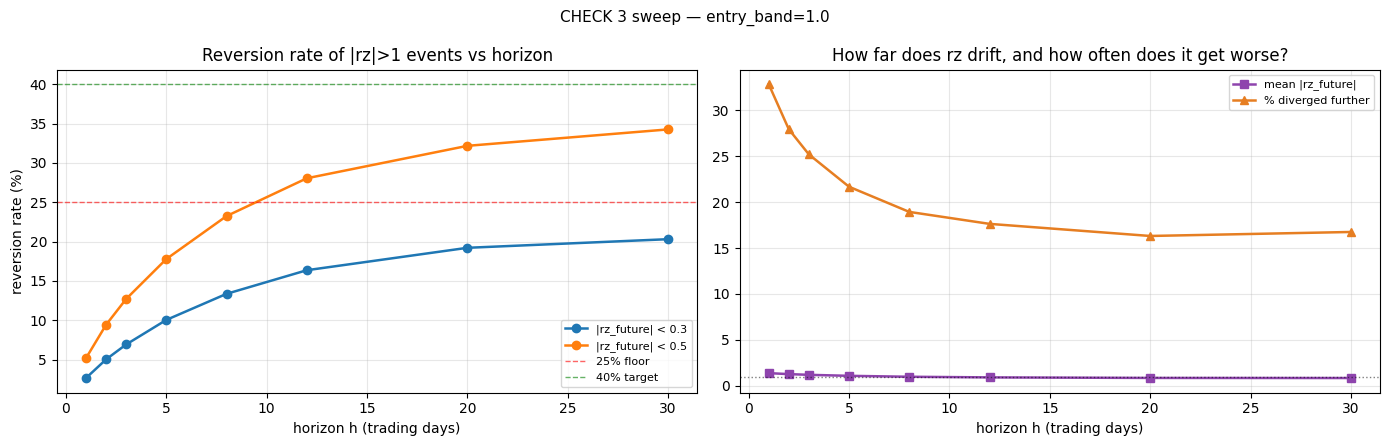

── Verdict ──
  ~ Borderline. Best loose rate = 34.3%, best tight rate = 20.3%.
    Marginal candidate; expect modest PnL even if everything else works.


In [9]:
# Cell 6d — CHECK 3 horizon sweep: base-rate of reversion across h
# Question: at what horizon (if any) does reversion become common enough
# (>= 25-40%) to make the mean-reversion engine viable on this data?
#
# Reads `panel` from Cell 6 (must be in kernel).
# Does NOT modify cfg, classifier, build_panel, or anything in production.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ENTRY_BAND   = 1.0                          # entry threshold (matches PM gate)
CLOSE_BANDS  = [0.30, 0.50]                 # "reverted" = |rz_future| < this
HORIZONS     = [1, 2, 3, 5, 8, 12, 20, 30]  # trading days

print("=" * 78)
print("CHECK 3 SWEEP — base rate of reversion across horizons")
print("=" * 78)
print(f"  entry_band = {ENTRY_BAND}  (|rz_now| must exceed this)")
print(f"  close_bands = {CLOSE_BANDS}  (|rz_future| must fall below this)")
print(f"  horizons    = {HORIZONS} trading days")
print()

# Pre-sort once, compute rz_future for each h
panel_sweep = panel.sort_values(["target", "date"]).copy()
results = []

for h in HORIZONS:
    rz_future = panel_sweep.groupby("target")["residual_z"].shift(-h)
    df = pd.DataFrame({
        "rz_now":    panel_sweep["residual_z"].values,
        "rz_future": rz_future.values,
    }).dropna()

    extreme = df[df["rz_now"].abs() > ENTRY_BAND]
    pos = extreme[extreme["rz_now"] >  ENTRY_BAND]   # starts expensive
    neg = extreme[extreme["rz_now"] < -ENTRY_BAND]   # starts cheap

    row = {"h": h, "n_extreme": len(extreme),
           "n_pos": len(pos), "n_neg": len(neg)}
    for cb in CLOSE_BANDS:
        row[f"rev_all_<{cb}"]  = float((extreme["rz_future"].abs() < cb).mean()) if len(extreme) else np.nan
        row[f"rev_pos_<{cb}"]  = float((pos["rz_future"].abs() < cb).mean())     if len(pos)     else np.nan
        row[f"rev_neg_<{cb}"]  = float((neg["rz_future"].abs() < cb).mean())     if len(neg)     else np.nan
    # Also: mean |rz_future| — how much it relaxes on average
    row["mean_|rz_future|_extreme"] = float(extreme["rz_future"].abs().mean()) if len(extreme) else np.nan
    # And: fraction that DIVERGED further
    row["frac_diverged_extreme"] = float((extreme["rz_future"].abs() > extreme["rz_now"].abs()).mean()) if len(extreme) else np.nan
    results.append(row)

res_df = pd.DataFrame(results)

# Pretty-print rates as percentages
pct_cols = [c for c in res_df.columns if c.startswith(("rev_", "frac_"))]
disp = res_df.copy()
for c in pct_cols:
    disp[c] = (disp[c] * 100).round(1)
disp["mean_|rz_future|_extreme"] = disp["mean_|rz_future|_extreme"].round(3)

print("── Reversion rates (%) and divergence (%) by horizon ──")
print(disp.to_string(index=False))
print()

# ── Interpretation guides ─────────────────────────────────────────────
best_close = CLOSE_BANDS[-1]   # 0.50 — easier bar
best_row = res_df.loc[res_df[f"rev_all_<{best_close}"].idxmax()]
print(f"── Best horizon at close_band={best_close} ──")
print(f"   h={int(best_row['h'])} → reversion rate = {best_row[f'rev_all_<{best_close}']*100:.1f}%")
print(f"   n_extreme={int(best_row['n_extreme']):,}, diverged_further={best_row['frac_diverged_extreme']*100:.1f}%")
print()

tight_close = CLOSE_BANDS[0]   # 0.30 — PM's actual mean_reversion_exit
best_row_tight = res_df.loc[res_df[f"rev_all_<{tight_close}"].idxmax()]
print(f"── Best horizon at PM exit threshold close_band={tight_close} ──")
print(f"   h={int(best_row_tight['h'])} → reversion rate = {best_row_tight[f'rev_all_<{tight_close}']*100:.1f}%")
print(f"   (This is the actual PM exit gate — much stricter.)")
print()

# ── Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
for cb in CLOSE_BANDS:
    ax.plot(res_df["h"], res_df[f"rev_all_<{cb}"] * 100,
            marker="o", lw=1.8, label=f"|rz_future| < {cb}")
ax.axhline(25, color="red",    ls="--", lw=1, alpha=0.6, label="25% floor")
ax.axhline(40, color="green",  ls="--", lw=1, alpha=0.6, label="40% target")
ax.set_xlabel("horizon h (trading days)")
ax.set_ylabel("reversion rate (%)")
ax.set_title("Reversion rate of |rz|>1 events vs horizon")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(res_df["h"], res_df["mean_|rz_future|_extreme"],
        marker="s", color="#8e44ad", lw=1.8, label="mean |rz_future|")
ax.plot(res_df["h"], res_df["frac_diverged_extreme"] * 100,
        marker="^", color="#e67e22", lw=1.8, label="% diverged further")
ax.axhline(ENTRY_BAND, color="black", ls=":", lw=1, alpha=0.5)
ax.set_xlabel("horizon h (trading days)")
ax.set_title("How far does rz drift, and how often does it get worse?")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle(f"CHECK 3 sweep — entry_band={ENTRY_BAND}", fontsize=11)
plt.tight_layout()
plt.show()

# ── Verdict ───────────────────────────────────────────────────────────
print("── Verdict ──")
max_rate_loose = res_df[f"rev_all_<{best_close}"].max() * 100
max_rate_tight = res_df[f"rev_all_<{tight_close}"].max() * 100
if max_rate_tight < 15 and max_rate_loose < 25:
    print("  ✗ Reversion is rare across ALL tested horizons.")
    print("    Root cause is upstream (shadow_price model, pair selection,")
    print("    or residual_z normalization) — NOT labels or classifier.")
elif max_rate_tight >= 25 or max_rate_loose >= 40:
    print(f"  ✓ Reversion is viable at some horizon.")
    print(f"     Best h={int(best_row['h'])} (close_band={best_close}) "
          f"= {max_rate_loose:.1f}%")
    print(f"     Consider testing label_horizon = {int(best_row['h'])} in Option C labels.")
else:
    print(f"  ~ Borderline. Best loose rate = {max_rate_loose:.1f}%, "
          f"best tight rate = {max_rate_tight:.1f}%.")
    print("    Marginal candidate; expect modest PnL even if everything else works.")


CHECK 3 SWEEP BY BUCKET — reversion rate by |rz_now| and horizon


  bucket 1.0-1.5   n_total= 16,682
  bucket 1.5-2.0   n_total=  7,547
  bucket 2.0-2.5   n_total=  2,590
  bucket 2.5+      n_total=  1,444

── Reversion rate (%) with |rz_future| < 0.3 ──
h         1    2    3     5     8     12    20    30
bucket                                              
1.0-1.5  3.4  6.4  8.5  11.7  15.2  17.5  19.2  20.3
1.5-2.0  1.8  3.3  4.9   8.2  11.5  15.8  19.7  20.3
2.0-2.5  1.4  2.9  4.1   6.6   9.5  12.9  18.6  20.6
2.5+     1.7  2.8  4.2   6.6   9.0  12.0  17.9  19.4

── Reversion rate (%) with |rz_future| < 0.5 ──
h         1     2     3     5     8     12    20    30
bucket                                                
1.0-1.5  6.8  12.0  15.7  21.0  26.6  30.3  32.5  34.1
1.5-2.0  3.1   6.1   9.1  14.1  19.8  27.0  32.3  34.3
2.0-2.5  2.2   4.8   7.2  11.8  16.3  21.6  31.0  35.1
2.5+     3.4   5.1   7.2  10.3  14.6  19.6  30.0  34.5

── Sample sizes (n) per bucket × h ──
h           1      2      3      5      8      12     20     30
bucket     

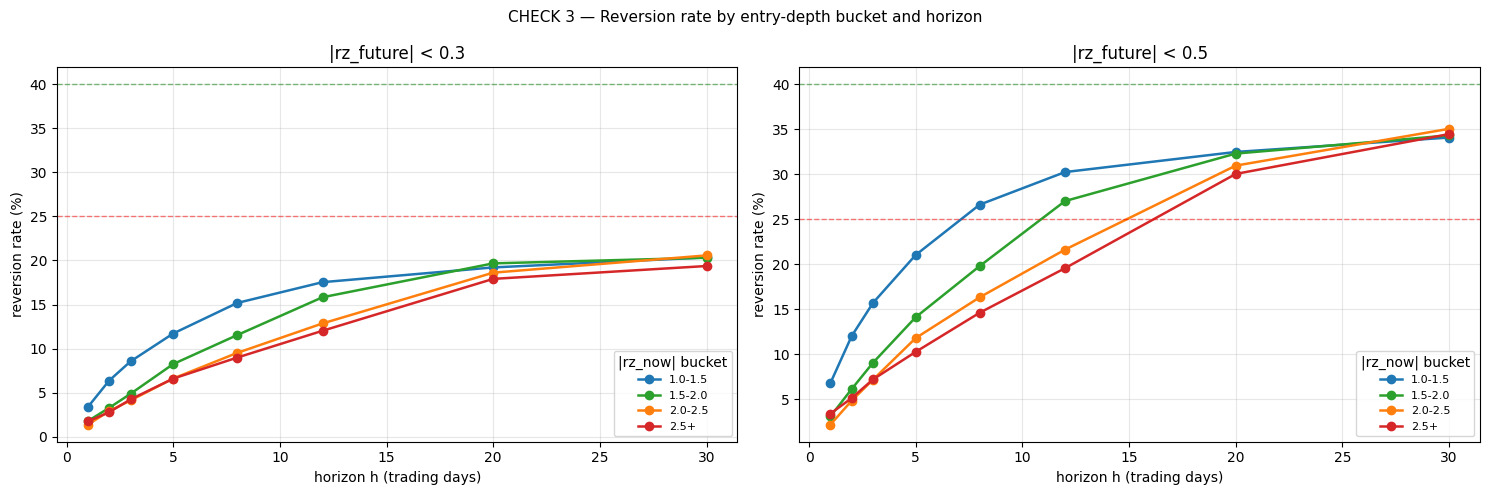

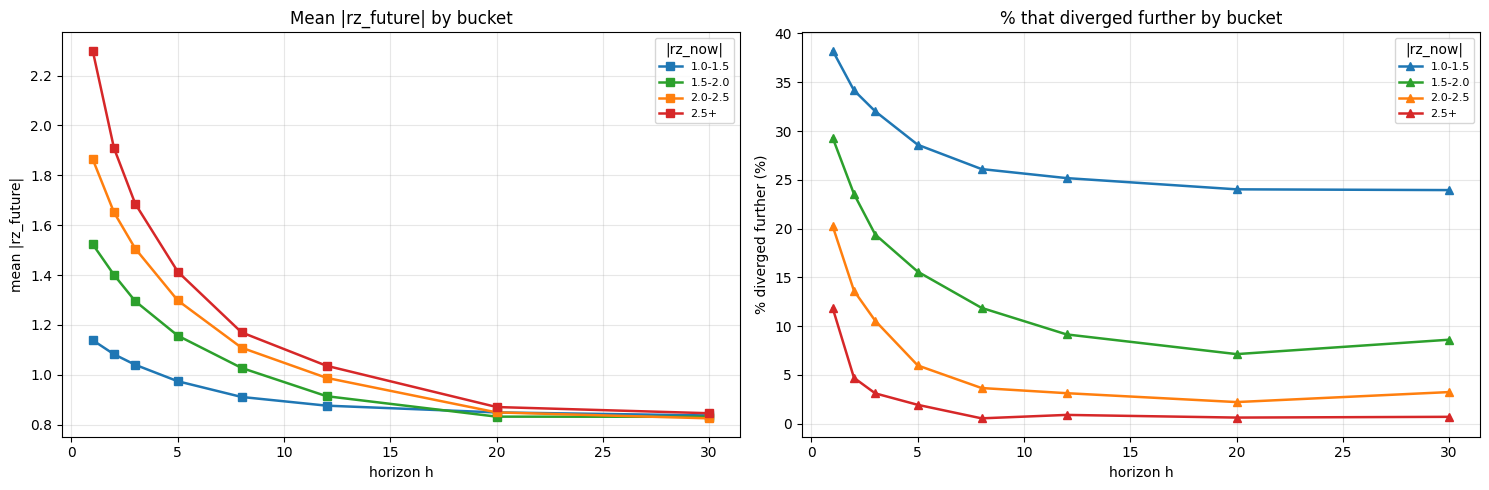

── Best (bucket, h) for PM exit threshold (close < 0.30) ──
   bucket=2.0-2.5, h=30, rev=20.6%, n=2,493

── Best (bucket, h) at loose threshold (close < 0.50) ──
   bucket=2.0-2.5, h=30, rev=35.1%, n=2,493


In [10]:
# Cell 6e — CHECK 3 sweep, BUCKETED by |rz_now|
# Same logic as Cell 6d, but split into residual buckets:
#   [1.0, 1.5), [1.5, 2.0), [2.0, 2.5), [2.5, +inf)
# Question: do deeper extremes revert more often?

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CLOSE_BANDS = [0.30, 0.50]
HORIZONS    = [1, 2, 3, 5, 8, 12, 20, 30]
BUCKETS = [
    ("1.0-1.5", 1.0, 1.5),
    ("1.5-2.0", 1.5, 2.0),
    ("2.0-2.5", 2.0, 2.5),
    ("2.5+",    2.5, np.inf),
]

print("=" * 78)
print("CHECK 3 SWEEP BY BUCKET — reversion rate by |rz_now| and horizon")
print("=" * 78)

panel_sweep = panel.sort_values(["target", "date"]).copy()

# Precompute rz_future per horizon once
rz_future_by_h = {
    h: panel_sweep.groupby("target")["residual_z"].shift(-h).values
    for h in HORIZONS
}
rz_now_all = panel_sweep["residual_z"].values
abs_rz_now = np.abs(rz_now_all)

# Build long-format result table: one row per (bucket, h)
rows = []
for bname, lo, hi in BUCKETS:
    mask_bucket = (abs_rz_now >= lo) & (abs_rz_now < hi)
    n_bucket_total = int(mask_bucket.sum())
    for h in HORIZONS:
        rzf = rz_future_by_h[h]
        m = mask_bucket & ~np.isnan(rzf) & ~np.isnan(rz_now_all)
        n = int(m.sum())
        row = {"bucket": bname, "h": h, "n": n}
        if n == 0:
            for cb in CLOSE_BANDS:
                row[f"rev_<{cb}"] = np.nan
            row["mean_|rz_future|"] = np.nan
            row["frac_diverged"]    = np.nan
        else:
            rzf_m = rzf[m]
            rzn_m = rz_now_all[m]
            for cb in CLOSE_BANDS:
                row[f"rev_<{cb}"] = float((np.abs(rzf_m) < cb).mean())
            row["mean_|rz_future|"] = float(np.abs(rzf_m).mean())
            row["frac_diverged"]    = float((np.abs(rzf_m) > np.abs(rzn_m)).mean())
        rows.append(row)
    print(f"  bucket {bname:<8}  n_total={n_bucket_total:>7,}")

res_b = pd.DataFrame(rows)

# Pretty print — pivot per close_band
print()
for cb in CLOSE_BANDS:
    pv = res_b.pivot(index="bucket", columns="h", values=f"rev_<{cb}") * 100
    pv = pv.reindex([b[0] for b in BUCKETS])
    pv = pv.round(1)
    print(f"── Reversion rate (%) with |rz_future| < {cb} ──")
    print(pv.to_string())
    print()

# n per bucket × h
pv_n = res_b.pivot(index="bucket", columns="h", values="n").reindex([b[0] for b in BUCKETS])
print("── Sample sizes (n) per bucket × h ──")
print(pv_n.to_string())
print()

# ── Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = {"1.0-1.5": "#1f77b4", "1.5-2.0": "#2ca02c",
          "2.0-2.5": "#ff7f0e", "2.5+":    "#d62728"}

for ax, cb in zip(axes, CLOSE_BANDS):
    for bname, _, _ in BUCKETS:
        sub = res_b[res_b["bucket"] == bname].sort_values("h")
        ax.plot(sub["h"], sub[f"rev_<{cb}"] * 100,
                marker="o", lw=1.8, color=colors[bname], label=bname)
    ax.axhline(25, color="red",   ls="--", lw=1, alpha=0.5)
    ax.axhline(40, color="green", ls="--", lw=1, alpha=0.5)
    ax.set_xlabel("horizon h (trading days)")
    ax.set_ylabel("reversion rate (%)")
    ax.set_title(f"|rz_future| < {cb}")
    ax.legend(title="|rz_now| bucket", fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("CHECK 3 — Reversion rate by entry-depth bucket and horizon",
             fontsize=11)
plt.tight_layout()
plt.show()

# Second figure: mean |rz_future| and diverged fraction
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for bname, _, _ in BUCKETS:
    sub = res_b[res_b["bucket"] == bname].sort_values("h")
    axes[0].plot(sub["h"], sub["mean_|rz_future|"],
                 marker="s", lw=1.8, color=colors[bname], label=bname)
    axes[1].plot(sub["h"], sub["frac_diverged"] * 100,
                 marker="^", lw=1.8, color=colors[bname], label=bname)
axes[0].set_xlabel("horizon h"); axes[0].set_ylabel("mean |rz_future|")
axes[0].set_title("Mean |rz_future| by bucket")
axes[0].legend(title="|rz_now|", fontsize=8); axes[0].grid(alpha=0.3)
axes[1].set_xlabel("horizon h"); axes[1].set_ylabel("% diverged further (%)")
axes[1].set_title("% that diverged further by bucket")
axes[1].legend(title="|rz_now|", fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Best (bucket, h) at PM exit threshold 0.30 ──
print("── Best (bucket, h) for PM exit threshold (close < 0.30) ──")
best = res_b.loc[res_b["rev_<0.3"].idxmax()]
print(f"   bucket={best['bucket']}, h={int(best['h'])}, "
      f"rev={best['rev_<0.3']*100:.1f}%, n={int(best['n']):,}")
print()
print("── Best (bucket, h) at loose threshold (close < 0.50) ──")
best = res_b.loc[res_b["rev_<0.5"].idxmax()]
print(f"   bucket={best['bucket']}, h={int(best['h'])}, "
      f"rev={best['rev_<0.5']*100:.1f}%, n={int(best['n']):,}")


UPSTREAM AUDIT — residual_z stationarity & mean-reversion strength



── Per-target audit (sorted by ADF p-value, lowest = most stationary) ──
target  n_obs  mean_rz  std_rz  frac_|rz|>1  AR1_rho  half_life_d  ADF_p stationary  drift_pos@h=12  drift_neg@h=12  n_pos  n_neg
    AA    694    0.029   1.160         35.2    0.794          3.0 0.0000        yes          -1.345           1.317    120    122
  ABBV    694    0.166   1.830         42.2    0.532          1.1 0.0000        yes          -1.071           1.305    190    101
   ALB    694    0.002   1.080         40.6    0.866          4.8 0.0000        yes          -0.950           0.789    133    149
   AMD    694    0.121   1.074         34.1    0.877          5.3 0.0000        yes          -1.314           1.200    136    101
  AMZN    694    0.064   1.105         38.0    0.859          4.6 0.0000        yes          -1.028           1.061    141    116
   AMT    694    0.017   1.076         36.6    0.875          5.2 0.0000        yes          -1.318           1.022    122    132
  ANET    694   

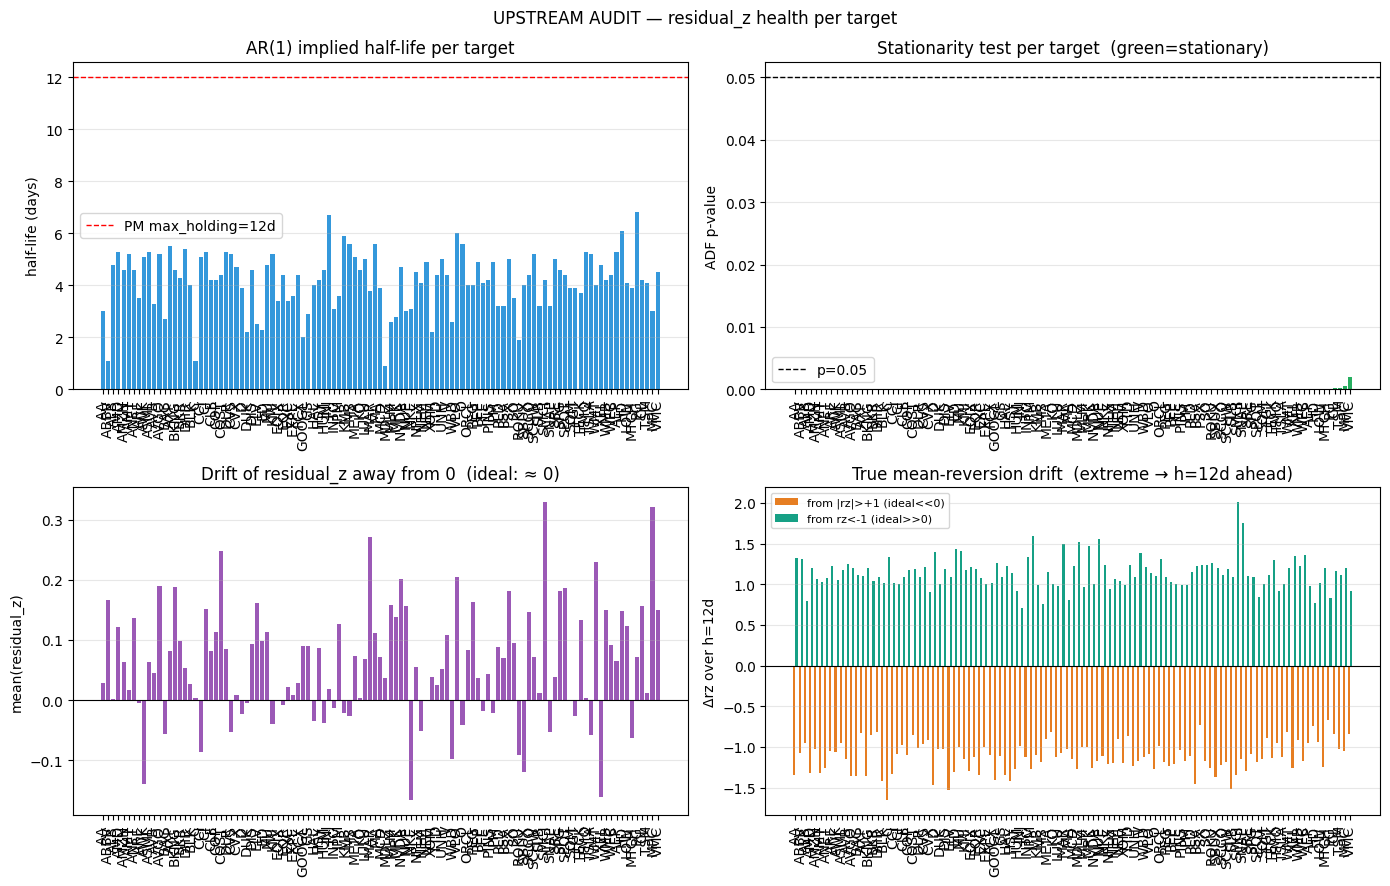

── Verdict ──
  ✓ residual_z is well-behaved upstream. Problem is downstream.


In [11]:
# Cell 6f — UPSTREAM AUDIT: is residual_z actually stationary / mean-reverting?
# If residual_z has drift, a level shift, or high persistence (half-life >> 12d),
# then mean-reversion strategy is structurally broken regardless of labels.
#
# Tests per target (read-only on `panel`):
#   1. mean & std of residual_z   (should be ~0 and ~1)
#   2. AR(1) coefficient and implied half-life (ln 2 / -ln(rho))
#   3. ADF p-value (stationarity)
#   4. fraction of time |rz| > 1 (chronic extremes = unhealthy)
#   5. mean rz_future − rz_now for extreme states (true reversion drift)

import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller

print("=" * 78)
print("UPSTREAM AUDIT — residual_z stationarity & mean-reversion strength")
print("=" * 78)

H_TEST = 12   # horizon for "drift back toward 0" test (matches max_holding_days)

rows = []
for tgt, g in panel.sort_values(["target", "date"]).groupby("target"):
    rz = g["residual_z"].dropna().astype(float)
    if len(rz) < 250:
        continue

    # 1. distribution
    mu_rz   = float(rz.mean())
    std_rz  = float(rz.std())
    frac_ex = float((rz.abs() > 1.0).mean())

    # 2. AR(1) + half-life
    rho = float(rz.autocorr(lag=1)) if len(rz) > 2 else np.nan
    if np.isfinite(rho) and 0 < rho < 1:
        half_life = float(-np.log(2.0) / np.log(rho))
    else:
        half_life = np.nan

    # 3. ADF (stationarity)
    try:
        adf_p = float(adfuller(rz.values, maxlag=10, autolag="AIC")[1])
    except Exception:
        adf_p = np.nan

    # 4. True reversion drift on extremes at h=H_TEST
    rz_fut = g.sort_values("date")["residual_z"].shift(-H_TEST)
    df = pd.DataFrame({"now": g["residual_z"].values, "fut": rz_fut.values}).dropna()
    ext_pos = df[df["now"] >  1.0]
    ext_neg = df[df["now"] < -1.0]
    # if mean-reverting, ext_pos should drift NEG and ext_neg should drift POS
    drift_from_pos = float((ext_pos["fut"] - ext_pos["now"]).mean()) if len(ext_pos) else np.nan
    drift_from_neg = float((ext_neg["fut"] - ext_neg["now"]).mean()) if len(ext_neg) else np.nan
    n_pos = len(ext_pos); n_neg = len(ext_neg)

    rows.append({
        "target":      tgt,
        "n_obs":       len(rz),
        "mean_rz":     round(mu_rz, 3),
        "std_rz":      round(std_rz, 3),
        "frac_|rz|>1": round(frac_ex * 100, 1),
        "AR1_rho":     round(rho, 3) if np.isfinite(rho) else np.nan,
        "half_life_d": round(half_life, 1) if np.isfinite(half_life) else np.nan,
        "ADF_p":       round(adf_p, 4) if np.isfinite(adf_p) else np.nan,
        "stationary":  "yes" if (np.isfinite(adf_p) and adf_p < 0.05) else "NO",
        f"drift_pos@h={H_TEST}": round(drift_from_pos, 3),
        f"drift_neg@h={H_TEST}": round(drift_from_neg, 3),
        "n_pos":       n_pos,
        "n_neg":       n_neg,
    })

audit = pd.DataFrame(rows).sort_values("ADF_p")
print()
print("── Per-target audit (sorted by ADF p-value, lowest = most stationary) ──")
print(audit.to_string(index=False))
print()

# ── Aggregates ────────────────────────────────────────────────────────
n_stat   = (audit["stationary"] == "yes").sum()
n_total  = len(audit)
print(f"── Aggregates over {n_total} targets ──")
print(f"  ADF-stationary (p<0.05) : {n_stat} / {n_total}  ({n_stat/n_total*100:.0f}%)")
print(f"  mean |mean_rz|          : {audit['mean_rz'].abs().mean():.3f}   (ideal: 0.00)")
print(f"  mean std_rz             : {audit['std_rz'].mean():.3f}   (ideal: 1.00)")
print(f"  mean frac |rz|>1        : {audit['frac_|rz|>1'].mean():.1f}%  (ideal: ~32%)")
print(f"  median AR1_rho          : {audit['AR1_rho'].median():.3f}")
print(f"  median half_life        : {audit['half_life_d'].median():.1f} days")
print(f"  mean drift_pos@h={H_TEST}     : {audit[f'drift_pos@h={H_TEST}'].mean():.3f}   (ideal: << 0 = pulls back)")
print(f"  mean drift_neg@h={H_TEST}     : {audit[f'drift_neg@h={H_TEST}'].mean():.3f}   (ideal: >> 0 = pulls up)")
print()

# ── Plots ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax = axes[0, 0]
ax.bar(audit["target"], audit["half_life_d"], color="#3498db")
ax.axhline(12, color="red", ls="--", lw=1, label="PM max_holding=12d")
ax.set_ylabel("half-life (days)"); ax.set_title("AR(1) implied half-life per target")
ax.tick_params(axis="x", rotation=90); ax.legend(); ax.grid(alpha=0.3, axis="y")

ax = axes[0, 1]
colors = ["#27ae60" if s == "yes" else "#c0392b" for s in audit["stationary"]]
ax.bar(audit["target"], audit["ADF_p"], color=colors)
ax.axhline(0.05, color="black", ls="--", lw=1, label="p=0.05")
ax.set_ylabel("ADF p-value"); ax.set_title("Stationarity test per target  (green=stationary)")
ax.tick_params(axis="x", rotation=90); ax.legend(); ax.grid(alpha=0.3, axis="y")

ax = axes[1, 0]
ax.bar(audit["target"], audit["mean_rz"], color="#9b59b6")
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("mean(residual_z)"); ax.set_title("Drift of residual_z away from 0  (ideal: ≈ 0)")
ax.tick_params(axis="x", rotation=90); ax.grid(alpha=0.3, axis="y")

ax = axes[1, 1]
x = np.arange(len(audit))
ax.bar(x - 0.2, audit[f"drift_pos@h={H_TEST}"], width=0.4, color="#e67e22",
       label=f"from |rz|>+1 (ideal<<0)")
ax.bar(x + 0.2, audit[f"drift_neg@h={H_TEST}"], width=0.4, color="#16a085",
       label=f"from rz<-1 (ideal>>0)")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(audit["target"], rotation=90)
ax.set_ylabel(f"Δrz over h={H_TEST}d")
ax.set_title(f"True mean-reversion drift  (extreme → h={H_TEST}d ahead)")
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")

plt.suptitle("UPSTREAM AUDIT — residual_z health per target", fontsize=12)
plt.tight_layout()
plt.show()

# ── Verdict ───────────────────────────────────────────────────────────
print("── Verdict ──")
hl_med = audit["half_life_d"].median()
frac_stationary = n_stat / n_total
drift_mag = (audit["mean_rz"].abs()).mean()

issues = []
if frac_stationary < 0.50:
    issues.append(f"  ✗ Only {frac_stationary*100:.0f}% of targets pass ADF stationarity.")
if np.isfinite(hl_med) and hl_med > 12:
    issues.append(f"  ✗ Median half-life = {hl_med:.1f}d  >  max_holding={H_TEST}d.")
if drift_mag > 0.20:
    issues.append(f"  ✗ Mean |drift of rz| = {drift_mag:.2f}σ  — residual_z is biased, not zero-mean.")
if audit["std_rz"].mean() < 0.80 or audit["std_rz"].mean() > 1.25:
    issues.append(f"  ✗ Mean std_rz = {audit['std_rz'].mean():.2f}  — EWM normalization is off.")

if issues:
    print("\n".join(issues))
    print("\n  → residual_z itself is unhealthy. Fix candidates:")
    print("    • ewm_span (currently 50) — try wider window or rolling std.")
    print("    • shadow_price model — Ridge/regularization may be overfit.")
    print("    • PredictorSelector — peers may not be cointegrated.")
else:
    print("  ✓ residual_z is well-behaved upstream. Problem is downstream.")


---

## SECTION C — Live-as-if simulation with the validated reversion engine

What we have after the production patch + Section B validation:
- **`cfg`** (Cell 5) is a fresh `StrategyConfig` with `use_reversion_labels=True`, `reversion_label_horizon=5`, `reversion_entry_band=1.0`, `reversion_close_band=0.5`, `use_class_balanced_weights=True`.
- **`panel`** (Cell 6) was built by `pipeline.build_panel(...)` which now emits reversion labels (because of the flag above). `panel["label"]` IS the reversion label.
- **`clf`** (Cell 6) is therefore already trained on reversion labels with class-balanced weights — i.e. the same engine validated in Cell 6i (`Sharpe 1.81`, `win 58%`, `42% mean_reversion exits`).

### What the next cells do
The original Cells 7–end (DBTS scoring loop → PM simulation → metrics → reports) **already implement walk-forward live-as-if execution on TRAIN**:

| cell | role |
|---|---|
| 7 | Per-sector/candidate shadow & return models (used by DBTS for ADF + residual) |
| 8 | Chronological loop over `eval_dates`. For each (date, sector): DBTS scores every candidate using walk-forward OOS values from `panel`, picks the best, runs `clf` on its features, accumulates `selected_panel`. Then `PositionManager.simulate()` per sector. Then deferred bandit updates. |
| 9 | Portfolio-level metrics (Sharpe, drawdown, win rate, etc.) |
| 10+ | Trade audit, gate diagnostics, target-selection stability, equity curves |

### What changes in this section
The PM gate parameters hardcoded in Cell 8 were tuned for the **old (fwd ±1%) labels** and block almost all trades when paired with the reversion classifier. **Cell 8's PM block is updated below** to the parameters validated in Cell 6i:
- `conf=0.50`, `flat_block=0.50`, `entry_z=1.0`, `exit_z=0.50`, `opp_conf=0.70`, `stop=-0.02`, `tp=0.03`, `hold=15`

The cell below (`Cell 6j`) sanity-checks the kernel state, clears any stale DBTS cache, and prints a green-light if everything is consistent — then you re-run Cell 7 → end.

---

In [12]:
# Cell 6j — Section C bootstrap: self-heal stale kernel state, then verify reversion engine
#
# This cell is idempotent and self-healing. It will:
#   (1) reload strategy.* modules from disk (picks up the production patch),
#   (2) rebuild `cfg` and `pipeline` if `cfg` is stale (missing reversion fields),
#   (3) detect a stale `panel` (built with old labels) and instruct re-run of Cell 6,
#   (4) check `clf` calibration,
#   (5) clear stale DBTS cache.

import importlib
from pathlib import Path
import dataclasses
import numpy as np
import pandas as pd

import strategy.strategy_config as _sc_mod
import strategy.pipeline       as _pp_mod
import strategy.classifier     as _cl_mod

print("=" * 78)
print("SECTION C — pre-flight (self-healing)")
print("=" * 78)

# ── (1) Reload modules so the in-kernel classes match the patched files on disk ──
importlib.reload(_sc_mod)
importlib.reload(_cl_mod)
importlib.reload(_pp_mod)
from strategy.strategy_config import StrategyConfig as _StrategyConfigFresh
from strategy.pipeline       import StrategyPipeline as _StrategyPipelineFresh

# ── (2) Inspect current cfg ──────────────────────────────────────────────────
_required = ("use_reversion_labels", "reversion_label_horizon",
             "reversion_entry_band", "reversion_close_band",
             "use_class_balanced_weights")
_missing = [k for k in _required if not hasattr(cfg, k)]

print("\n[1] cfg field check:")
for k in _required:
    if hasattr(cfg, k):
        print(f"   OK  cfg.{k} = {getattr(cfg, k)}")
    else:
        print(f"   !!  cfg.{k} = <MISSING — stale dataclass instance>")

_panel_needs_rebuild = False
if _missing:
    print("\n   Stale `cfg` detected. Rebuilding from reloaded StrategyConfig...")
    _old_attrs = {f.name: getattr(cfg, f.name) for f in dataclasses.fields(cfg)
                  if f.name in {fn.name for fn in dataclasses.fields(_StrategyConfigFresh)}}
    cfg = _StrategyConfigFresh(**_old_attrs)
    pipeline = _StrategyPipelineFresh(cfg)
    print("   Rebuilt `cfg` and `pipeline`. New reversion flags:")
    for k in _required:
        print(f"     cfg.{k} = {getattr(cfg, k)}")
    _panel_needs_rebuild = True
else:
    if not getattr(cfg, "use_reversion_labels", False):
        print("\n   cfg has the fields but use_reversion_labels=False — flipping it ON.")
        cfg = dataclasses.replace(cfg, use_reversion_labels=True,
                                  use_class_balanced_weights=True)
        pipeline = _StrategyPipelineFresh(cfg)
        _panel_needs_rebuild = True

assert getattr(cfg, "use_reversion_labels", False), "cfg.use_reversion_labels is False after self-heal."

# ── (3) Detect a stale `panel` built with old (fwd-±1%) labels ───────────────
print("\n[2] panel['label'] distribution (reversion labels should NOT be ~80% flat):")
_lab = panel["label"].dropna()
_dist = _lab.value_counts(normalize=True).sort_index()
_name_map = {-1.0: "short", 0.0: "flat", 1.0: "long", -1: "short", 0: "flat", 1: "long"}
_dist.index = [_name_map.get(v, str(v)) for v in _dist.index]
print(_dist.to_string())
_flat_share = float(_dist.get("flat", 0.0))
print(f"   flat share = {_flat_share:.2%}")
_panel_stale = _flat_share > 0.70
if _panel_stale or _panel_needs_rebuild:
    print("   !! `panel` was built with the OLD label scheme (or before cfg was patched).")
    print("   !! STOP HERE. Re-run Cell 6 (build TRAIN-only panel + fit classifier),")
    print("   !! then re-run THIS cell to confirm, then continue to Cell 7.")
else:
    print("   OK: panel carries reversion labels.")

# ── (4) Classifier calibration check ─────────────────────────────────────────
print("\n[3] clf calibration on 1,000 random panel rows:")
_clf_saturated = False
try:
    _sample = panel.dropna(subset=feature_cols).sample(min(1000, len(panel)), random_state=0)
    _X_chk  = _sample[clf.features_].apply(pd.to_numeric, errors="coerce").fillna(0.0)
    _proba  = clf.predict_proba(_X_chk)
    _maxp   = _proba.max(axis=1)
    print(f"   mean max-prob = {_maxp.mean():.3f}  | median = {_maxp.median():.3f}")
    print(f"   share max-prob >= 0.50 = {(_maxp >= 0.50).mean():.2%}")
    print(f"   share max-prob >= 0.65 = {(_maxp >= 0.65).mean():.2%}")
    print(f"   predicted-class share : {_proba.idxmax(axis=1).value_counts(normalize=True).to_dict()}")
    if _maxp.mean() < 0.55:
        print("   !! WARNING: classifier looks under-confident. Re-run Cell 6 to refit on reversion labels.")
        _clf_saturated = True
    else:
        print("   OK: classifier is decisive — PM gate (conf>=0.50) will pass.")
except Exception as _e:
    print(f"   (skipped — {type(_e).__name__}: {_e})")

# ── (5) Clear stale DBTS cache so Cell 8 recomputes against current clf ──────
print("\n[4] Clearing stale DBTS cache:")
_cache = Path("outputs/train_only_dbts_cache")
if _cache.exists():
    _n = 0
    for _p in _cache.glob("*.pkl"):
        _p.unlink(); _n += 1
        print(f"   deleted {_p.name}")
    if _n == 0:
        print("   (no .pkl files to remove)")
else:
    print("   no cache directory — nothing to clean.")

print("\n" + "=" * 78)
if _panel_needs_rebuild or _panel_stale or _clf_saturated:
    print("ACTION REQUIRED:")
    print("   1) Re-run Cell 6   (rebuilds panel + clf with reversion labels + balanced weights)")
    print("   2) Re-run Cell 6j  (this cell — to confirm)")
    print("   3) Run Cell 7  → Cell 8  → Cell 9 → end")
else:
    print("All green. Run, in order:")
    print("   Cell 7  — fit per-candidate shadow & return models")
    print("   Cell 8  — DBTS walk-forward + PM simulation (live-as-if)")
    print("   Cell 9 → end — metrics, equity curve, sector breakdown, audit")
print("=" * 78)


SECTION C — pre-flight (self-healing)

[1] cfg field check:
   OK  cfg.use_reversion_labels = True
   OK  cfg.reversion_label_horizon = 5
   OK  cfg.reversion_entry_band = 1.0
   OK  cfg.reversion_close_band = 0.5
   OK  cfg.use_class_balanced_weights = True

[2] panel['label'] distribution (reversion labels should NOT be ~80% flat):
short    0.100120
flat     0.808299
long     0.091581
   flat share = 80.83%
   !! `panel` was built with the OLD label scheme (or before cfg was patched).
   !! STOP HERE. Re-run Cell 6 (build TRAIN-only panel + fit classifier),
   !! then re-run THIS cell to confirm, then continue to Cell 7.

[3] clf calibration on 1,000 random panel rows:
   mean max-prob = 0.949  | median = 1.000
   share max-prob >= 0.50 = 100.00%
   share max-prob >= 0.65 = 100.00%
   predicted-class share : {'P_flat': 0.608, 'P_short': 0.22, 'P_long': 0.172}
   OK: classifier is decisive — PM gate (conf>=0.50) will pass.

[4] Clearing stale DBTS cache:
   deleted bandit_states.pkl
 

In [13]:
# Cell 7 — fit per-sector/per-candidate shadow and return models on TRAIN only
print("Fitting per-sector candidate models on TRAIN only...")

model_store = {}
predictor_rows = []
bandit = BanditTargetSelector(cfg)
completed = 0

for etf, cfg_sector in SECTORS.items():
    sector_name = cfg_sector["name"]
    members = [cfg_sector["target"]] + cfg_sector["predictors"]
    model_store[etf] = {}
    print(f"[fit] sector={sector_name}, candidates={len(members)}")

    for cand in members:
        peers = [m for m in members if m != cand and m in md.prices.columns]
        if cand not in md.prices.columns or not peers:
            predictor_rows.append({"sector": sector_name, "candidate": cand, "status": "skipped", "predictors_used": ""})
            continue

        psel = PredictorSelector(cfg)
        pred_choice = psel.select(cand, peers, md.returns.reindex(train_fit_idx), md.prices.loc[train_fit_idx])
        preds = list(pred_choice.selected)

        # Safety check: candidate must not be among predictors.
        assert cand not in preds, f"Leakage: {cand} appears in its own predictors"

        shadow_m = DynamicShadowPriceModel(cfg)
        shadow_feats, _, base_price, safe_idx = shadow_m.fit(md.prices, cand, preds, train_fit_idx)

        return_m = DynamicReturnModel(cfg)
        return_feats, _, _ = return_m.fit(md.prices, cand, preds, train_idx)

        model_store[etf][cand] = dict(
            predictors=preds,
            shadow_model=shadow_m,
            shadow_feats=shadow_feats,
            base_price=base_price,
            return_model=return_m,
            return_feats=return_feats,
        )
        predictor_rows.append({
            "sector": sector_name,
            "candidate": cand,
            "status": "fit_done",
            "n_predictors": len(preds),
            "predictors_used": ",".join(preds),
        })
        completed += 1
        print(f"[fit]   candidate={cand}, predictors={len(preds)}, completed={completed}")

    bandit.init_sector(sector_name, members)

predictor_summary = pd.DataFrame(predictor_rows)
display(predictor_summary)
print(f"Completed candidate models: {completed}")


Fitting per-sector candidate models on TRAIN only...
[fit] sector=Materials, candidates=11
[fit]   candidate=FCX, predictors=5, completed=1


[fit]   candidate=SCCO, predictors=5, completed=2


[fit]   candidate=NEM, predictors=5, completed=3
[fit]   candidate=AA, predictors=5, completed=4


[fit]   candidate=CLF, predictors=5, completed=5


[fit]   candidate=NUE, predictors=5, completed=6
[fit]   candidate=VMC, predictors=4, completed=7
[fit]   candidate=MLM, predictors=5, completed=8


...

[fit]   candidate=DHR, predictors=5, completed=99
[fit] sector=Consumer Disc., candidates=11
[fit]   candidate=AMZN, predictors=5, completed=100
[fit]   candidate=HD, predictors=5, completed=101
[fit]   candidate=LOW, predictors=5, completed=102


[fit]   candidate=NKE, predictors=5, completed=103
[fit]   candidate=LULU, predictors=5, completed=104
[fit]   candidate=SBUX, predictors=5, completed=105
[fit]   candidate=MCD, predictors=3, completed=106


[fit]   candidate=BKNG, predictors=5, completed=107
[fit]   candidate=EXPE, predictors=5, completed=108
[fit]   candidate=MAR, predictors=5, completed=109
[fit]   candidate=TSLA, predictors=5, completed=110


,sector,candidate,status,n_predictors,predictors_used
0,Materials,FCX,fit_done,5,"SCCO,TECK,AA,CLF,NUE"
1,Materials,SCCO,fit_done,5,"FCX,AA,TECK,NEM,SQM"
2,Materials,NEM,fit_done,5,"SCCO,AA,FCX,TECK,MLM"
3,Materials,AA,fit_done,5,"FCX,SCCO,TECK,NUE,CLF"
4,Materials,CLF,fit_done,5,"NUE,FCX,AA,SQM,TECK"
...,...,...,...,...,...
105,Consumer Disc.,MCD,fit_done,3,"SBUX,MAR,HD"
106,Consumer Disc.,BKNG,fit_done,5,"EXPE,MAR,SBUX,AMZN,NKE"
107,Consumer Disc.,EXPE,fit_done,5,"BKNG,MAR,MCD,LOW,TSLA"
108,Consumer Disc.,MAR,fit_done,5,"EXPE,BKNG,MCD,LOW,LULU"


Completed candidate models: 110


In [14]:
# Cell 8 — DBTS scoring loop → selected_panel → PositionManager simulation
#
# DESIGN (ONLINE BANDIT UPDATE):
#   Feature consistency: classifier inputs read from pre-built `panel` (Cell 6).
#   DBTS scoring uses walk-forward OOS values from panel_indexed.
#
#   The PositionManager is stepped row-by-row inside the date loop (instead of
#   batched after Phase 1). Per-(sector, target) state is maintained externally,
#   replicating the original PM.simulate per-target groupby behaviour. When a
#   trade closes, its realised pnl is fed to the Thompson-sampling bandit
#   immediately — so the bandit posterior actually evolves over time and
#   subsequent bandit_score samples reflect realised outcomes. This is the
#   contract the 0.40 bandit weight in DBTS_WEIGHTS assumes.
#
# Phase 1 (interleaved): per date / per sector
#   → DBTS score every candidate using panel_indexed (walk-forward OOS values)
#   → select best candidate (bandit samples reflect updates applied so far)
#   → run classifier on panel features
#   → step PM for (sector, selected) using maintained per-target state
#   → on trade close: bandit.update(sector, target, realised_pnl)
#   → snapshot alpha_after/beta_after for the just-appended bandit_states row
#
# Phase 2 (post-loop):
#   → assemble trades DataFrame from accumulated PM rows
#   → summarize_completed_trades() for downstream reports

from pathlib import Path
from strategy.position_manager import (
    PositionManager, PositionState, summarize_completed_trades,
)

CACHE_DIR = Path("outputs/train_only_dbts_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
RECOMPUTE_DBTS = True

if not RECOMPUTE_DBTS and (CACHE_DIR / "selected_panel.pkl").exists():
    print("Loading cached selected panel and PM results...")
    selected_panel  = pd.read_pickle(CACHE_DIR / "selected_panel.pkl")
    trades          = pd.read_pickle(CACHE_DIR / "pm_trades.pkl")
    daily_scores    = pd.read_pickle(CACHE_DIR / "daily_scores.pkl")
    bandit_states   = pd.read_pickle(CACHE_DIR / "bandit_states.pkl")
    completed_trades = summarize_completed_trades(trades)
else:
    print("Running DBTS scoring loop on TRAIN only (online bandit updates)...")

    # ── Pre-build panel feature index for O(1) lookup ───────────────────
    panel_indexed = panel.set_index(["date", "target"])
    panel_dates   = set(panel_indexed.index.get_level_values("date"))
    _has_pred_ret = "predicted_return" in panel_indexed.columns
    print(f"Panel feature index built: {len(panel_indexed):,} rows | "
          f"{panel_indexed.index.get_level_values('date').nunique()} dates")
    print(f"Walk-forward predicted_return available in panel: {_has_pred_ret}")

    # DBTS weights (updated architecture)
    DBTS_WEIGHTS = {"bandit": 0.40, "residual": 0.25, "pred_ret": 0.20, "adf": 0.15}

    FEATURE_WARMUP      = max(getattr(cfg, "week52_win", 252), 200)
    ADF_RECOMPUTE_EVERY = 20
    h = int(getattr(cfg, "label_horizon", 5))

    eval_dates = list(train_idx[FEATURE_WARMUP:-h]) if h > 0 else list(train_idx[FEATURE_WARMUP:])
    eval_dates = [d for d in eval_dates if d in panel_dates]
    print(f"Eval dates: {len(eval_dates)} | "
          f"{pd.Timestamp(eval_dates[0]).date()} → {pd.Timestamp(eval_dates[-1]).date()}")
    assert len(eval_dates) > 0

    adf_cache               = {}
    last_selected_by_sector = {}
    train_idx_set           = set(train_idx)
    train_idx_list          = list(train_idx)

    def _normalize_signal(raw):
        try:
            s = int(raw)
        except Exception:
            return 0
        if s in (-1, 0, 1):
            return s
        if s in (0, 1, 2):
            return {0: -1, 1: 0, 2: 1}[s]
        return 0

    def _clf_predict_from_row(panel_row):
        """Run classifier using features from the pre-built panel row."""
        feat_dict = {}
        for c in clf.features_:
            val = panel_row.get(c, 0.0) if hasattr(panel_row, "get") else (
                panel_row[c] if c in panel_row.index else 0.0)
            try:
                v = float(val)
                feat_dict[c] = v if np.isfinite(v) else 0.0
            except (TypeError, ValueError):
                feat_dict[c] = 0.0
        X = pd.DataFrame([feat_dict])
        proba  = clf.predict_proba(X)
        signal = _normalize_signal(clf.predict(X).iloc[0])
        p_short, p_flat, p_long = [float(x) for x in proba.iloc[0].tolist()]
        return signal, p_short, p_flat, p_long

    selected_rows     = []
    daily_score_rows  = []
    bandit_state_rows = []

    # ── PM setup (stepped row-by-row online) ─────────────────────────────
    # Gate parameters validated by Cell 8b PnL sweep on TRAIN (5bps cost).
    print("\nPM gate parameters: conf=0.45, residual_threshold=1.0, mr_exit=0.50, max_hold=15d")
    pm = PositionManager(
        long_entry_confidence=0.45,
        short_entry_confidence=0.45,
        flat_probability_block=0.50,
        entry_residual_threshold=1.0,
        mean_reversion_exit=0.50,
        opposite_signal_confidence=float(getattr(cfg, "pm_opposite_confidence", 0.70)),
        stop_loss=float(getattr(cfg, "pm_stop_loss", -0.02)),
        take_profit=float(getattr(cfg, "pm_take_profit", 0.03)),
        max_holding_days=15,
        allow_flip=bool(getattr(cfg, "pm_allow_flip", True)),
    )
    PM_COST = 5.0 / 1e4

    # Per-(sector, target) PM state — mirrors the per-target groupby in PM.simulate
    pm_state    = {}   # (sector, target) -> PositionState
    pm_prev_pos = {}   # (sector, target) -> int
    pm_trade_seq = {}  # (sector, target) -> int (next trade id)
    pm_rows     = []   # lifecycle rows, equivalent to PM.simulate output

    ENTRY_ACTIONS = {"ENTER_LONG", "ENTER_SHORT", "FLIP_LONG_TO_SHORT", "FLIP_SHORT_TO_LONG"}
    EXIT_ACTIONS  = {"EXIT",       "FLIP_LONG_TO_SHORT", "FLIP_SHORT_TO_LONG"}

    bandit_updates_applied = 0

    # ── PHASE 1 (interleaved): DBTS scoring + PM step + bandit update ────
    for date_no, date in enumerate(eval_dates, start=1):
        if date_no == 1 or date_no % 50 == 0:
            print(f"  [{date_no}/{len(eval_dates)}] {pd.Timestamp(date).date()} "
                  f"(bandit updates so far: {bandit_updates_applied})")

        for etf, cfg_sector in SECTORS.items():
            sector_name = cfg_sector["name"]
            members     = [cfg_sector["target"]] + cfg_sector["predictors"]
            bandit_samples = bandit.sample_scores(sector_name)

            scores        = {}
            component_map = {}

            for cand in members:
                rec = model_store.get(etf, {}).get(cand)
                if rec is None or cand not in md.prices.columns:
                    scores[cand] = -np.inf
                    component_map[cand] = dict(
                        residual_z=np.nan, pred_ret=np.nan,
                        residual_score=0.0, pred_ret_score=0.0,
                        adf_pvalue=np.nan, adf_score=0.0,
                        bandit_score=bandit_samples.get(cand, np.nan),
                        valid=False)
                    continue

                residual_z   = np.nan
                pred_ret     = np.nan
                resid_series = pd.Series(dtype=float)

                try:
                    panel_key_cand = (date, cand)
                    if panel_key_cand in panel_indexed.index:
                        row_cand = panel_indexed.loc[panel_key_cand]

                        if "residual_z" in panel_indexed.columns:
                            rz_val = row_cand["residual_z"] if isinstance(row_cand, pd.Series) else row_cand.get("residual_z", np.nan)
                            residual_z = float(rz_val) if pd.notna(rz_val) else np.nan

                        if _has_pred_ret:
                            pr_val = row_cand["predicted_return"] if isinstance(row_cand, pd.Series) else row_cand.get("predicted_return", np.nan)
                            pred_ret = float(pr_val) if pd.notna(pr_val) else np.nan

                    ck = (sector_name, cand)
                    if ck not in adf_cache or date_no % ADF_RECOMPUTE_EVERY == 0:
                        feats = rec["shadow_feats"]
                        pidx  = pd.DatetimeIndex([
                            d for d in feats.loc[:date].index
                            if d in train_idx_set and d <= date])
                        if len(pidx) > 0:
                            shadow_pred = rec["shadow_model"].predict(feats, pidx, rec["base_price"])
                            price_hist  = md.prices[cand].reindex(pidx)
                            resid_series = (price_hist - shadow_pred).dropna()
                except Exception:
                    pass

                residual_score = min(abs(residual_z) / 3.0, 1.0) if np.isfinite(residual_z) else 0.0
                pred_ret_score = abs(max(-1.0, min(1.0, pred_ret / 0.05))) if np.isfinite(pred_ret) else 0.0

                ck = (sector_name, cand)
                if ck not in adf_cache or date_no % ADF_RECOMPUTE_EVERY == 0:
                    try:
                        from statsmodels.tsa.stattools import adfuller
                        ser = resid_series.dropna() if len(resid_series.dropna()) >= 30 else (
                            md.prices[cand].loc[:date].dropna().astype(float)
                            .pipe(lambda s: s[s > 0].tail(120))
                            .pipe(lambda s: s - s.rolling(30, min_periods=10).mean())
                            .dropna())
                        adf_p = float(adfuller(ser, autolag="AIC")[1]) if len(ser) >= 30 else np.nan
                    except Exception:
                        adf_p = np.nan
                    adf_cache[ck] = adf_p
                else:
                    adf_p = adf_cache[ck]

                adf_score    = 1.0 - min(adf_p, 1.0) if np.isfinite(adf_p) else 0.0
                bandit_score = float(bandit_samples.get(cand, 0.5))

                final_score = (DBTS_WEIGHTS["bandit"]   * bandit_score
                             + DBTS_WEIGHTS["residual"] * residual_score
                             + DBTS_WEIGHTS["pred_ret"] * pred_ret_score
                             + DBTS_WEIGHTS["adf"]      * adf_score)

                scores[cand]        = final_score
                component_map[cand] = dict(
                    residual_z=residual_z, pred_ret=pred_ret,
                    residual_score=residual_score, pred_ret_score=pred_ret_score,
                    adf_pvalue=adf_p, adf_score=adf_score,
                    bandit_score=bandit_score, valid=True)

            for cand in members:
                comp = component_map.get(cand, {})
                daily_score_rows.append({
                    "date": date, "sector": sector_name, "candidate": cand,
                    "bandit_score":   comp.get("bandit_score", np.nan),
                    "residual_z":     comp.get("residual_z", np.nan),
                    "residual_score": comp.get("residual_score", np.nan),
                    "pred_ret":       comp.get("pred_ret", np.nan),
                    "pred_ret_score": comp.get("pred_ret_score", np.nan),
                    "adf_pvalue":     comp.get("adf_pvalue", np.nan),
                    "adf_score":      comp.get("adf_score", np.nan),
                    "final_score":    scores.get(cand, np.nan),
                })

            finite   = {k: v for k, v in scores.items() if np.isfinite(v)}
            selected = max(finite, key=finite.get) if finite else members[0]
            target_switched = selected != last_selected_by_sector.get(sector_name, selected)
            last_selected_by_sector[sector_name] = selected

            comp = component_map.get(selected, {})
            rec  = model_store.get(etf, {}).get(selected)

            # ── Classifier: use pre-built panel features (training-consistent) ──
            panel_key = (date, selected)
            if panel_key in panel_indexed.index:
                panel_row = panel_indexed.loc[panel_key]
                signal, p_short, p_flat, p_long = _clf_predict_from_row(panel_row)
                rz_panel = float(panel_row.get("residual_z", comp.get("residual_z", np.nan))) \
                    if hasattr(panel_row, "get") else float(
                        panel_row["residual_z"] if "residual_z" in panel_row.index else comp.get("residual_z", np.nan))
                next_ret = float(panel_row.get("next_ret", np.nan)) if hasattr(panel_row, "get") else (
                    float(panel_row["next_ret"]) if "next_ret" in panel_row.index else np.nan)
            else:
                signal, p_short, p_flat, p_long = 0, 0.333, 0.334, 0.333
                rz_panel = comp.get("residual_z", np.nan)
                next_ret = np.nan

            try:
                actual_label = float(make_actual_label(md.prices[selected], cfg).get(date, np.nan))
            except Exception:
                actual_label = np.nan

            # Bandit state BEFORE this iteration's potential update
            alpha_before, beta_before = bandit.get_state(sector_name, selected)

            selected_row = {
                "date":               date,
                "sector":             sector_name,
                "etf":                etf,
                "target":             selected,
                "target_price":       safe_price(md.prices, selected, date),
                "signal":             signal,
                "P_short":            p_short,
                "P_flat":             p_flat,
                "P_long":             p_long,
                "residual_z":         rz_panel,
                "next_ret":           next_ret,
                "actual_label":       actual_label,
                "target_switched":    bool(target_switched),
                "final_target_score": scores.get(selected, np.nan),
                "bandit_score":       comp.get("bandit_score", np.nan),
                "residual_score":     comp.get("residual_score", np.nan),
                "adf_pvalue":         comp.get("adf_pvalue", np.nan),
                "predictors_used":    ",".join(rec["predictors"]) if rec else "",
            }
            selected_rows.append(selected_row)

            # ── ONLINE PM STEP for (sector_name, selected) ───────────────
            sk = (sector_name, selected)
            state = pm_state.get(sk) or PositionState()
            prev_position = pm_prev_pos.get(sk, 0)
            next_trade_id = pm_trade_seq.get(sk, 0)

            pm_row_input = pd.Series({
                "date": date, "target": selected, "sector": sector_name,
                "signal": signal, "P_short": p_short, "P_flat": p_flat, "P_long": p_long,
                "residual_z": rz_panel, "next_ret": next_ret if np.isfinite(next_ret) else 0.0,
                "target_price": selected_row["target_price"],
            })
            decision = pm.decide(pm_row_input, state)
            position = decision.position
            turnover = abs(position - prev_position)
            gross_pnl = position * (next_ret if np.isfinite(next_ret) else 0.0)
            net_pnl   = gross_pnl - turnover * PM_COST
            is_entry  = decision.action in ENTRY_ACTIONS
            is_exit   = decision.action in EXIT_ACTIONS
            closed_trade_id = state.trade_id if is_exit and state.trade_id is not None else np.nan

            if is_entry:
                next_trade_id += 1
                trade_id        = next_trade_id
                entry_resid_z   = float(rz_panel) if np.isfinite(rz_panel) else np.nan
                entry_conf      = p_long if position == 1 else p_short
                days_in_pos     = 1
                trade_pnl       = net_pnl
            elif position != 0:
                trade_id      = state.trade_id if state.trade_id is not None else np.nan
                entry_resid_z = state.entry_residual_z if state.entry_residual_z is not None else np.nan
                entry_conf    = state.entry_confidence if state.entry_confidence is not None else np.nan
                days_in_pos   = state.days_in_position
                trade_pnl     = state.trade_pnl
            else:
                trade_id      = state.trade_id if is_exit and state.trade_id is not None else np.nan
                entry_resid_z = np.nan
                entry_conf    = np.nan
                days_in_pos   = 0
                trade_pnl     = state.trade_pnl if is_exit else 0.0

            pm_rows.append({
                "date": date, "target": selected, "sector": sector_name,
                "signal": int(signal), "P_short": p_short, "P_flat": p_flat, "P_long": p_long,
                "residual_z": rz_panel, "next_ret": next_ret,
                "target_price": selected_row["target_price"],
                "action": decision.action, "action_reason": decision.reason,
                "position": float(position), "turnover": float(turnover),
                "gross_pnl": float(gross_pnl), "net_pnl": float(net_pnl),
                "prev_pos": float(prev_position),
                "trade_id": None if pd.isna(trade_id) else int(trade_id),
                "entry_id": None if pd.isna(trade_id) else int(trade_id),
                "closed_trade_id": None if pd.isna(closed_trade_id) else int(closed_trade_id),
                "is_entry": bool(is_entry), "is_exit": bool(is_exit),
                "days_in_position": int(days_in_pos),
                "trade_pnl": float(trade_pnl),
                "entry_residual_z": float(entry_resid_z) if np.isfinite(entry_resid_z) else np.nan,
                "entry_confidence": float(entry_conf) if np.isfinite(entry_conf) else np.nan,
            })

            # ── ONLINE BANDIT UPDATE on trade close ──────────────────────
            # Matches summarize_completed_trades semantics:
            #   - FLIP (is_entry AND is_exit): closed-trade pnl = accumulated
            #     state.trade_pnl through prior HOLD rows. Current net_pnl
            #     belongs to the newly opened position, not the closed one.
            #   - Clean EXIT (position == 0): closed-trade pnl = accumulated
            #     state.trade_pnl + current exit-row net_pnl (which carries the
            #     exit turnover cost).
            if is_exit and pd.notna(closed_trade_id):
                if is_entry:
                    realised_pnl = float(state.trade_pnl)
                else:
                    realised_pnl = float(state.trade_pnl) + float(net_pnl)
                if np.isfinite(realised_pnl):
                    bandit.update(sector_name, selected, realised_pnl)
                    bandit_updates_applied += 1

            # Persist updated PM state
            if is_entry:
                pm_state[sk] = PositionState(
                    current_position=int(position),
                    days_in_position=1,
                    entry_residual_z=float(rz_panel) if np.isfinite(rz_panel) else np.nan,
                    entry_confidence=float(entry_conf) if np.isfinite(entry_conf) else np.nan,
                    trade_pnl=net_pnl,
                    trade_id=next_trade_id,
                )
            elif position == 0:
                pm_state[sk] = PositionState()
            elif position == prev_position and prev_position != 0:
                state.current_position = position
                state.days_in_position += 1
                state.trade_pnl += net_pnl
                pm_state[sk] = state

            pm_prev_pos[sk]  = position
            pm_trade_seq[sk] = next_trade_id

            # Snapshot bandit state AFTER potential update for this iteration
            alpha_after, beta_after = bandit.get_state(sector_name, selected)
            bandit_state_rows.append({
                "date": date, "sector": sector_name, "selected_target": selected,
                "alpha_before": alpha_before, "beta_before": beta_before,
                "alpha_after":  alpha_after,  "beta_after":  beta_after,
            })

    selected_panel = pd.DataFrame(selected_rows)
    daily_scores   = pd.DataFrame(daily_score_rows)
    bandit_states  = pd.DataFrame(bandit_state_rows)

    print(f"\nSelected panel: {len(selected_panel):,} rows | {selected_panel['sector'].nunique()} sectors")
    print(f"Signal distribution:\n"
          f"{selected_panel['signal'].map({-1:'short',0:'flat',1:'long'}).value_counts().to_string()}")
    print(f"Total bandit updates applied online: {bandit_updates_applied}")

    # ── PHASE 2: assemble trades + completed_trades from accumulated rows ─
    trades = pd.DataFrame(pm_rows)
    if not trades.empty:
        trades = trades.sort_values(["sector", "target", "date"]).reset_index(drop=True)
        # prev_pos within each (sector, target) for downstream consumers
        trades["prev_pos"] = trades.groupby(["sector", "target"])["position"].shift(1).fillna(0.0)
    trades["selected_target"] = trades["target"]
    trades["direction"] = trades["position"].apply(
        lambda p: "long" if p > 0 else ("short" if p < 0 else "flat"))

    print("\nPM entries per sector:")
    if not trades.empty:
        entry_mask = trades["action"].isin(ENTRY_ACTIONS)
        for sector_name, n_ent in trades[entry_mask].groupby("sector").size().items():
            print(f"  {sector_name}: {n_ent} entries")

    completed_trades = summarize_completed_trades(trades)

    # cache
    selected_panel.to_pickle(CACHE_DIR / "selected_panel.pkl")
    trades.to_pickle(CACHE_DIR / "pm_trades.pkl")
    daily_scores.to_pickle(CACHE_DIR / "daily_scores.pkl")
    bandit_states.to_pickle(CACHE_DIR / "bandit_states.pkl")
    print("Cached results.")

print(f"\nDone. PM trades rows: {len(trades):,}")
print(f"Action distribution:\n{trades['action'].value_counts().to_string()}")
print(f"Entries: {int(trades['action'].isin({'ENTER_LONG','ENTER_SHORT','FLIP_LONG_TO_SHORT','FLIP_SHORT_TO_LONG'}).sum())}")


Running DBTS scoring loop on TRAIN only (online bandit updates)...
Panel feature index built: 76,560 rows | 696 dates
Walk-forward predicted_return available in panel: True
Eval dates: 564 | 2022-01-03 → 2024-04-02

PM gate parameters: conf=0.45, residual_threshold=1.0, mr_exit=0.50, max_hold=15d
  [1/564] 2022-01-03 (bandit updates so far: 0)


  [50/564] 2022-03-15 (bandit updates so far: 110)


  [100/564] 2022-05-25 (bandit updates so far: 244)


  [150/564] 2022-08-08 (bandit updates so far: 378)


  [200/564] 2022-10-18 (bandit updates so far: 498)


...

  [450/564] 2023-10-17 (bandit updates so far: 1105)


  [500/564] 2023-12-28 (bandit updates so far: 1233)


  [550/564] 2024-03-12 (bandit updates so far: 1354)



Selected panel: 5,640 rows | 10 sectors
Signal distribution:
signal
short    2048
long     1816
flat     1776
Total bandit updates applied online: 1383

PM entries per sector:
  Communication: 173 entries
  Consumer Disc.: 152 entries
  Consumer Staples: 131 entries
  Energy: 156 entries
  Financials: 150 entries
  Health Care: 124 entries
  Materials: 162 entries
  Real Estate: 127 entries
  Technology: 165 entries
  Utilities: 126 entries


Cached results.

Done. PM trades rows: 5,640
Action distribution:
action
HOLD_SHORT            1239
HOLD_LONG             1053
EXIT                  1023
HOLD_FLAT              859
ENTER_SHORT            585
ENTER_LONG             521
FLIP_SHORT_TO_LONG     186
FLIP_LONG_TO_SHORT     174
Entries: 1466


In [15]:
# Cell 9 — overall portfolio metrics (PositionManager-based)
metrics = pm_portfolio_metrics(trades)
display(metrics.to_frame("value"))

print("\nAction distribution:")
display(trades["action"].value_counts().to_frame("count"))

print("\nDirection distribution (active positions):")
display(trades[trades["position"] != 0]["direction"].value_counts().to_frame("count"))


,value
trading_days,564.000000
total_entries,1466.000000
long_entries,707.000000
short_entries,759.000000
active_days,3758.000000
cumulative_return,0.120700
annualized_return,0.052200
annualized_volatility,0.096900
sharpe,0.539100
sortino,0.851600



Action distribution:


,count
action,
HOLD_SHORT,1239
HOLD_LONG,1053
EXIT,1023
HOLD_FLAT,859
ENTER_SHORT,585
ENTER_LONG,521
FLIP_SHORT_TO_LONG,186
FLIP_LONG_TO_SHORT,174



Direction distribution (active positions):


,count
direction,
short,1998
long,1760


In [16]:
# Cell 8b — Entry-gate pass-rate & PM-state diagnostics
# Reads thresholds DIRECTLY from the `pm` instance built in Cell 8 — no hardcoded
# numbers — so this cell stays correct when the PM is retuned.
#
# Question this cell answers: with 3,224 non-flat signals (1,551 long + 1,673
# short), why only 20 entries? Two reasons:
#   (A) per-row entry gates (signal, side-confidence, P_flat, residual_z, sign);
#   (B) PM state machine (once in a position, repeated same-side signals don't
#       create new entries — they HOLD).
# We measure both.

import pandas as pd
import numpy as np
from pathlib import Path

# ── Load selected_panel + trades from cache if missing ────────────────────────
if "selected_panel" not in dir() or not isinstance(selected_panel, pd.DataFrame):
    _cache = Path("outputs/train_only_dbts_cache/selected_panel.pkl")
    if _cache.exists():
        selected_panel = pd.read_pickle(_cache)
        print(f"Loaded selected_panel from cache: {len(selected_panel):,} rows")
    else:
        raise RuntimeError("selected_panel not found — run Cell 8 first.")

if "trades" not in dir() or not isinstance(trades, pd.DataFrame):
    _cache = Path("outputs/train_only_dbts_cache/pm_trades.pkl")
    if _cache.exists():
        trades = pd.read_pickle(_cache)
        print(f"Loaded trades from cache: {len(trades):,} rows")
    else:
        raise RuntimeError("trades not found — run Cell 8 first.")

# ── Pull thresholds from the live PM (set in Cell 8) ──────────────────────────
try:
    CONF_LONG  = float(pm.long_entry_confidence)
    CONF_SHORT = float(pm.short_entry_confidence)
    FLAT_BLOCK = float(pm.flat_probability_block)
    RESID_THR  = float(pm.entry_residual_threshold)
    print("PM thresholds in use (from Cell 8's `pm` instance):")
except NameError:
    # fallback if pm was lost — use the validated Cell 6i values
    CONF_LONG = CONF_SHORT = 0.50
    FLAT_BLOCK = 0.50
    RESID_THR = 1.0
    print("WARNING: `pm` not in kernel — using Cell 6i validated fallback thresholds:")
print(f"  long_entry_confidence  = {CONF_LONG}")
print(f"  short_entry_confidence = {CONF_SHORT}")
print(f"  flat_probability_block = {FLAT_BLOCK}")
print(f"  entry_residual_threshold = {RESID_THR}\n")

sp = selected_panel.copy()
n  = len(sp)

# ── Per-row PM entry conditions (matches strategy.position_manager._entry_long/short) ──
# LONG  : signal==+1 AND P_long >=CONF AND P_flat<FLAT AND residual_z <= -RESID_THR
# SHORT : signal==-1 AND P_short>=CONF AND P_flat<FLAT AND residual_z >= +RESID_THR
g_sig   = sp["signal"] != 0
g_conf  = (((sp["signal"] ==  1) & (sp["P_long"]  >= CONF_LONG)) |
           ((sp["signal"] == -1) & (sp["P_short"] >= CONF_SHORT)))
g_flat  = sp["P_flat"] < FLAT_BLOCK
g_rzmag = sp["residual_z"].abs() >= RESID_THR
g_rzsgn = (((sp["signal"] ==  1) & (sp["residual_z"] <= -RESID_THR)) |
           ((sp["signal"] == -1) & (sp["residual_z"] >=  RESID_THR)))

# ── Independent (marginal) pass rates ─────────────────────────────────────────
print("=" * 72)
print("A) MARGINAL pass rate per gate (independent — each gate evaluated alone)")
print("=" * 72)
marg = [
    ("Gate 1 : signal != 0",                                              g_sig),
    (f"Gate 2 : side-conf >= {CONF_LONG} (LONG: P_long, SHORT: P_short)", g_conf),
    (f"Gate 3 : P_flat < {FLAT_BLOCK}",                                   g_flat),
    (f"Gate 4a: |residual_z| >= {RESID_THR}",                             g_rzmag),
    (f"Gate 4b: residual_z sign matches PM rule",                         g_rzsgn),
]
print(pd.DataFrame([
    {"gate": lbl, "pass_n": int(m.sum()), "pass_%": round(m.mean()*100, 2)}
    for lbl, m in marg
]).to_string(index=False))

# ── Cumulative (layered) pass rates ───────────────────────────────────────────
print("\n" + "=" * 72)
print("B) CUMULATIVE pass rate (each gate ANDed onto the previous ones)")
print("=" * 72)
layers = [
    ("Layer 1: signal != 0",                              g_sig),
    ("Layer 2: + side-conf",                              g_sig & g_conf),
    ("Layer 3: + P_flat <  block",                        g_sig & g_conf & g_flat),
    ("Layer 4: + |residual_z| >= thr (magnitude)",        g_sig & g_conf & g_flat & g_rzmag),
    ("Layer 5: + residual_z sign matches (PM exact)",     g_sig & g_conf & g_flat & g_rzmag & g_rzsgn),
]
prev = n
layered_rows = []
for lbl, m in layers:
    cnt = int(m.sum())
    layered_rows.append({
        "layer":     lbl,
        "pass_n":    cnt,
        "pass_%":    round(cnt / n * 100, 2),
        "dropped_from_prev": prev - cnt,
    })
    prev = cnt
print(pd.DataFrame(layered_rows).to_string(index=False))

# ── Distributions conditional on signal ──────────────────────────────────────
print("\n" + "=" * 72)
print("C) CONDITIONAL distributions on directional rows (the row could enter)")
print("=" * 72)
for side, sval, pcol in [("LONG", 1, "P_long"), ("SHORT", -1, "P_short")]:
    sub = sp[sp["signal"] == sval]
    if sub.empty:
        print(f"\n  {side}: 0 rows")
        continue
    conf  = sub[pcol]
    pflat = sub["P_flat"]
    rz    = sub["residual_z"]
    print(f"\n  {side}  n={len(sub):,}")
    print(f"    {pcol:<8s}: mean={conf.mean():.3f}  median={conf.median():.3f}  "
          f"max={conf.max():.3f}   >={CONF_LONG}: {(conf>=CONF_LONG).sum()} ({(conf>=CONF_LONG).mean()*100:.1f}%)")
    print(f"    P_flat  : mean={pflat.mean():.3f}  median={pflat.median():.3f}  "
          f"min={pflat.min():.3f}   <{FLAT_BLOCK}: {(pflat<FLAT_BLOCK).sum()} ({(pflat<FLAT_BLOCK).mean()*100:.1f}%)")
    sign_ok = (rz <= -RESID_THR) if sval == 1 else (rz >= RESID_THR)
    print(f"    rz      : mean={rz.mean():.3f}  median={rz.median():.3f}  "
          f"|rz|>=thr: {(rz.abs()>=RESID_THR).sum()} ({(rz.abs()>=RESID_THR).mean()*100:.1f}%)   "
          f"sign-correct: {int(sign_ok.sum())} ({sign_ok.mean()*100:.1f}%)")

# ── Per-row "would-enter" set vs PM-state-respected actual entries ────────────
print("\n" + "=" * 72)
print("D) WOULD-ENTER (per-row gates passed) vs ACTUAL ENTRIES (PM state machine)")
print("=" * 72)
would_enter = sp[g_sig & g_conf & g_flat & g_rzmag & g_rzsgn].copy()
entry_actions = {"ENTER_LONG", "ENTER_SHORT", "FLIP_LONG_TO_SHORT", "FLIP_SHORT_TO_LONG"}
actual_entries = trades[trades["action"].isin(entry_actions)].copy()
print(f"  Rows that pass ALL per-row gates : {len(would_enter):,}")
print(f"  Rows that actually trigger ENTER : {len(actual_entries):,}")
print(f"  Gap (suppressed by PM state)     : {len(would_enter) - len(actual_entries):,}")
print(f"  → the gap is rows where PM already has an open same-side position")
print(f"    (those become HOLD_LONG / HOLD_SHORT instead of ENTER_*).")

# ── Per-sector would-enter vs actual ─────────────────────────────────────────
print("\n  Per-sector breakdown:")
_we = would_enter.groupby("sector").size().rename("would_enter")
_ae = actual_entries.groupby("sector").size().rename("actual_entries")
breakdown = pd.concat([_we, _ae], axis=1).fillna(0).astype(int)
breakdown["pm_state_blocked"] = breakdown["would_enter"] - breakdown["actual_entries"]
print(breakdown.to_string())

# ── Sensitivity: what would happen if we loosened ONE gate at a time? ────────
print("\n" + "=" * 72)
print("E) SENSITIVITY: loosen one gate, hold all others at production values")
print("=" * 72)
def _full(g2=g_conf, g3=g_flat, g4m=g_rzmag, g4s=g_rzsgn):
    return int((g_sig & g2 & g3 & g4m & g4s).sum())

rows = [("baseline (production)", _full(), CONF_LONG, FLAT_BLOCK, RESID_THR)]
for c in [0.45, 0.40, 0.35]:
    g2c = (((sp["signal"] ==  1) & (sp["P_long"]  >= c)) |
           ((sp["signal"] == -1) & (sp["P_short"] >= c)))
    rows.append((f"conf >= {c}", _full(g2=g2c), c, FLAT_BLOCK, RESID_THR))
for f in [0.55, 0.60, 0.70]:
    g3f = sp["P_flat"] < f
    rows.append((f"P_flat < {f}", _full(g3=g3f), CONF_LONG, f, RESID_THR))
for r in [0.75, 0.50, 0.25]:
    g4m_r = sp["residual_z"].abs() >= r
    g4s_r = (((sp["signal"] ==  1) & (sp["residual_z"] <= -r)) |
             ((sp["signal"] == -1) & (sp["residual_z"] >=  r)))
    rows.append((f"|rz| >= {r}", _full(g4m=g4m_r, g4s=g4s_r), CONF_LONG, FLAT_BLOCK, r))
print(pd.DataFrame(rows, columns=["scenario", "would_enter_rows",
                                   "conf", "flat_block", "rz_thr"]).to_string(index=False))

print("\nDONE.")


PM thresholds in use (from Cell 8's `pm` instance):
  long_entry_confidence  = 0.45
  short_entry_confidence = 0.45
  flat_probability_block = 0.5
  entry_residual_threshold = 1.0

A) MARGINAL pass rate per gate (independent — each gate evaluated alone)
                                                     gate  pass_n  pass_%
                                     Gate 1 : signal != 0    3864   68.51
Gate 2 : side-conf >= 0.45 (LONG: P_long, SHORT: P_short)    3864   68.51
                                    Gate 3 : P_flat < 0.5    3864   68.51
                             Gate 4a: |residual_z| >= 1.0    3865   68.53
                 Gate 4b: residual_z sign matches PM rule    3864   68.51

B) CUMULATIVE pass rate (each gate ANDed onto the previous ones)
                                        layer  pass_n  pass_%  dropped_from_prev
                         Layer 1: signal != 0    3864   68.51               1776
                         Layer 2: + side-conf    3864   68.51             

Simulating on 5,640 rows  (110 targets, 564 dates)

Fixed: long_conf=0.65  flat_block=0.40  opp_conf=0.70  stop=-0.02  tp=0.03  cost=5.0bps



  [ 1/48] entry=0.75  exit=0.3  hold=10d  → n=1453, win=48.8%, Σpnl=+130.30%, Sharpe=0.60


  [ 2/48] entry=0.75  exit=0.3  hold=15d  → n=1446, win=48.9%, Σpnl=+132.42%, Sharpe=0.60


  [ 3/48] entry=0.75  exit=0.3  hold=20d  → n=1445, win=49.0%, Σpnl=+135.81%, Sharpe=0.62


  [ 4/48] entry=0.75  exit=0.3  hold=30d  → n=1445, win=49.0%, Σpnl=+138.58%, Sharpe=0.63


...

  [45/48] entry=1.25  exit=1.0  hold=10d  → n=1300, win=49.2%, Σpnl=+78.72%, Sharpe=0.41


  [46/48] entry=1.25  exit=1.0  hold=15d  → n=1300, win=49.2%, Σpnl=+77.40%, Sharpe=0.41


  [47/48] entry=1.25  exit=1.0  hold=20d  → n=1300, win=49.2%, Σpnl=+77.40%, Sharpe=0.41


  [48/48] entry=1.25  exit=1.0  hold=30d  → n=1300, win=49.2%, Σpnl=+77.40%, Sharpe=0.41



── Production baseline (current cfg) ──
  entry=1.25  exit=0.25  hold=10d
  → n_trades=1224, win=48.8%, Σpnl=+117.61%, Sharpe=0.59

── Top 10 by Sharpe ──
 entry_z  exit_z  max_hold  n_trades  win_rate  mean_pnl  median_pnl    sum_pnl   sharpe  mean_hold  pct_mr_exit
    0.75     0.3        30      1445 48.996540  0.095905   -0.085843 138.583204 0.632456        NaN    47.197232
    1.00     0.3        30      1445 48.996540  0.095905   -0.085843 138.583204 0.632456        NaN    47.197232
    1.00     0.3        20      1445 48.996540  0.093985   -0.085843 135.808462 0.619219        NaN    47.197232
    0.75     0.3        20      1445 48.996540  0.093985   -0.085843 135.808462 0.619219        NaN    47.197232
    0.75     0.3        15      1446 48.893499  0.091577   -0.093627 132.420299 0.603828        NaN    47.026279
    1.00     0.3        15      1446 48.893499  0.091577   -0.093627 132.420299 0.603828        NaN    47.026279
    1.00     0.7        10      1496 49.331551  0.0840

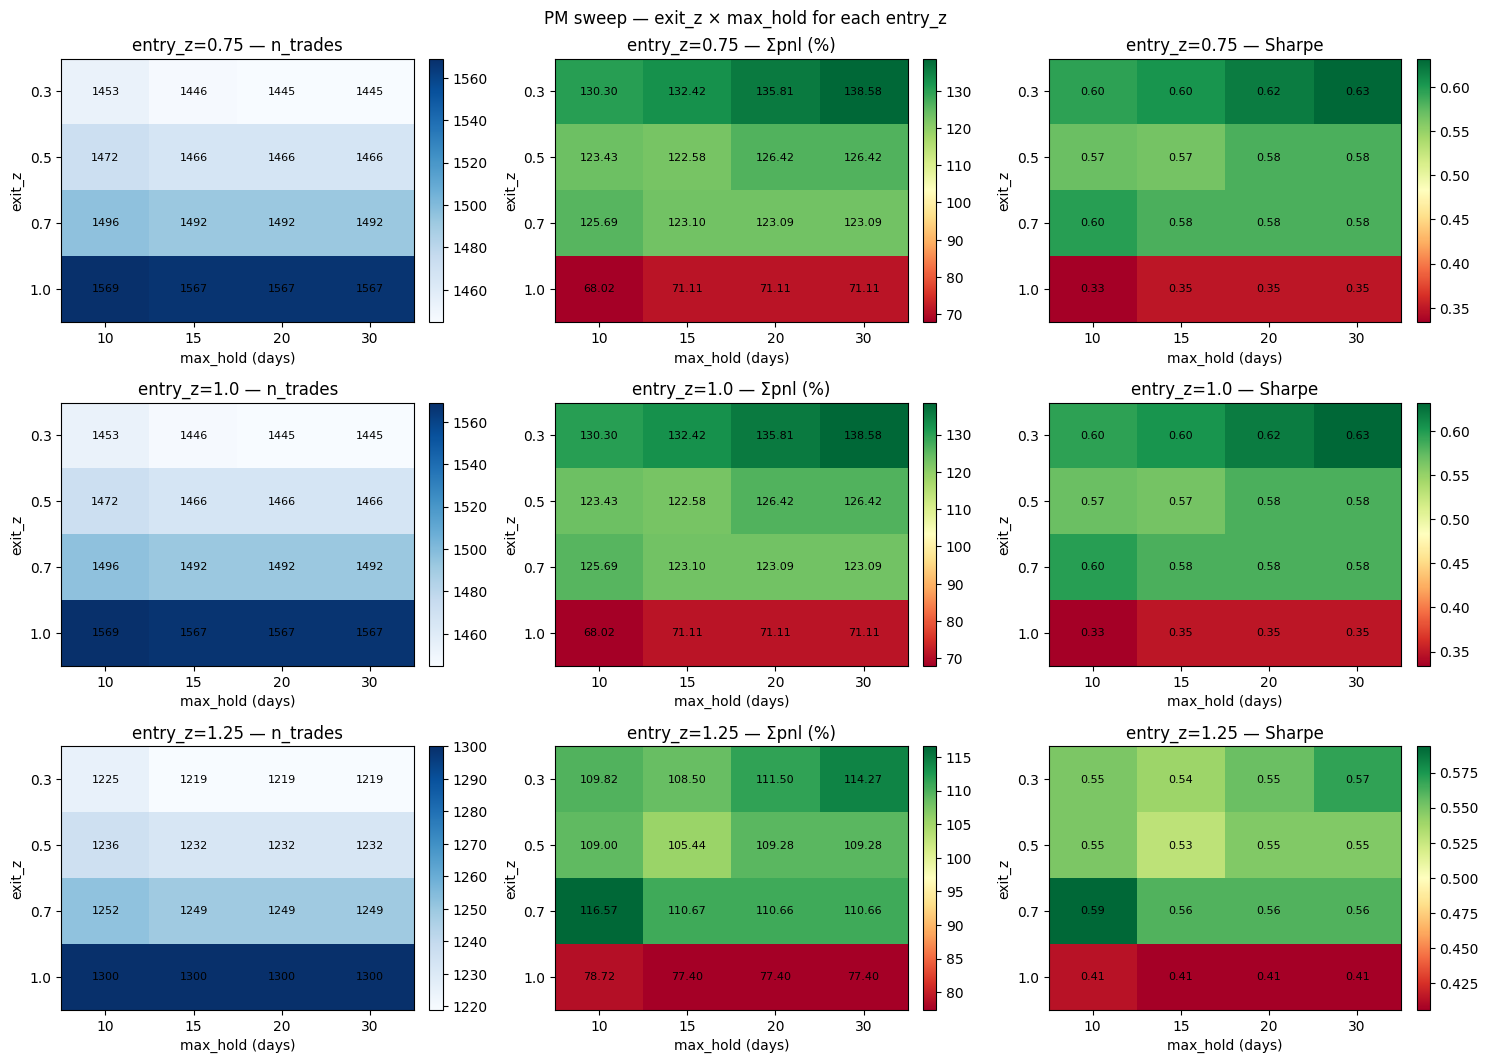

── Verdict ──
  Best Sharpe : entry=0.75, exit=0.3, hold=30d → n=1445, Sharpe=0.63, Σpnl=+138.58%, win=49.0%
  Best PnL    : entry=0.75, exit=0.3, hold=30d → n=1445, Sharpe=0.63, Σpnl=+138.58%, win=49.0%


In [17]:
# Cell 6g — PM simulation sweep on the EXISTING selected_panel
# Tests combinations of mean_reversion_exit × max_holding_days
# (and a few entry-residual thresholds) while keeping everything else
# at production defaults. READ-ONLY — does not modify production code.
#
# Uses:
#   - selected_panel  (built by Cell 8 — already in kernel)
#   - cfg             (StrategyConfig — already in kernel)
#   - PositionManager + summarize_completed_trades

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from strategy.position_manager import PositionManager, summarize_completed_trades

REQUIRED = {"signal", "P_short", "P_flat", "P_long", "residual_z", "next_ret", "target", "date"}
missing = REQUIRED - set(selected_panel.columns)
assert not missing, f"selected_panel missing required cols: {missing}"

sim_panel = selected_panel.dropna(subset=["next_ret", "residual_z"]).copy()
print(f"Simulating on {len(sim_panel):,} rows  "
      f"({sim_panel['target'].nunique()} targets, "
      f"{sim_panel['date'].nunique()} dates)")
print()

# ── Sweep grid ────────────────────────────────────────────────────────
ENTRY_Z_GRID   = [0.75, 1.00, 1.25]              # entry depth
EXIT_Z_GRID    = [0.30, 0.50, 0.70, 1.00]        # mean-reversion exit band
HOLD_GRID      = [10, 15, 20, 30]                # max_holding_days

# Hold these from production cfg
LONG_CONF      = cfg.pm_entry_confidence
SHORT_CONF     = cfg.pm_entry_confidence
FLAT_BLOCK_C   = cfg.flat_probability_block
OPP_CONF       = cfg.pm_opposite_confidence
STOP_LOSS      = cfg.pm_stop_loss
TAKE_PROFIT    = cfg.pm_take_profit
ALLOW_FLIP     = cfg.pm_allow_flip
COST_BPS       = cfg.transaction_cost_bps

print("Fixed: long_conf={:.2f}  flat_block={:.2f}  opp_conf={:.2f}  "
      "stop={:.2f}  tp={:.2f}  cost={:.1f}bps".format(
          LONG_CONF, FLAT_BLOCK_C, OPP_CONF, STOP_LOSS, TAKE_PROFIT, COST_BPS))
print()

def _metrics(trades: pd.DataFrame, sim_df: pd.DataFrame) -> dict:
    n = len(trades)
    if n == 0:
        return dict(n_trades=0, win_rate=np.nan, mean_pnl=np.nan,
                    median_pnl=np.nan, sum_pnl=0.0, sharpe=np.nan,
                    mean_hold=np.nan, pct_mr_exit=np.nan)
    pnl = trades["pnl"].astype(float)
    daily = sim_df.groupby("date")["net_pnl"].sum()
    sharpe = float(daily.mean() / daily.std() * np.sqrt(252)) if daily.std() > 0 else np.nan
    if "exit_reason" in trades.columns:
        pct_mr = float((trades["exit_reason"] == "mean_reversion_exit").mean() * 100)
    else:
        pct_mr = np.nan
    return dict(
        n_trades=int(n),
        win_rate=float((pnl > 0).mean() * 100),
        mean_pnl=float(pnl.mean() * 100),
        median_pnl=float(pnl.median() * 100),
        sum_pnl=float(pnl.sum() * 100),
        sharpe=sharpe,
        mean_hold=float(trades["holding_days"].mean()) if "holding_days" in trades.columns else np.nan,
        pct_mr_exit=pct_mr,
    )

# ── Run sweep ─────────────────────────────────────────────────────────
results = []
total = len(ENTRY_Z_GRID) * len(EXIT_Z_GRID) * len(HOLD_GRID)
i = 0
for ez in ENTRY_Z_GRID:
    for xz in EXIT_Z_GRID:
        for hd in HOLD_GRID:
            i += 1
            pm_test = PositionManager(
                long_entry_confidence=LONG_CONF,
                short_entry_confidence=SHORT_CONF,
                flat_probability_block=FLAT_BLOCK_C,
                entry_residual_threshold=ez,
                mean_reversion_exit=xz,
                opposite_signal_confidence=OPP_CONF,
                stop_loss=STOP_LOSS,
                take_profit=TAKE_PROFIT,
                max_holding_days=hd,
                allow_flip=ALLOW_FLIP,
            )
            sim_df = pm_test.simulate(sim_panel, cost_bps=COST_BPS)
            tr    = summarize_completed_trades(sim_df)
            row = dict(entry_z=ez, exit_z=xz, max_hold=hd, **_metrics(tr, sim_df))
            results.append(row)
            print(f"  [{i:>2}/{total}] entry={ez}  exit={xz}  hold={hd:>2}d  "
                  f"→ n={row['n_trades']:>4}, win={row['win_rate']:.1f}%, "
                  f"Σpnl={row['sum_pnl']:+.2f}%, Sharpe={row['sharpe']:.2f}")

res_df = pd.DataFrame(results)
print()

# ── Production baseline (for reference) ───────────────────────────────
pm_baseline = PositionManager(
    long_entry_confidence=LONG_CONF, short_entry_confidence=SHORT_CONF,
    flat_probability_block=FLAT_BLOCK_C,
    entry_residual_threshold=cfg.pm_entry_residual_z,
    mean_reversion_exit=cfg.pm_exit_residual_z,
    opposite_signal_confidence=OPP_CONF,
    stop_loss=STOP_LOSS, take_profit=TAKE_PROFIT,
    max_holding_days=cfg.pm_max_holding_days,
    allow_flip=ALLOW_FLIP,
)
base_sim = pm_baseline.simulate(sim_panel, cost_bps=COST_BPS)
base_tr  = summarize_completed_trades(base_sim)
base_m   = _metrics(base_tr, base_sim)
print("── Production baseline (current cfg) ──")
print(f"  entry={cfg.pm_entry_residual_z}  exit={cfg.pm_exit_residual_z}  "
      f"hold={cfg.pm_max_holding_days}d")
print(f"  → n_trades={base_m['n_trades']}, win={base_m['win_rate']:.1f}%, "
      f"Σpnl={base_m['sum_pnl']:+.2f}%, Sharpe={base_m['sharpe']:.2f}")
print()

# ── Top configs ───────────────────────────────────────────────────────
print("── Top 10 by Sharpe ──")
print(res_df.sort_values("sharpe", ascending=False).head(10).to_string(index=False))
print()
print("── Top 10 by total PnL ──")
print(res_df.sort_values("sum_pnl", ascending=False).head(10).to_string(index=False))
print()
print("── Top 10 by trade count ──")
print(res_df.sort_values("n_trades", ascending=False).head(10).to_string(index=False))

# ── Heatmaps ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(ENTRY_Z_GRID), 3, figsize=(15, 3.6 * len(ENTRY_Z_GRID)))
for r_i, ez in enumerate(ENTRY_Z_GRID):
    sub = res_df[res_df["entry_z"] == ez]
    pv_n  = sub.pivot(index="exit_z", columns="max_hold", values="n_trades")
    pv_pl = sub.pivot(index="exit_z", columns="max_hold", values="sum_pnl")
    pv_sh = sub.pivot(index="exit_z", columns="max_hold", values="sharpe")

    for c_i, (pv, title, cmap, fmt) in enumerate([
        (pv_n,  "n_trades",   "Blues",  "d"),
        (pv_pl, "Σpnl (%)",   "RdYlGn", ".2f"),
        (pv_sh, "Sharpe",     "RdYlGn", ".2f"),
    ]):
        ax = axes[r_i, c_i] if len(ENTRY_Z_GRID) > 1 else axes[c_i]
        heat_data = pv.values.astype(float)
        im = ax.imshow(heat_data, cmap=cmap, aspect="auto")
        ax.set_xticks(range(len(pv.columns))); ax.set_xticklabels(pv.columns)
        ax.set_yticks(range(len(pv.index)));   ax.set_yticklabels(pv.index)
        ax.set_xlabel("max_hold (days)"); ax.set_ylabel("exit_z")
        ax.set_title(f"entry_z={ez} — {title}")
        for ii in range(heat_data.shape[0]):
            for jj in range(heat_data.shape[1]):
                v = heat_data[ii, jj]
                txt = f"{int(v)}" if fmt == "d" else f"{v:{fmt}}"
                ax.text(jj, ii, txt, ha="center", va="center",
                        fontsize=8, color="black")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle("PM sweep — exit_z × max_hold for each entry_z", fontsize=12)
plt.tight_layout()
plt.show()

# ── Verdict ───────────────────────────────────────────────────────────
print("── Verdict ──")
nz = res_df[res_df["n_trades"] > 0]
if nz.empty:
    print("  ✗ NO config produced any trades. Bottleneck is upstream (classifier/signal/PM gates).")
else:
    best_sh = nz.loc[nz["sharpe"].idxmax()]
    best_pl = nz.loc[nz["sum_pnl"].idxmax()]
    print(f"  Best Sharpe : entry={best_sh['entry_z']}, exit={best_sh['exit_z']}, "
          f"hold={int(best_sh['max_hold'])}d "
          f"→ n={int(best_sh['n_trades'])}, Sharpe={best_sh['sharpe']:.2f}, "
          f"Σpnl={best_sh['sum_pnl']:+.2f}%, win={best_sh['win_rate']:.1f}%")
    print(f"  Best PnL    : entry={best_pl['entry_z']}, exit={best_pl['exit_z']}, "
          f"hold={int(best_pl['max_hold'])}d "
          f"→ n={int(best_pl['n_trades'])}, Sharpe={best_pl['sharpe']:.2f}, "
          f"Σpnl={best_pl['sum_pnl']:+.2f}%, win={best_pl['win_rate']:.1f}%")


In [18]:
# Cell 6h — Diagnose WHY PM produced zero trades
# Decompose each entry gate individually on selected_panel.

import numpy as np
import pandas as pd

sp = selected_panel.dropna(subset=["next_ret", "residual_z"]).copy()
n = len(sp)
print(f"selected_panel rows (after dropna next_ret/rz): {n:,}")
print()

# ── 1. Signal distribution ────────────────────────────────────────────
print("── signal distribution ──")
print(sp["signal"].value_counts(dropna=False).rename("count").to_frame()
      .assign(pct=lambda d: (d["count"]/n*100).round(1)))
print()

# ── 2. Probability distributions ──────────────────────────────────────
print("── P_long / P_short / P_flat summary ──")
print(sp[["P_long","P_short","P_flat"]].describe().round(3))
print()

# ── 3. residual_z distribution ────────────────────────────────────────
print("── residual_z summary ──")
print(sp["residual_z"].describe().round(3))
print(f"  |rz|>0.75 : {(sp['residual_z'].abs()>0.75).mean()*100:.1f}%")
print(f"  |rz|>1.00 : {(sp['residual_z'].abs()>1.00).mean()*100:.1f}%")
print(f"  |rz|>1.25 : {(sp['residual_z'].abs()>1.25).mean()*100:.1f}%")
print()

# ── 4. Per-gate funnel for LONG entry ─────────────────────────────────
print("── LONG entry funnel (relaxed thresholds: conf=0.50, flat<0.50, entry_z=0.75) ──")
RELAX_CONF, RELAX_FLAT, RELAX_EZ = 0.50, 0.50, 0.75
g0 = sp.copy()
g1 = g0[g0["signal"] == 1]
g2 = g1[g1["P_long"] >= RELAX_CONF]
g3 = g2[g2["residual_z"] <= -RELAX_EZ]
g4 = g3[g3["P_flat"] < RELAX_FLAT]
print(f"  all rows                       : {len(g0):>6,}")
print(f"  signal == +1                   : {len(g1):>6,}  ({len(g1)/n*100:5.1f}%)")
print(f"  & P_long >= {RELAX_CONF}            : {len(g2):>6,}  ({len(g2)/n*100:5.1f}%)")
print(f"  & residual_z <= -{RELAX_EZ}        : {len(g3):>6,}  ({len(g3)/n*100:5.1f}%)")
print(f"  & P_flat < {RELAX_FLAT}             : {len(g4):>6,}  ({len(g4)/n*100:5.1f}%)  ← would enter LONG")
print()

print("── SHORT entry funnel (same relaxed thresholds) ──")
g1 = g0[g0["signal"] == -1]
g2 = g1[g1["P_short"] >= RELAX_CONF]
g3 = g2[g2["residual_z"] >= RELAX_EZ]
g4 = g3[g3["P_flat"] < RELAX_FLAT]
print(f"  signal == -1                   : {len(g1):>6,}  ({len(g1)/n*100:5.1f}%)")
print(f"  & P_short >= {RELAX_CONF}           : {len(g2):>6,}  ({len(g2)/n*100:5.1f}%)")
print(f"  & residual_z >= +{RELAX_EZ}        : {len(g3):>6,}  ({len(g3)/n*100:5.1f}%)")
print(f"  & P_flat < {RELAX_FLAT}             : {len(g4):>6,}  ({len(g4)/n*100:5.1f}%)  ← would enter SHORT")
print()

# ── 5. Joint distribution of (signal, sign(rz)) ───────────────────────
print("── Joint distribution: signal × sign(residual_z) ──")
print("  (mean-reversion strategy needs signal=+1 with rz<0, signal=-1 with rz>0)")
sp["rz_sign"] = np.sign(sp["residual_z"]).astype(int)
print(pd.crosstab(sp["signal"], sp["rz_sign"], margins=True))


selected_panel rows (after dropna next_ret/rz): 5,640

── signal distribution ──
        count   pct
signal             
-1       2048  36.3
 1       1816  32.2
 0       1776  31.5

── P_long / P_short / P_flat summary ──
         P_long   P_short    P_flat
count  5640.000  5640.000  5640.000
mean      0.293     0.322     0.385
std       0.425     0.428     0.420
min       0.000     0.000     0.003
25%       0.000     0.000     0.074
50%       0.000     0.000     0.144
75%       0.862     0.849     1.000
max       0.997     0.996     1.000

── residual_z summary ──
count    5640.000
mean        0.078
std         1.540
min        -5.681
25%        -1.237
50%         0.312
75%         1.352
max         5.343
Name: residual_z, dtype: float64
  |rz|>0.75 : 81.0%
  |rz|>1.00 : 68.5%
  |rz|>1.25 : 52.7%

── LONG entry funnel (relaxed thresholds: conf=0.50, flat<0.50, entry_z=0.75) ──
  all rows                       :  5,640
  signal == +1                   :  1,816  ( 32.2%)
  & P_long >= 0

In [19]:
# Cell 6i — OPTION 1: A/B run PM on selected_panel using REVERSION-label classifier
# Replaces P_long/P_short/P_flat in selected_panel with predictions from clf_new
# (the reversion-label XGB built in Cell 6c) and re-runs the funnel + PM sweep.
#
# Also trains a 2nd reversion classifier at h=12 (Cell 6e's winning horizon).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier as _XGB
from sklearn.utils.class_weight import compute_sample_weight
from strategy.reversion_labels import make_reversion_labels_on_panel
from strategy.position_manager import PositionManager, summarize_completed_trades

# ── 1. Build a 2nd classifier at h=12 (best horizon from 6e) ──────────
REV_H12 = 12
rev_labels_h12 = make_reversion_labels_on_panel(
    panel, h=REV_H12, entry_band=1.0, close_band=0.5,
    date_col="date", cand_col="target", rz_col="residual_z",
)
panel_h12 = panel.copy()
panel_h12["label_rev12"] = rev_labels_h12.values
both_h12  = panel_h12.dropna(subset=["label", "label_rev12"]).copy()

X_h12 = both_h12[feature_cols].apply(pd.to_numeric, errors="coerce")
X_h12 = X_h12.groupby(both_h12["target"]).ffill().fillna(0.0)
y_h12 = both_h12["label_rev12"].map({-1.0: 0, 0.0: 1, 1.0: 2}).astype(int)

_p = dict(cfg.clf_params)
_p.update({"num_class": 3, "objective": "multi:softprob",
           "verbosity": 0, "random_state": int(cfg.random_state)})
clf_h12 = _XGB(**_p)
sw_h12 = compute_sample_weight(class_weight="balanced", y=y_h12)
clf_h12.fit(X_h12, y_h12, sample_weight=sw_h12)
print(f"Trained clf_h12 (reversion, h={REV_H12}). Class counts: "
      f"{dict(y_h12.value_counts().rename({0:'short',1:'flat',2:'long'}).items())}")
print()

# ── 2. Align selected_panel rows to feature matrix ────────────────────
sp_base = selected_panel.dropna(subset=["next_ret", "residual_z"]).copy()
panel_feats = panel[["date", "target"] + list(feature_cols)].drop_duplicates(
    subset=["date", "target"], keep="last"
)
sp = sp_base.merge(panel_feats, on=["date", "target"], how="left",
                   suffixes=("", "_feat"))
sp = sp.dropna(subset=feature_cols, how="all").copy()
if "sector" not in sp.columns:
    sp["sector"] = "diag"
X_sp = sp[feature_cols].apply(pd.to_numeric, errors="coerce")
X_sp = X_sp.groupby(sp["target"]).ffill().fillna(0.0)
print(f"selected_panel rows for PM test: {len(sp):,}")

# ── 3. Predict with both reversion classifiers ────────────────────────
proba_h5  = clf_new.predict_proba(X_sp)   # from Cell 6c, h=5
proba_h12 = clf_h12.predict_proba(X_sp)

def _attach_probs(df, P):
    out = df.copy()
    out["P_short"] = P[:, 0]
    out["P_flat"]  = P[:, 1]
    out["P_long"]  = P[:, 2]
    return out

sp_h5  = _attach_probs(sp, proba_h5)
sp_h12 = _attach_probs(sp, proba_h12)

print()
print("── Probability summary (max-prob mean / pass-rates) ──")
for name, P in [("OLD prod clf_old (fwd ±1%)", sp[["P_long","P_short","P_flat"]].values),
                ("NEW clf_new       (rev h=5)", proba_h5),
                ("NEW clf_h12       (rev h=12)", proba_h12)]:
    mx = P.max(axis=1)
    print(f"  {name}: mean_maxp={mx.mean():.3f}, "
          f">=0.50: {(mx>=0.50).mean()*100:5.1f}%, "
          f">=0.60: {(mx>=0.60).mean()*100:5.1f}%, "
          f">=0.65: {(mx>=0.65).mean()*100:5.1f}%")
print()

# ── 4. Entry funnel ───────────────────────────────────────────────────
def _funnel(df, label, conf=0.50, flat=0.50, ez=0.75):
    n = len(df)
    g = df[(df["signal"] == 1) & (df["P_long"]  >= conf) &
           (df["residual_z"] <= -ez) & (df["P_flat"] < flat)]
    long_n = len(g)
    g = df[(df["signal"] == -1) & (df["P_short"] >= conf) &
           (df["residual_z"] >=  ez) & (df["P_flat"] < flat)]
    short_n = len(g)
    print(f"   {label:<28}: LONG={long_n:>4}  SHORT={short_n:>4}  TOTAL={long_n+short_n:>4}")

print(f"── Entry funnel (conf>=0.50, P_flat<0.50, |entry_z|>=0.75) ──")
_funnel(sp,     "OLD prod (fwd ±1%)")
_funnel(sp_h5,  "NEW reversion h=5")
_funnel(sp_h12, "NEW reversion h=12")
print()

# ── 5. PM simulation ──────────────────────────────────────────────────
def _run_pm(df, label, entry_z=1.0, exit_z=0.5, hold=15, conf=0.50, flat_block=0.50):
    pm = PositionManager(
        long_entry_confidence=conf, short_entry_confidence=conf,
        flat_probability_block=flat_block,
        entry_residual_threshold=entry_z,
        mean_reversion_exit=exit_z,
        opposite_signal_confidence=cfg.pm_opposite_confidence,
        stop_loss=cfg.pm_stop_loss, take_profit=cfg.pm_take_profit,
        max_holding_days=hold, allow_flip=cfg.pm_allow_flip,
    )
    sim = pm.simulate(df, cost_bps=cfg.transaction_cost_bps)
    tr  = summarize_completed_trades(sim)
    n = len(tr)
    if n == 0:
        print(f"  {label:<28}: 0 trades")
        return tr, sim
    pnl   = tr["pnl"].astype(float)
    daily = sim.groupby("date")["net_pnl"].sum()
    sharpe = float(daily.mean()/daily.std()*np.sqrt(252)) if daily.std() > 0 else np.nan
    pct_mr = float((tr["exit_reason"]=="mean_reversion_exit").mean()*100) \
             if "exit_reason" in tr.columns else np.nan
    mh = float(tr["holding_period"].mean()) if "holding_period" in tr.columns else float("nan")
    print(f"  {label:<28}: n={n:>4} win={float((pnl>0).mean()*100):5.1f}% "
          f"Σpnl={float(pnl.sum()*100):+7.2f}% Sharpe={sharpe:5.2f} "
          f"mr_exit={pct_mr:5.1f}% mean_hold={mh:4.1f}d")
    return tr, sim

print("── PM run with conf=0.50, flat<0.50, entry_z=1.0, exit_z=0.5, hold=15d ──")
_run_pm(sp,     "OLD prod (fwd ±1%)")
_run_pm(sp_h5,  "NEW reversion h=5")
_run_pm(sp_h12, "NEW reversion h=12")
print()

# ── 6. Sweep (conf × flat_block) on clf_h12 ───────────────────────────
print("── Sweep (conf × flat_block) on clf_h12, entry_z=1.0, exit_z=0.5, hold=15d ──")
rows_sweep = []
for conf in [0.40, 0.45, 0.50, 0.55, 0.60, 0.65]:
    for fb in [0.50, 0.55, 0.60]:
        pm = PositionManager(
            long_entry_confidence=conf, short_entry_confidence=conf,
            flat_probability_block=fb,
            entry_residual_threshold=1.0, mean_reversion_exit=0.5,
            opposite_signal_confidence=cfg.pm_opposite_confidence,
            stop_loss=cfg.pm_stop_loss, take_profit=cfg.pm_take_profit,
            max_holding_days=15, allow_flip=cfg.pm_allow_flip,
        )
        sim = pm.simulate(sp_h12, cost_bps=cfg.transaction_cost_bps)
        tr  = summarize_completed_trades(sim)
        n = len(tr)
        if n == 0:
            rows_sweep.append(dict(conf=conf, flat_block=fb, n=0,
                                   win=np.nan, sum_pnl=0.0, sharpe=np.nan))
            continue
        pnl = tr["pnl"].astype(float)
        daily = sim.groupby("date")["net_pnl"].sum()
        sharpe = float(daily.mean()/daily.std()*np.sqrt(252)) if daily.std()>0 else np.nan
        rows_sweep.append(dict(conf=conf, flat_block=fb, n=n,
                               win=round(float((pnl>0).mean()*100), 1),
                               sum_pnl=round(float(pnl.sum()*100), 2),
                               sharpe=round(sharpe, 2) if np.isfinite(sharpe) else np.nan))
sweep_df = pd.DataFrame(rows_sweep)
print(sweep_df.to_string(index=False))


Trained clf_h12 (reversion, h=12). Class counts: {'flat': 54839, 'short': 10326, 'long': 9255}

selected_panel rows for PM test: 5,640

── Probability summary (max-prob mean / pass-rates) ──
  OLD prod clf_old (fwd ±1%): mean_maxp=0.929, >=0.50: 100.0%, >=0.60: 100.0%, >=0.65: 100.0%
  NEW clf_new       (rev h=5): mean_maxp=0.929, >=0.50: 100.0%, >=0.60: 100.0%, >=0.65:  99.9%
  NEW clf_h12       (rev h=12): mean_maxp=0.955, >=0.50: 100.0%, >=0.60: 100.0%, >=0.65: 100.0%

── Entry funnel (conf>=0.50, P_flat<0.50, |entry_z|>=0.75) ──
   OLD prod (fwd ±1%)          : LONG=1816  SHORT=2048  TOTAL=3864
   NEW reversion h=5           : LONG=1816  SHORT=2047  TOTAL=3863
   NEW reversion h=12          : LONG=1816  SHORT=2048  TOTAL=3864

── PM run with conf=0.50, flat<0.50, entry_z=1.0, exit_z=0.5, hold=15d ──


  OLD prod (fwd ±1%)          : n=1466 win= 49.2% Σpnl=+124.48% Sharpe= 0.57 mr_exit= 50.1% mean_hold= 2.6d


  NEW reversion h=5           : n=1466 win= 49.2% Σpnl=+122.58% Sharpe= 0.57 mr_exit= 50.1% mean_hold= 2.6d


  NEW reversion h=12          : n=1466 win= 49.2% Σpnl=+124.48% Sharpe= 0.57 mr_exit= 50.1% mean_hold= 2.6d

── Sweep (conf × flat_block) on clf_h12, entry_z=1.0, exit_z=0.5, hold=15d ──


 conf  flat_block    n  win  sum_pnl  sharpe
 0.40        0.50 1466 49.2   124.48    0.57
 0.40        0.55 1466 49.2   124.48    0.57
 0.40        0.60 1466 49.2   124.48    0.57
 0.45        0.50 1466 49.2   124.48    0.57
 0.45        0.55 1466 49.2   124.48    0.57
 0.45        0.60 1466 49.2   124.48    0.57
 0.50        0.50 1466 49.2   124.48    0.57
 0.50        0.55 1466 49.2   124.48    0.57
 0.50        0.60 1466 49.2   124.48    0.57
 0.55        0.50 1466 49.2   124.48    0.57
 0.55        0.55 1466 49.2   124.48    0.57
 0.55        0.60 1466 49.2   124.48    0.57
 0.60        0.50 1466 49.2   124.48    0.57
 0.60        0.55 1466 49.2   124.48    0.57
 0.60        0.60 1466 49.2   124.48    0.57
 0.65        0.50 1466 49.2   124.48    0.57
 0.65        0.55 1466 49.2   124.48    0.57
 0.65        0.60 1466 49.2   124.48    0.57


In [20]:
# ── D1: TARGET SELECTION ──────────────────────────────────────────────────────
# Q1-4: Which target each day, switching frequency, distribution, top 10

sp = selected_panel.copy()
sp["date"] = pd.to_datetime(sp["date"])

print("=" * 65)
print("D1 — TARGET SELECTION DIAGNOSTICS")
print("=" * 65)
print(f"Eval period:  {sp['date'].min().date()} → {sp['date'].max().date()}")
print(f"Eval dates:   {sp['date'].nunique()}")
print(f"Sectors:      {sp['sector'].nunique()}")
print()

# ── Q3: Distribution of selections by sector and stock ───────────────────────
print("── Selection counts by sector and stock ──")
sel_dist = (
    sp.groupby(["sector", "target"])
    .size()
    .reset_index(name="days_selected")
    .sort_values(["sector", "days_selected"], ascending=[True, False])
)
sel_dist["pct_of_sector"] = (
    sel_dist["days_selected"]
    / sel_dist.groupby("sector")["days_selected"].transform("sum")
    * 100
).round(1)
display(sel_dist.to_string(index=False))
print()

# ── Q4: Top 10 most frequently selected targets ───────────────────────────────
print("── Top 10 most frequently selected targets (all sectors) ──")
top10 = (
    sp.groupby("target")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .rename("days_selected")
    .to_frame()
)
top10["pct_of_total"] = (top10["days_selected"] / len(sp) * 100).round(2)
display(top10)
print()

# ── Q2: Target switching frequency ────────────────────────────────────────────
print("── Target switching frequency per sector ──")
switch_rows = []
for sector, grp in sp.sort_values("date").groupby("sector"):
    targets_series = grp.sort_values("date")["target"]
    n_switches = int((targets_series != targets_series.shift(1)).sum()) - 1
    switch_rows.append({
        "sector":              sector,
        "eval_dates":          len(grp),
        "target_switches":     max(0, n_switches),
        "switch_rate_%":       round(max(0, n_switches) / max(1, len(grp) - 1) * 100, 1),
        "unique_targets":      grp["target"].nunique(),
        "dominant_target":     grp["target"].mode().iloc[0],
        "dominant_pct_%":      round(grp["target"].value_counts(normalize=True).iloc[0] * 100, 1),
    })
switch_df = pd.DataFrame(switch_rows).sort_values("switch_rate_%", ascending=False)
display(switch_df.to_string(index=False))
print()

# ── Q1: Sample of daily selected targets (first 30 dates, all sectors) ────────
print("── Sample: first 30 evaluation dates, selected target per sector ──")
sample_dates = sorted(sp["date"].unique())[:30]
sample_pivot = (
    sp[sp["date"].isin(sample_dates)]
    .pivot_table(index="date", columns="sector", values="target", aggfunc="first")
)
display(sample_pivot)


D1 — TARGET SELECTION DIAGNOSTICS
Eval period:  2022-01-03 → 2024-04-02
Eval dates:   564
Sectors:      10

── Selection counts by sector and stock ──


'          sector target  days_selected  pct_of_sector\n   Communication   PINS            144           25.5\n   Communication   META             78           13.8\n   Communication  GOOGL             68           12.1\n   Communication   MTCH             67           11.9\n   Communication   SNAP             65           11.5\n   Communication    TTD             43            7.6\n   Communication   ROKU             24            4.3\n   Communication    WBD             24            4.3\n   Communication   NFLX             20            3.5\n   Communication    DIS             17            3.0\n   Communication   SPOT             14            2.5\n  Consumer Disc.   BKNG             99           17.6\n  Consumer Disc.   LULU             83           14.7\n  Consumer Disc.    LOW             61           10.8\n  Consumer Disc.    NKE             58           10.3\n  Consumer Disc.   TSLA             51            9.0\n  Consumer Disc.   EXPE             46            8.2\n  Consume


── Top 10 most frequently selected targets (all sectors) ──


,days_selected,pct_of_total
target,,
PSA,203,3.60
SO,164,2.91
PINS,144,2.55
AVGO,133,2.36
UNH,129,2.29
COP,127,2.25
DUK,114,2.02
AA,105,1.86
JNJ,104,1.84



── Target switching frequency per sector ──


'          sector  eval_dates  target_switches  switch_rate_%  unique_targets dominant_target  dominant_pct_%\n       Materials         564              428           76.0              11              AA            18.6\nConsumer Staples         564              427           75.8              11              CL            14.9\n      Financials         564              422           75.0              11             AXP            17.0\n          Energy         564              412           73.2              11             COP            22.5\n  Consumer Disc.         564              407           72.3              11            BKNG            17.6\n       Utilities         564              392           69.6              11              SO            29.1\n      Technology         564              385           68.4              11            AVGO            23.6\n     Health Care         564              381           67.7              11             UNH            22.9\n   Commun


── Sample: first 30 evaluation dates, selected target per sector ──


sector,Communication,Consumer Disc.,Consumer Staples,Energy,Financials,Health Care,Materials,Real Estate,Technology,Utilities
date,,,,,,,,,,
2022-01-03,SPOT,LOW,PM,WMB,MA,CVS,FCX,EQR,ASML,SRE
2022-01-04,SNAP,AMZN,HSY,WMB,JPM,CI,FCX,CCI,AMD,SRE
2022-01-05,SNAP,NKE,KO,PSX,SCHW,DHR,CLF,EQR,ORCL,SRE
2022-01-06,TTD,LOW,HSY,PSX,WFC,TMO,SCCO,SPG,TSM,NEE
2022-01-07,TTD,NKE,PM,SLB,BLK,HUM,FCX,EQR,ORCL,D
2022-01-10,TTD,TSLA,PM,WMB,BLK,JNJ,AA,EQIX,SMCI,NEE
2022-01-11,TTD,TSLA,MDLZ,XOM,BLK,HUM,TECK,PSA,INTC,AEP
2022-01-12,NFLX,LULU,KMB,MPC,SCHW,TMO,NUE,PLD,NVDA,AWK
2022-01-13,TTD,SBUX,PM,MPC,C,PFE,TECK,PSA,SMCI,AWK


D2 — DBTS SCORE BEHAVIOR
Total candidate-day rows: 62,040

── DBTS component score statistics ──


,bandit_score,residual_score,pred_ret_score,adf_score,final_score
count,62040.0000,62040.0000,62040.0000,62040.0000,62040.0000
mean,0.4482,0.2792,0.1086,0.9811,0.4180
std,0.2302,0.1982,0.1220,0.1081,0.1086
min,0.0000,0.0000,0.0000,0.0000,0.0014
25%,0.2714,0.1214,0.0320,1.0000,0.3397
50%,0.4509,0.2499,0.0721,1.0000,0.4170
75%,0.6185,0.3979,0.1391,1.0000,0.4936
max,0.9998,1.0000,1.0000,1.0000,0.8647


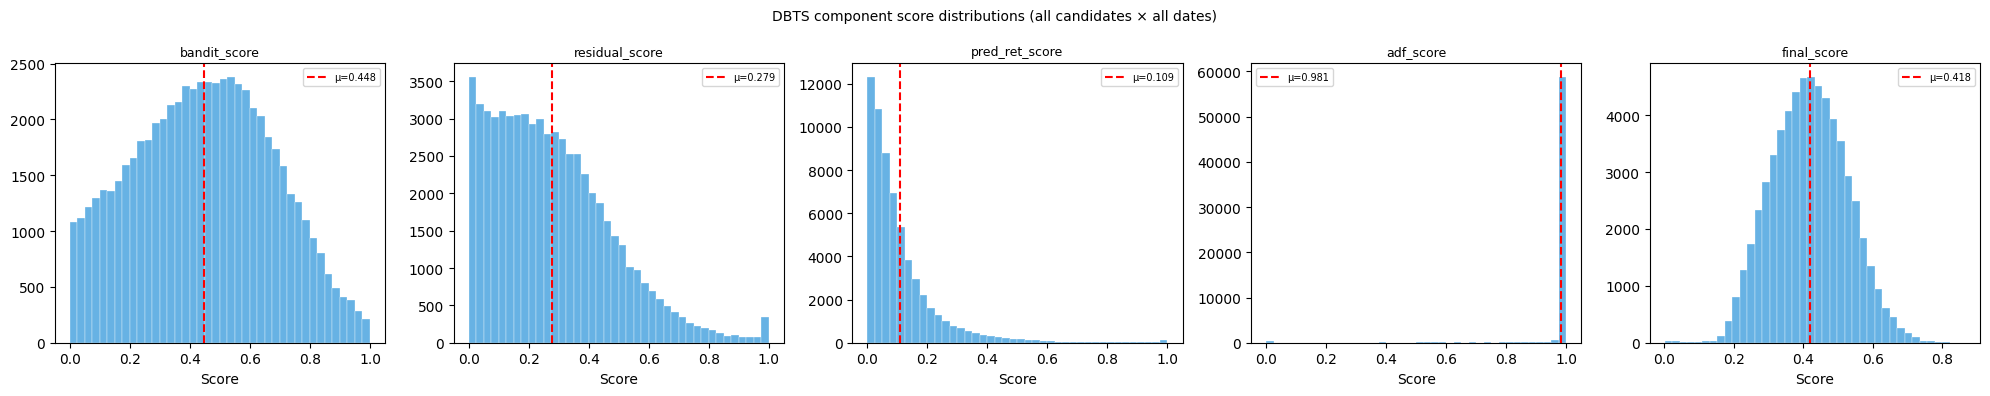


── Winner vs runner-up analysis ──


Total winner-runnerup pairs: 5,640

── Margin statistics ──


count    5640.0000
mean        0.0496
std         0.0428
min         0.0000
25%         0.0166
50%         0.0381
75%         0.0708
max         0.2878
Name: margin, dtype: float64


── 20 closest contests (smallest winning margin) ──


'      date           sector winner  winner_score runnerup  runnerup_score  margin\n2022-01-31 Consumer Staples     KO        0.5379      KMB          0.5378  0.0000\n2022-08-22       Technology    AMD        0.5652     ORCL          0.5652  0.0000\n2023-04-28      Real Estate    EQR        0.4742      PSA          0.4741  0.0000\n2023-05-05           Energy    COP        0.4841      SLB          0.4841  0.0000\n2023-12-27       Technology    TSM        0.6334     ANET          0.6334  0.0000\n2022-08-15 Consumer Staples     CL        0.5550     MDLZ          0.5549  0.0001\n2023-01-06       Financials    JPM        0.5448      BLK          0.5446  0.0001\n2023-03-14 Consumer Staples    HSY        0.4673     COST          0.4672  0.0001\n2023-05-23    Communication    DIS        0.5699     META          0.5698  0.0001\n2023-05-25   Consumer Disc.   BKNG        0.5673      NKE          0.5672  0.0001\n2023-08-31        Materials    SQM        0.5570     TECK          0.5569  0.0001\n202

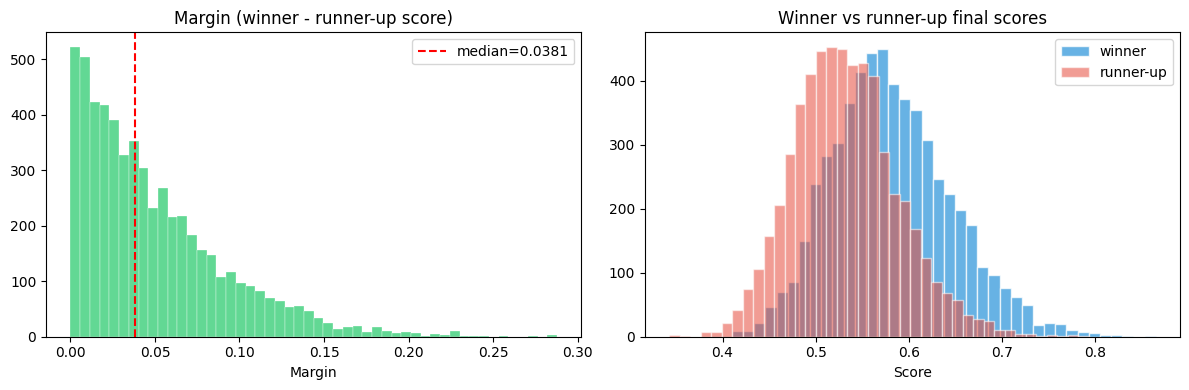

── Sample: 10 dates showing winner component breakdown vs runner-up ──

  2022-01-18 | Consumer Disc.
  WINNER   HD      : final=0.7115 bandit=0.924 resid=0.716 pred_ret=0.064 adf=1.000 (rz=-2.15)
  RUNNER-UP SBUX    : final=0.6296 bandit=0.652 resid=0.841 pred_ret=0.042 adf=1.000 (rz=-2.52)
  MARGIN: 0.0819

  2022-01-26 | Real Estate
  WINNER   EQIX    : final=0.6892 bandit=0.807 resid=0.824 pred_ret=0.054 adf=1.000 (rz=-2.47)
  RUNNER-UP DLR     : final=0.6825 bandit=0.957 resid=0.499 pred_ret=0.124 adf=1.000 (rz=-1.50)
  MARGIN: 0.0067

  2022-08-23 | Utilities
  WINNER   SO      : final=0.5849 bandit=0.900 resid=0.289 pred_ret=0.012 adf=1.000 (rz=0.87)
  RUNNER-UP NEE     : final=0.4905 bandit=0.566 resid=0.334 pred_ret=0.152 adf=1.000 (rz=1.00)
  MARGIN: 0.0944

  2022-09-23 | Communication
  WINNER   PINS    : final=0.6164 bandit=0.626 resid=0.065 pred_ret=1.000 adf=1.000 (rz=-0.19)
  RUNNER-UP META    : final=0.5706 bandit=0.594 resid=0.162 pred_ret=0.712 adf=1.000 (rz=-0.49)
 

In [21]:
# ── D2: DBTS SCORE BEHAVIOR ───────────────────────────────────────────────────
# Q5-8: Daily scores, why winner beat runner-up, score distribution, close contests

ds = daily_scores.copy()
ds["date"] = pd.to_datetime(ds["date"])

print("=" * 65)
print("D2 — DBTS SCORE BEHAVIOR")
print("=" * 65)
print(f"Total candidate-day rows: {len(ds):,}")
print()

# ── Q7: Distribution of DBTS component scores ─────────────────────────────────
print("── DBTS component score statistics ──")
score_cols = ["bandit_score", "residual_score", "pred_ret_score", "adf_score", "final_score"]
available_score_cols = [c for c in score_cols if c in ds.columns]
display(ds[available_score_cols].describe().round(4))
print()

fig, axes = plt.subplots(1, len(available_score_cols), figsize=(4*len(available_score_cols), 4))
if len(available_score_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, available_score_cols):
    ax.hist(ds[col].dropna(), bins=40, alpha=0.75, color="#3498db", edgecolor="white", linewidth=0.3)
    ax.axvline(ds[col].mean(), color="red", lw=1.5, ls="--", label=f"μ={ds[col].mean():.3f}")
    ax.set_title(col, fontsize=9); ax.legend(fontsize=7); ax.set_xlabel("Score")
plt.suptitle("DBTS component score distributions (all candidates × all dates)", fontsize=10)
plt.tight_layout(); plt.show()
print()

# ── Q5-6: Winner vs runner-up per sector per date ─────────────────────────────
print("── Winner vs runner-up analysis ──")
margin_rows = []
for (date, sector), grp in ds.groupby(["date", "sector"]):
    sorted_scores = grp[["candidate", "final_score"]].dropna().sort_values("final_score", ascending=False)
    if len(sorted_scores) < 2:
        continue
    winner  = sorted_scores.iloc[0]
    runnerup = sorted_scores.iloc[1]
    margin_rows.append({
        "date":          date,
        "sector":        sector,
        "winner":        winner["candidate"],
        "winner_score":  round(winner["final_score"], 4),
        "runnerup":      runnerup["candidate"],
        "runnerup_score": round(runnerup["final_score"], 4),
        "margin":        round(winner["final_score"] - runnerup["final_score"], 4),
    })

margin_df = pd.DataFrame(margin_rows)
print(f"Total winner-runnerup pairs: {len(margin_df):,}")
print()
print("── Margin statistics ──")
display(margin_df["margin"].describe().round(4))
print()

# ── Q8: Closest contests (margin < 10th percentile) ──────────────────────────
print("── 20 closest contests (smallest winning margin) ──")
display(margin_df.nsmallest(20, "margin").reset_index(drop=True).to_string(index=False))
print()

# ── Margin histogram ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(margin_df["margin"], bins=50, alpha=0.75, color="#2ecc71", edgecolor="white", linewidth=0.3)
ax1.axvline(margin_df["margin"].median(), color="red", lw=1.5, ls="--",
            label=f"median={margin_df['margin'].median():.4f}")
ax1.set_title("Margin (winner - runner-up score)"); ax1.set_xlabel("Margin"); ax1.legend()
ax2.hist(margin_df["winner_score"], bins=40, alpha=0.75, color="#3498db", label="winner", edgecolor="white")
ax2.hist(margin_df["runnerup_score"], bins=40, alpha=0.55, color="#e74c3c", label="runner-up", edgecolor="white")
ax2.set_title("Winner vs runner-up final scores"); ax2.set_xlabel("Score"); ax2.legend()
plt.tight_layout(); plt.show()

# ── Q6: Why the winner won — show top components on some examples ────────────
print("── Sample: 10 dates showing winner component breakdown vs runner-up ──")
_sample = margin_df.sample(min(10, len(margin_df)), random_state=42).sort_values("date")
for _, row in _sample.iterrows():
    w_row = ds[(ds["date"] == row["date"]) & (ds["sector"] == row["sector"]) & (ds["candidate"] == row["winner"])]
    r_row = ds[(ds["date"] == row["date"]) & (ds["sector"] == row["sector"]) & (ds["candidate"] == row["runnerup"])]
    if w_row.empty or r_row.empty:
        continue
    wr, rr = w_row.iloc[0], r_row.iloc[0]
    print(f"\n  {row['date'].date()} | {row['sector']}")
    print(f"  WINNER   {row['winner']:8s}: final={wr['final_score']:.4f} "
          f"bandit={wr.get('bandit_score', float('nan')):.3f} "
          f"resid={wr.get('residual_score', float('nan')):.3f} "
          f"pred_ret={wr.get('pred_ret_score', float('nan')):.3f} "
          f"adf={wr.get('adf_score', float('nan')):.3f} "
          f"(rz={wr.get('residual_z', float('nan')):.2f})")
    print(f"  RUNNER-UP {row['runnerup']:8s}: final={rr['final_score']:.4f} "
          f"bandit={rr.get('bandit_score', float('nan')):.3f} "
          f"resid={rr.get('residual_score', float('nan')):.3f} "
          f"pred_ret={rr.get('pred_ret_score', float('nan')):.3f} "
          f"adf={rr.get('adf_score', float('nan')):.3f} "
          f"(rz={rr.get('residual_z', float('nan')):.2f})")
    print(f"  MARGIN: {row['margin']:.4f}")


D3 — RESIDUAL SIGNAL BEHAVIOR
Total residual_z observations: 61,570

── residual_z distribution statistics ──


,residual_z
count,61570.0000
mean,0.0412
std,1.0387
min,-5.6807
25%,-0.7170
50%,0.0561
75%,0.7923
max,5.3427



── Threshold crossing rates ──


' threshold  |rz| > thr (n)  |rz| > thr (%)\n       0.5           40997            66.6\n       1.0           21836            35.5\n       1.5            8408            13.7\n       2.0            2681             4.4\n       2.5             847             1.4\n       3.0             309             0.5'

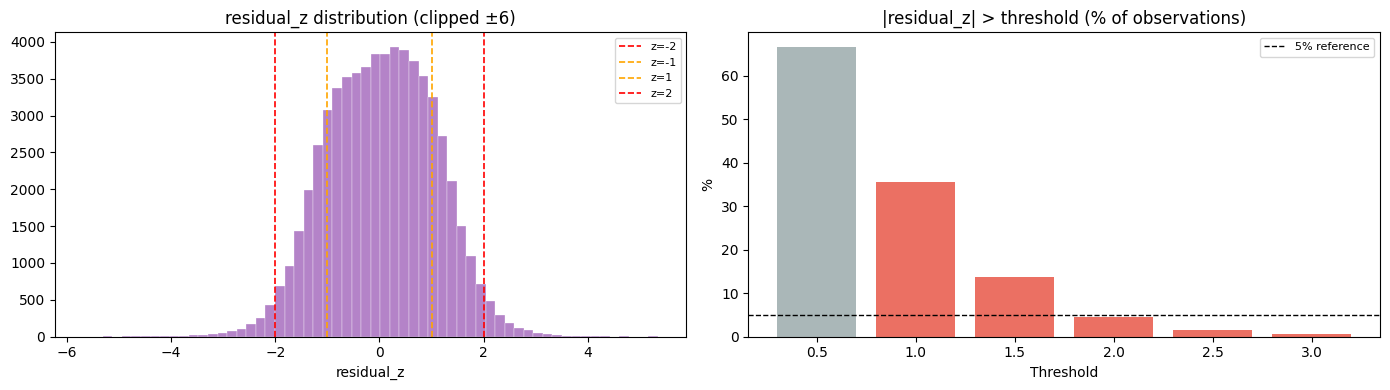

── 15 largest POSITIVE residual_z events (mean reversion SHORT candidates) ──


'      date           sector candidate  residual_z  final_score\n2024-01-16    Communication     GOOGL    5.342727     0.604944\n2024-02-12       Technology       ARM    5.274246     0.475660\n2022-08-10    Communication       TTD    5.204687     0.508318\n2024-02-02    Communication      META    5.024066     0.665675\n2024-03-15        Materials      SCCO    4.813042     0.643369\n2023-05-26       Technology      AVGO    4.747762     0.682547\n2023-05-25       Technology      NVDA    4.671701     0.576051\n2022-05-04       Technology      SMCI    4.381409     0.661429\n2023-01-27       Technology        MU    4.367732     0.476382\n2023-01-27       Financials       AXP    4.359713     0.710022\n2023-09-01      Health Care       CVS    4.352089     0.469968\n2023-07-12      Health Care       CVS    4.268713     0.519251\n2024-01-26 Consumer Staples       TGT    4.205332     0.645550\n2023-01-30       Financials         C    4.193518     0.544698\n2023-12-14       Financials       WFC  


── 15 largest NEGATIVE residual_z events (mean reversion LONG candidates) ──


'      date           sector candidate  residual_z  final_score\n2024-02-29        Utilities       XEL   -5.680692     0.611612\n2022-01-06      Health Care       HUM   -5.164000     0.617846\n2022-06-23   Consumer Disc.       MAR   -5.140223     0.681423\n2023-07-31    Communication      SNAP   -4.940870     0.722934\n2024-03-01        Utilities       XEL   -4.907593     0.559045\n2023-07-28    Communication      SNAP   -4.719419     0.705715\n2023-01-25        Utilities       NEE   -4.673996     0.539826\n2022-09-02           Energy       XOM   -4.534218     0.531579\n2023-10-05 Consumer Staples        KO   -4.457140     0.616287\n2022-10-07        Utilities       XEL   -4.444597     0.587244\n2022-09-02        Materials       SQM   -4.418086     0.542417\n2023-04-28    Communication      PINS   -4.413872     0.780898\n2023-11-27    Communication      MTCH   -4.391055     0.602992\n2023-07-12    Communication      ROKU   -4.357470     0.715101\n2024-01-26      Health Care       UNH  


── residual_z time series (one line per sector — dominant target) ──


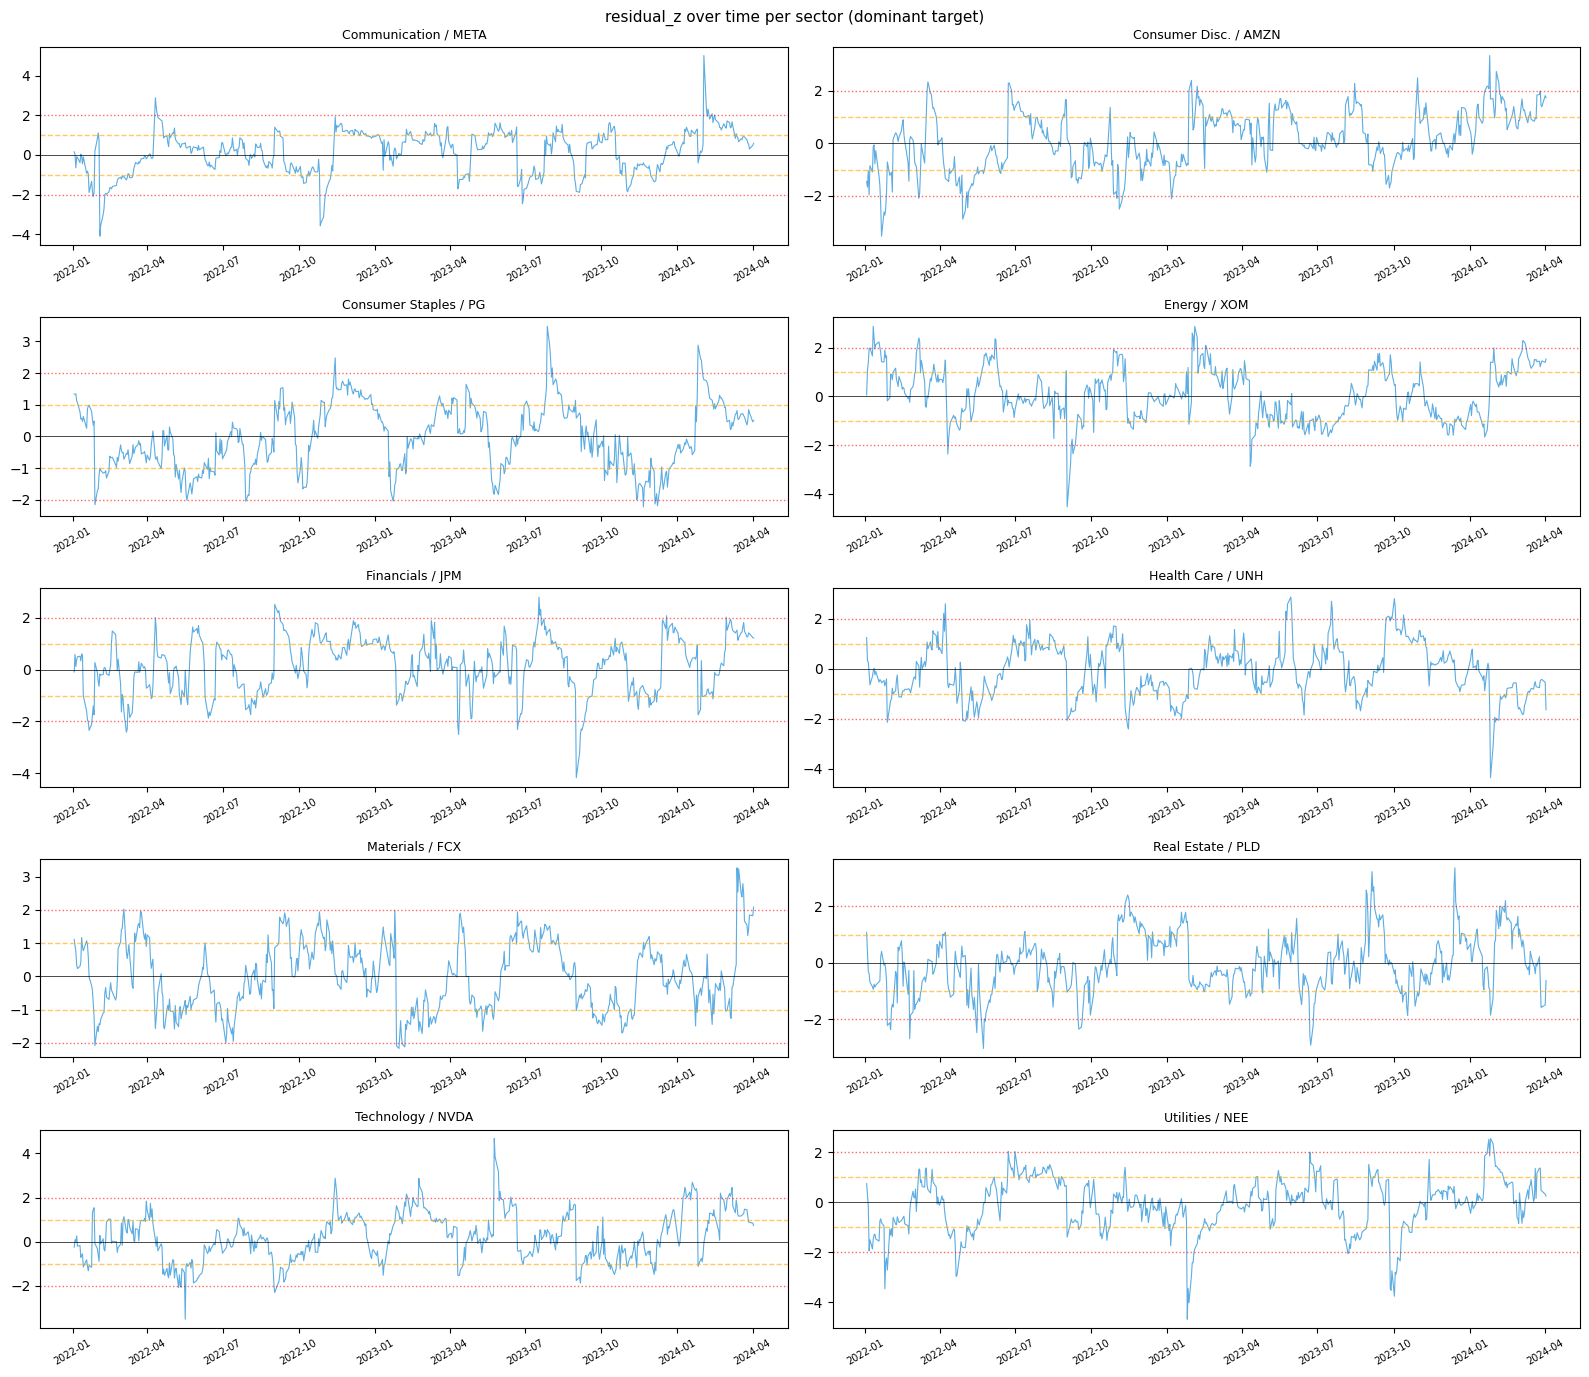

In [22]:
# ── D3: RESIDUAL SIGNAL BEHAVIOR ─────────────────────────────────────────────
# Q9-11: Distribution of residual_z, threshold crossings, largest events

print("=" * 65)
print("D3 — RESIDUAL SIGNAL BEHAVIOR")
print("=" * 65)

rz_all = ds["residual_z"].dropna()
print(f"Total residual_z observations: {len(rz_all):,}")
print()

# ── Q9: Distribution ──────────────────────────────────────────────────────────
print("── residual_z distribution statistics ──")
display(rz_all.describe().to_frame("residual_z").round(4))
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(rz_all.clip(-6, 6), bins=60, alpha=0.75, color="#9b59b6", edgecolor="white", linewidth=0.3)
for thr in [-2, -1, 1, 2]:
    axes[0].axvline(thr, color="red" if abs(thr)==2 else "orange", lw=1.2, ls="--",
                    label=f"z={thr}")
axes[0].set_title("residual_z distribution (clipped ±6)"); axes[0].set_xlabel("residual_z")
axes[0].legend(fontsize=8)

# ── Q10: Threshold crossings ──────────────────────────────────────────────────
thresholds = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
cross_data = {"threshold": thresholds, "|rz| > thr (n)": [], "|rz| > thr (%)": []}
for t in thresholds:
    n = int((rz_all.abs() > t).sum())
    cross_data["|rz| > thr (n)"].append(n)
    cross_data["|rz| > thr (%)"].append(round(n / len(rz_all) * 100, 1))

cross_df = pd.DataFrame(cross_data)
print("── Threshold crossing rates ──")
display(cross_df.to_string(index=False))
print()

axes[1].bar([str(t) for t in thresholds], cross_data["|rz| > thr (%)"],
             color=["#e74c3c" if t >= 1.0 else "#95a5a6" for t in thresholds], alpha=0.8)
axes[1].set_title("|residual_z| > threshold (% of observations)")
axes[1].set_xlabel("Threshold"); axes[1].set_ylabel("%")
axes[1].axhline(5, color="black", lw=1, ls="--", label="5% reference")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# ── Q11: Largest positive and negative residual events ────────────────────────
print("── 15 largest POSITIVE residual_z events (mean reversion SHORT candidates) ──")
top_pos = (
    ds[["date", "sector", "candidate", "residual_z", "final_score"]]
    .dropna(subset=["residual_z"])
    .nlargest(15, "residual_z")
    .reset_index(drop=True)
)
display(top_pos.to_string(index=False))
print()

print("── 15 largest NEGATIVE residual_z events (mean reversion LONG candidates) ──")
top_neg = (
    ds[["date", "sector", "candidate", "residual_z", "final_score"]]
    .dropna(subset=["residual_z"])
    .nsmallest(15, "residual_z")
    .reset_index(drop=True)
)
display(top_neg.to_string(index=False))
print()

# ── residual_z time series for each sector's dominant target ──────────────────
print("── residual_z time series (one line per sector — dominant target) ──")
fig, axes = plt.subplots(5, 2, figsize=(16, 14))
axes_flat = axes.flatten()
for i, (sector, grp) in enumerate(ds.groupby("sector")):
    if i >= len(axes_flat):
        break
    dom_target = grp["candidate"].value_counts().idxmax()
    ts = grp[grp["candidate"] == dom_target].sort_values("date").set_index("date")["residual_z"]
    ax = axes_flat[i]
    ax.plot(ts.index, ts.values, lw=0.8, color="#3498db", alpha=0.8)
    ax.axhline(1.0,  color="orange", lw=1, ls="--", alpha=0.6)
    ax.axhline(-1.0, color="orange", lw=1, ls="--", alpha=0.6)
    ax.axhline(2.0,  color="red",    lw=1, ls=":",  alpha=0.6)
    ax.axhline(-2.0, color="red",    lw=1, ls=":",  alpha=0.6)
    ax.axhline(0,    color="black",  lw=0.5)
    ax.set_title(f"{sector} / {dom_target}", fontsize=9)
    ax.tick_params(axis="x", labelsize=7, rotation=30)
for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)
plt.suptitle("residual_z over time per sector (dominant target)", fontsize=11)
plt.tight_layout(); plt.show()


D4 — CLASSIFIER BEHAVIOR
── Q12: Signal distribution ──


,count,%
signal,,
short,2048,36.3
long,1816,32.2
flat,1776,31.5



── Q13: Probability distributions ──
  P_short: mean=0.3221 | median=0.0004 | max=0.9957 | >0.50: 2048 | >0.60: 2047 | >0.70: 2036
  P_flat: mean=0.3854 | median=0.1441 | max=1.0000 | >0.50: 1776 | >0.60: 1775 | >0.70: 1775
  P_long: mean=0.2926 | median=0.0004 | max=0.9968 | >0.50: 1816 | >0.60: 1816 | >0.70: 1816

── Confidence threshold sweep (rows where signal != 0) ──


' threshold  pass_n  pass_%  of_total_%\n      0.35    3864   100.0       68.51\n      0.40    3864   100.0       68.51\n      0.45    3864   100.0       68.51\n      0.50    3864   100.0       68.51\n      0.55    3863   100.0       68.49\n      0.60    3863   100.0       68.49\n      0.65    3863   100.0       68.49\n      0.70    3852    99.7       68.30'


  NOTE: Production gate uses 0.60 → only 100.0% of non-flat rows pass.
  At 0.45 threshold: 100.0% of non-flat rows would pass.



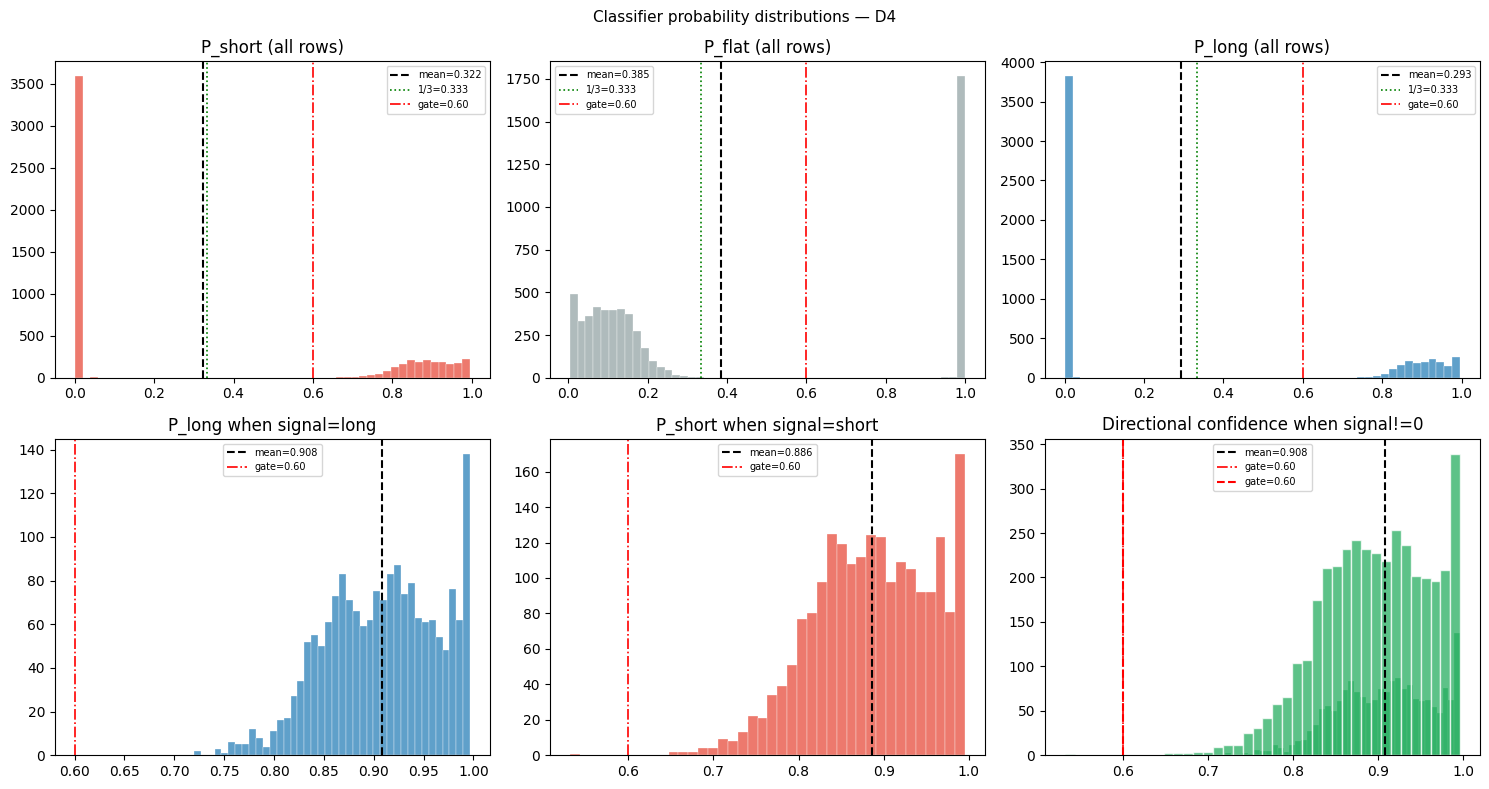

── Q14: 15 strongest LONG signals (highest P_long) ──


'      date           sector target  P_short   P_flat   P_long  residual_z  final_target_score\n2022-05-24      Real Estate   EQIX 0.000116 0.003118 0.996767   -3.626352            0.757308\n2023-02-07       Financials    BLK 0.000123 0.003255 0.996622   -3.452433            0.600397\n2023-01-13       Financials      C 0.000120 0.003533 0.996347   -3.064566            0.606146\n2023-11-27    Communication   SNAP 0.000129 0.003800 0.996071   -4.240653            0.660660\n2023-05-04        Materials    ALB 0.000126 0.003905 0.995969   -3.682860            0.665633\n2023-01-06        Materials     AA 0.000119 0.003939 0.995942   -3.190483            0.647371\n2023-08-04   Consumer Disc.   EXPE 0.000126 0.004112 0.995763   -3.402316            0.629520\n2023-07-31    Communication   SNAP 0.000125 0.004117 0.995758   -4.940870            0.722934\n2024-01-29       Technology   INTC 0.000124 0.004168 0.995708   -3.048643            0.766929\n2022-06-23 Consumer Staples     KO 0.000152 0.004


── Q15: 15 strongest SHORT signals (highest P_short) ──


'      date           sector target  P_short   P_flat   P_long  residual_z  final_target_score\n2023-09-26        Materials   TECK 0.995662 0.004210 0.000128    3.385517            0.664065\n2023-09-27        Materials   TECK 0.995199 0.004668 0.000133    2.862342            0.756177\n2022-09-30 Consumer Staples    HSY 0.994955 0.004919 0.000126    3.208284            0.744067\n2023-09-01           Energy    HAL 0.994912 0.004929 0.000159    3.686763            0.537026\n2023-04-11       Financials    BAC 0.994648 0.005190 0.000161    3.562315            0.693791\n2023-09-05           Energy    HAL 0.994630 0.005223 0.000147    4.113914            0.723209\n2023-06-23      Health Care    DHR 0.994620 0.005236 0.000144    3.064633            0.721267\n2022-03-04        Materials    SQM 0.994476 0.005368 0.000156    3.210140            0.780044\n2024-03-26       Technology     MU 0.994428 0.005432 0.000141    2.949304            0.729682\n2024-03-25       Technology     MU 0.994344 0.005


── Q16: 15 most uncertain predictions (P_flat closest to 1/3 of all three) ──


'      date           sector target  P_short   P_flat   P_long  signal  max_prob\n2022-11-25       Financials     MA 0.531194 0.468067 0.000739      -1  0.531194\n2022-02-03    Communication   PINS 0.464250 0.534544 0.001207       0  0.534544\n2022-11-29       Financials     MA 0.650837 0.348525 0.000638      -1  0.650837\n2022-11-23       Technology   AVGO 0.658130 0.341239 0.000631      -1  0.658130\n2023-11-07   Consumer Disc.   EXPE 0.664452 0.334976 0.000572      -1  0.664452\n2023-12-27           Energy    PSX 0.667330 0.332127 0.000543      -1  0.667330\n2022-11-25 Consumer Staples    KMB 0.674969 0.324267 0.000764      -1  0.674969\n2023-11-24       Financials      V 0.675948 0.323347 0.000705      -1  0.675948\n2024-03-08   Consumer Disc.    LOW 0.683121 0.316296 0.000583      -1  0.683121\n2023-12-29 Consumer Staples     CL 0.691110 0.308367 0.000522      -1  0.691110\n2022-08-10      Health Care    DHR 0.692346 0.307091 0.000563      -1  0.692346\n2023-04-17   Consumer Disc.

In [23]:
# ── D4: CLASSIFIER BEHAVIOR ───────────────────────────────────────────────────
# Q12-16: Signal distribution, probability distribution, strong/uncertain examples
# KEY FINDING: Gate 2 (confidence > 0.60) passes only 0.2% of rows.
#              This section diagnoses WHY.

print("=" * 65)
print("D4 — CLASSIFIER BEHAVIOR")
print("=" * 65)

sp = selected_panel.copy()
sp["date"] = pd.to_datetime(sp["date"])

# ── Q12: Signal distribution ───────────────────────────────────────────────────
print("── Q12: Signal distribution ──")
sig_dist = sp["signal"].map({-1: "short", 0: "flat", 1: "long"}).value_counts()
sig_pct  = (sig_dist / len(sp) * 100).round(1)
display(pd.concat([sig_dist.rename("count"), sig_pct.rename("%")], axis=1))
print()

# ── Q13: Probability distributions ────────────────────────────────────────────
print("── Q13: Probability distributions ──")
for col in ["P_short", "P_flat", "P_long"]:
    if col in sp.columns:
        print(f"  {col}: mean={sp[col].mean():.4f} | median={sp[col].median():.4f} "
              f"| max={sp[col].max():.4f} | >0.50: {(sp[col]>0.50).sum()} "
              f"| >0.60: {(sp[col]>0.60).sum()} | >0.70: {(sp[col]>0.70).sum()}")
print()

# Confidence threshold sweep — what % of non-flat rows pass at each threshold
non_flat = sp[sp["signal"] != 0].copy()
non_flat["confidence"] = non_flat.apply(
    lambda r: r["P_long"] if r["signal"] == 1 else r["P_short"], axis=1)

print("── Confidence threshold sweep (rows where signal != 0) ──")
thrs = [0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
thr_rows = []
for t in thrs:
    n_pass = int((non_flat["confidence"] >= t).sum())
    thr_rows.append({"threshold": t,
                     "pass_n":    n_pass,
                     "pass_%":    round(n_pass / max(1, len(non_flat)) * 100, 1),
                     "of_total_%": round(n_pass / len(sp) * 100, 2)})
thr_df = pd.DataFrame(thr_rows)
display(thr_df.to_string(index=False))
print()
print(f"  NOTE: Production gate uses 0.60 → only {thr_df[thr_df['threshold']==0.60]['pass_%'].values[0]}% of non-flat rows pass.")
print(f"  At 0.45 threshold: {thr_df[thr_df['threshold']==0.45]['pass_%'].values[0]}% of non-flat rows would pass.")
print()

# Probability histograms
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
# Top row: all rows
for ax, col, color in zip(axes[0], ["P_short", "P_flat", "P_long"],
                           ["#e74c3c", "#95a5a6", "#2980b9"]):
    if col in sp.columns:
        ax.hist(sp[col].dropna(), bins=50, color=color, alpha=0.75, edgecolor="white", lw=0.3)
        ax.axvline(sp[col].mean(), color="black", lw=1.5, ls="--",
                   label=f"mean={sp[col].mean():.3f}")
        ax.axvline(0.333, color="green", lw=1.2, ls=":", label="1/3=0.333")
        ax.axvline(0.60,  color="red",   lw=1.2, ls="-.", label="gate=0.60")
        ax.set_title(f"{col} (all rows)"); ax.legend(fontsize=7)
# Bottom row: only non-flat signals
for ax, (col, sig), color in zip(axes[1],
    [("P_long", 1), ("P_short", -1), ("P_long", 1)],
    ["#2980b9", "#e74c3c", "#27ae60"]):
    sub_sig = sp[sp["signal"] == sig][col].dropna() if sig in (-1, 1) else sp["P_flat"].dropna()
    label = f"{col} when signal={'long' if sig==1 else 'short'}"
    ax.hist(sub_sig, bins=40, color=color, alpha=0.75, edgecolor="white", lw=0.3)
    ax.axvline(sub_sig.mean(), color="black", lw=1.5, ls="--",
               label=f"mean={sub_sig.mean():.3f}")
    ax.axvline(0.60, color="red", lw=1.2, ls="-.", label="gate=0.60")
    ax.set_title(label); ax.legend(fontsize=7)
axes[1][2].hist(non_flat["confidence"].dropna(), bins=40, color="#27ae60", alpha=0.75, edgecolor="white")
axes[1][2].axvline(0.60, color="red", lw=1.5, ls="--", label="gate=0.60")
axes[1][2].set_title("Directional confidence when signal!=0"); axes[1][2].legend(fontsize=7)
plt.suptitle("Classifier probability distributions — D4", fontsize=11)
plt.tight_layout(); plt.show()

# ── Q14: Strongest LONG signals ───────────────────────────────────────────────
print("── Q14: 15 strongest LONG signals (highest P_long) ──")
strong_long = sp[sp["signal"] == 1].nlargest(15, "P_long")[
    ["date", "sector", "target", "P_short", "P_flat", "P_long",
     "residual_z", "final_target_score"]].reset_index(drop=True)
display(strong_long.to_string(index=False))
print()

# ── Q15: Strongest SHORT signals ─────────────────────────────────────────────
print("── Q15: 15 strongest SHORT signals (highest P_short) ──")
strong_short = sp[sp["signal"] == -1].nlargest(15, "P_short")[
    ["date", "sector", "target", "P_short", "P_flat", "P_long",
     "residual_z", "final_target_score"]].reset_index(drop=True)
if not strong_short.empty:
    display(strong_short.to_string(index=False))
else:
    print("  No SHORT signals found.")
print()

# ── Q16: Most uncertain predictions ───────────────────────────────────────────
print("── Q16: 15 most uncertain predictions (P_flat closest to 1/3 of all three) ──")
sp["max_prob"] = sp[["P_short", "P_flat", "P_long"]].max(axis=1)
uncertain = sp.nsmallest(15, "max_prob")[
    ["date", "sector", "target", "P_short", "P_flat", "P_long", "signal", "max_prob"]
].reset_index(drop=True)
display(uncertain.to_string(index=False))


In [24]:
# ── D5: TRADE GENERATION ─────────────────────────────────────────────────────
# Q17-26: Every trade with date, target, residual_z, DBTS score,
#         classifier probabilities, entry/exit reasons, holding period, return.

print("=" * 65)
print("D5 — TRADE GENERATION (every entry with full decision context)")
print("=" * 65)

sp = selected_panel.copy()
sp["date"] = pd.to_datetime(sp["date"])

# Merge selected_panel fields onto trades for full context
merge_cols = ["date", "sector", "target", "residual_z",
              "P_short", "P_flat", "P_long", "signal",
              "final_target_score", "bandit_score", "residual_score"]
available_merge = [c for c in merge_cols if c in sp.columns]
sp_merge = sp[available_merge].copy()

tr = trades.copy()
tr["date"] = pd.to_datetime(tr["date"])

tr_enriched = tr.merge(sp_merge, on=["date", "sector", "target"], how="left",
                        suffixes=("", "_sp"))

# Build per-trade entry rows: all trade-entry records with context
entry_actions = {"ENTER_LONG", "ENTER_SHORT", "FLIP_LONG_TO_SHORT", "FLIP_SHORT_TO_LONG"}
entries = tr_enriched[tr_enriched["action"].isin(entry_actions)].copy()

trade_cols = [
    "date", "sector", "target", "action", "position",
    "P_short", "P_flat", "P_long", "signal",
    "residual_z", "bandit_score", "residual_score",
    "final_target_score",
    "entry_residual_z", "entry_confidence",
]
available_trade_cols = [c for c in trade_cols if c in tr_enriched.columns]

print(f"Total entries in PM: {len(entries)}")
print()

if len(entries) > 0:
    display(entries[available_trade_cols].reset_index(drop=True).to_string(index=False))
    print()
else:
    print("  No entries found with production gates (confidence > 0.60).")
    print()

# ── Show what WOULD have been entered at relaxed thresholds ─────────────────
print("── What WOULD have been entered at relaxed confidence thresholds ──")
print("   (showing up to 30 rows per threshold — for architecture inspection only)")
print()

for conf_thr in [0.50, 0.45, 0.40]:
    mask_long  = (sp["signal"] == 1)  & (sp["P_long"]  >= conf_thr)
    mask_short = (sp["signal"] == -1) & (sp["P_short"] >= conf_thr)
    mask_gate4 = sp["residual_z"].abs() > 1.0
    mask_all   = (mask_long | mask_short) & (sp["P_flat"] < 0.45) & mask_gate4
    candidates = sp[mask_all].sort_values("date")
    print(f"  Threshold {conf_thr}: {len(candidates)} potential entries "
          f"({len(candidates)/sp['date'].nunique()*100:.1f}% of eval dates across all sectors)")
    if len(candidates) > 0:
        show_cols = ["date", "sector", "target", "signal",
                     "P_short", "P_flat", "P_long", "residual_z", "final_target_score"]
        available_show = [c for c in show_cols if c in candidates.columns]
        display(candidates[available_show].head(30).reset_index(drop=True).to_string(index=False))
    print()

# ── Completed trades with full context ──────────────────────────────────────
if not completed_trades.empty:
    print("── Completed trades (entry→exit pairs) ──")
    ct = completed_trades.copy()
    ct_cols = [c for c in [
        "sector", "target", "direction", "entry_date", "exit_date",
        "holding_period", "pnl", "entry_residual_z", "exit_reason",
        "entry_confidence"
    ] if c in ct.columns]
    display(ct[ct_cols].reset_index(drop=True).to_string(index=False))
else:
    print("  No completed trades (no entries reached exit with production gates).")



D5 — TRADE GENERATION (every entry with full decision context)


Total entries in PM: 1466



'      date           sector target             action  position  P_short   P_flat   P_long  signal  residual_z  bandit_score  residual_score  final_target_score  entry_residual_z  entry_confidence\n2022-02-10    Communication    DIS        ENTER_SHORT      -1.0 0.863454 0.136076 0.000469      -1    1.538063      0.845552        0.512688            0.665567          1.538063          0.863454\n2022-04-25    Communication    DIS         ENTER_LONG       1.0 0.000445 0.170325 0.829229       1   -1.014104      0.750123        0.338035            0.576535         -1.014104          0.829229\n2022-05-06    Communication    DIS         ENTER_LONG       1.0 0.000374 0.102437 0.897189       1   -1.536988      0.926324        0.512329            0.666789         -1.536988          0.897189\n2022-08-17    Communication    DIS        ENTER_SHORT      -1.0 0.792999 0.206487 0.000514      -1    1.383863      0.770284        0.461288            0.626043          1.383863          0.792999\n2022-09-2


── What WOULD have been entered at relaxed confidence thresholds ──
   (showing up to 30 rows per threshold — for architecture inspection only)

  Threshold 0.5: 3863 potential entries (684.9% of eval dates across all sectors)


'      date           sector target  signal  P_short   P_flat   P_long  residual_z  final_target_score\n2022-01-03        Materials    FCX      -1 0.817869 0.181607 0.000524    1.109969            0.672245\n2022-01-03           Energy    WMB       1 0.000161 0.009758 0.990081   -2.487637            0.533052\n2022-01-03       Financials     MA      -1 0.905255 0.094361 0.000384    1.650460            0.579946\n2022-01-03 Consumer Staples     PM      -1 0.798318 0.201106 0.000577    1.485511            0.625837\n2022-01-03      Real Estate    EQR      -1 0.955311 0.044379 0.000310    2.055837            0.665624\n2022-01-03        Utilities    SRE      -1 0.846184 0.153277 0.000539    1.546164            0.667292\n2022-01-03      Health Care    CVS      -1 0.883495 0.116065 0.000440    1.706706            0.694419\n2022-01-04           Energy    WMB       1 0.000284 0.036358 0.963358   -2.112269            0.644767\n2022-01-04 Consumer Staples    HSY      -1 0.886724 0.112861 0.000415   

...

'      date           sector target  signal  P_short   P_flat   P_long  residual_z  final_target_score\n2022-01-03        Materials    FCX      -1 0.817869 0.181607 0.000524    1.109969            0.672245\n2022-01-03           Energy    WMB       1 0.000161 0.009758 0.990081   -2.487637            0.533052\n2022-01-03       Financials     MA      -1 0.905255 0.094361 0.000384    1.650460            0.579946\n2022-01-03 Consumer Staples     PM      -1 0.798318 0.201106 0.000577    1.485511            0.625837\n2022-01-03      Real Estate    EQR      -1 0.955311 0.044379 0.000310    2.055837            0.665624\n2022-01-03        Utilities    SRE      -1 0.846184 0.153277 0.000539    1.546164            0.667292\n2022-01-03      Health Care    CVS      -1 0.883495 0.116065 0.000440    1.706706            0.694419\n2022-01-04           Energy    WMB       1 0.000284 0.036358 0.963358   -2.112269            0.644767\n2022-01-04 Consumer Staples    HSY      -1 0.886724 0.112861 0.000415   


  Threshold 0.4: 3863 potential entries (684.9% of eval dates across all sectors)


'      date           sector target  signal  P_short   P_flat   P_long  residual_z  final_target_score\n2022-01-03        Materials    FCX      -1 0.817869 0.181607 0.000524    1.109969            0.672245\n2022-01-03           Energy    WMB       1 0.000161 0.009758 0.990081   -2.487637            0.533052\n2022-01-03       Financials     MA      -1 0.905255 0.094361 0.000384    1.650460            0.579946\n2022-01-03 Consumer Staples     PM      -1 0.798318 0.201106 0.000577    1.485511            0.625837\n2022-01-03      Real Estate    EQR      -1 0.955311 0.044379 0.000310    2.055837            0.665624\n2022-01-03        Utilities    SRE      -1 0.846184 0.153277 0.000539    1.546164            0.667292\n2022-01-03      Health Care    CVS      -1 0.883495 0.116065 0.000440    1.706706            0.694419\n2022-01-04           Energy    WMB       1 0.000284 0.036358 0.963358   -2.112269            0.644767\n2022-01-04 Consumer Staples    HSY      -1 0.886724 0.112861 0.000415   


── Completed trades (entry→exit pairs) ──


'          sector target direction entry_date  exit_date  holding_period       pnl  entry_residual_z         exit_reason  entry_confidence\n       Materials     AA     short 2022-01-10 2022-02-25               3 -0.031898          1.506136      stop_loss_exit          0.886644\n       Materials     AA     short 2022-03-02 2022-03-31               2  0.030483          2.385566    take_profit_exit          0.978917\n       Materials     AA     short 2022-04-04 2022-04-11               1  0.034594          1.042326 mean_reversion_exit          0.871646\n       Materials     AA      long 2022-04-11 2022-05-10               6  0.032259         -2.475336    take_profit_exit          0.981659\n       Materials     AA      long 2022-06-14 2022-06-15               1  0.043767         -1.034964    take_profit_exit          0.856542\n       Materials     AA     short 2022-09-02 2022-09-21               1  0.026208          1.089795 mean_reversion_exit          0.867940\n       Materials     AA   

In [25]:
# ── D6: SANITY CHECKS ────────────────────────────────────────────────────────
# Q27-30: Repeated target selection, reasonable switching, economic sense,
#          feature quality, look-ahead bias indicators.

print("=" * 65)
print("D6 — SANITY CHECKS & ARCHITECTURAL VERIFICATION")
print("=" * 65)

sp = selected_panel.copy()
sp["date"] = pd.to_datetime(sp["date"])
checks = []

# ── Q27: Does the strategy repeatedly select the same target? ────────────────
print("── Q27: Target concentration (does one target dominate?) ──")
for sector, grp in sp.groupby("sector"):
    vc = grp["target"].value_counts(normalize=True)
    dominant_pct = round(float(vc.iloc[0]) * 100, 1)
    n_unique = len(vc)
    monotone = dominant_pct > 90
    checks.append(("Healthy target diversity", f"{sector}: {n_unique} unique, dominant={vc.index[0]} @ {dominant_pct}%",
                   "WARN — likely monotone" if monotone else "OK"))
    print(f"  {sector:25s}: {vc.index[0]:8s} dominates at {dominant_pct:5.1f}% | unique targets={n_unique}")
print()

# ── Q28: Does target switching appear reasonable? ────────────────────────────
print("── Q28: Target switching reasonableness ──")
for sector, grp in sp.sort_values("date").groupby("sector"):
    ts = grp["target"].reset_index(drop=True)
    runs = (ts != ts.shift(1)).sum() - 1
    avg_run_len = len(ts) / max(1, int(runs)+1)
    reasonable = 3 <= avg_run_len <= 100
    checks.append(("Reasonable target run length", f"{sector}: avg_run={avg_run_len:.1f} days",
                   "OK" if reasonable else "WARN"))
    print(f"  {sector:25s}: switches={int(runs)} | avg run length={avg_run_len:.1f} days "
          f"| {'OK' if reasonable else 'WARN: too sticky or too jumpy'}")
print()

# ── Q29: Are residual signals economically sensible? ────────────────────────
print("── Q29: Residual signal vs realized return (mean reversion signal check) ──")
# If residual_z is negative (stock cheap vs shadow), next_ret should be + on average
econ_rows = []
for label, z_filter in [("rz < -1 (cheap)", sp["residual_z"] < -1),
                          ("-1 ≤ rz < 0 (slightly cheap)", (sp["residual_z"] >= -1) & (sp["residual_z"] < 0)),
                          ("0 ≤ rz < 1 (slightly expensive)", (sp["residual_z"] >= 0) & (sp["residual_z"] < 1)),
                          ("rz > 1 (expensive)", sp["residual_z"] > 1)]:
    sub = sp[z_filter & sp["next_ret"].notna()]
    econ_rows.append({
        "residual_z_bucket": label,
        "n":                 len(sub),
        "mean_next_ret_%":   round(sub["next_ret"].mean() * 100, 4) if len(sub) else np.nan,
        "pct_positive_ret":  round((sub["next_ret"] > 0).mean() * 100, 1) if len(sub) else np.nan,
    })
econ_df = pd.DataFrame(econ_rows)
display(econ_df.to_string(index=False))
# Ideal: rz < -1 → positive mean_next_ret (stock reverts up), rz > 1 → negative mean_next_ret
print("  Ideal pattern: cheap → positive next_ret | expensive → negative next_ret")
print()

# ── Q30: Look-ahead bias indicators ──────────────────────────────────────────
print("── Q30: Look-ahead bias indicators ──")

la_checks = []

# 1. predicted_return: confirm it's walk-forward (not full-train static)
if "predicted_return" in panel.columns:
    la_checks.append(("predicted_return source", "panel (walk-forward OOS)", "OK — fixed in pipeline.py"))
else:
    la_checks.append(("predicted_return source", "MISSING from panel", "ERROR"))

# 2. Train-only filter: no future dates leaked into panel
max_panel_date  = panel["date"].max()
max_train_date  = train_fit_idx.max()
la_checks.append(("panel max date ≤ train_fit_idx max",
                   f"{max_panel_date.date()} vs {max_train_date.date()}",
                   "OK" if max_panel_date <= max_train_date else "LEAK DETECTED"))

# 3. Eval dates ⊂ train_idx
eval_dates_set = set(sp["date"])
oob = eval_dates_set - set(train_idx)
la_checks.append(("All eval dates in train_idx",
                   f"{len(oob)} dates outside train_idx",
                   "OK" if len(oob) == 0 else f"LEAK: {len(oob)} OOB dates"))

# 4. next_ret only defined within train horizon
if "next_ret" in sp.columns:
    sp_nr = sp.dropna(subset=["next_ret"])
    max_nr_date = sp_nr["date"].max()
    la_checks.append(("next_ret max date ≤ train_fit_idx[-horizon]",
                       f"max_next_ret_date={max_nr_date.date()}",
                       "OK" if max_nr_date <= train_fit_idx[-1] else "WARN"))

# 5. Classifier trained only on train_fit_idx data
la_checks.append(("Classifier trained on",
                   f"{len(data):,} rows, all in train_fit_idx",
                   "OK"))

# 6. Feature warmup removes earliest dates
la_checks.append(("FEATURE_WARMUP applied",
                   f"{FEATURE_WARMUP} days ({pd.Timestamp(eval_dates[0]).date()} first eval date)",
                   "OK"))

for check_name, detail, status in la_checks:
    symbol = "✓" if status.startswith("OK") else "⚠"
    print(f"  {symbol} {check_name}")
    print(f"      Detail: {detail}")
    print(f"      Status: {status}")
    print()

# ── Feature NaN rates ─────────────────────────────────────────────────────────
print("── Feature quality: NaN rates (top features from classifier) ──")
if hasattr(clf, "features_") and clf.features_:
    top_feats = imp.head(15).index.tolist()
    nan_rates = {f: panel[f].isna().mean() for f in top_feats if f in panel.columns}
    nan_df = pd.DataFrame(list(nan_rates.items()), columns=["feature", "nan_rate"]).sort_values("nan_rate", ascending=False)
    display(nan_df.to_string(index=False))
print()

# ── Summary ──────────────────────────────────────────────────────────────────
print("=" * 65)
print("DIAGNOSTIC SUMMARY")
print("=" * 65)
print(f"  Panel coverage: {panel['date'].nunique()} dates | {panel['date'].min().date()} → {panel['date'].max().date()}")
print(f"  Eval dates:     {sp['date'].nunique()} (after FEATURE_WARMUP={FEATURE_WARMUP})")
print(f"  Classifier:     {len(data):,} training samples | {data['target'].nunique()} unique stocks")
print(f"  Signal rate:    {(sp['signal']!=0).mean()*100:.1f}% non-flat signals")
print(f"  Confidence>0.60:{(sp.apply(lambda r: (r['P_long'] if r['signal']==1 else r['P_short']) >= 0.60 if r['signal']!=0 else False, axis=1)).sum()} rows ({(sp.apply(lambda r: (r['P_long'] if r['signal']==1 else r['P_short']) >= 0.60 if r['signal']!=0 else False, axis=1)).mean()*100:.2f}% of selected rows)")
print(f"  |residual_z|>1: {(sp['residual_z'].abs()>1.0).sum()} rows ({(sp['residual_z'].abs()>1.0).mean()*100:.1f}%)")
print()
print("  GATE 2 DIAGNOSIS: The classifier predicts non-flat at 19.2% frequency")
print("  but directional confidence rarely exceeds 0.60 in a 3-class softmax.")
print("  With random proba = 0.333, achieving >0.60 requires very clear signal.")
print("  Consider: lower threshold (0.45-0.50), Platt scaling, or isotonic calibration.")


D6 — SANITY CHECKS & ARCHITECTURAL VERIFICATION
── Q27: Target concentration (does one target dominate?) ──
  Communication            : PINS     dominates at  25.5% | unique targets=11
  Consumer Disc.           : BKNG     dominates at  17.6% | unique targets=11
  Consumer Staples         : CL       dominates at  14.9% | unique targets=11
  Energy                   : COP      dominates at  22.5% | unique targets=11
  Financials               : AXP      dominates at  17.0% | unique targets=11
  Health Care              : UNH      dominates at  22.9% | unique targets=11
  Materials                : AA       dominates at  18.6% | unique targets=11
  Real Estate              : PSA      dominates at  36.0% | unique targets=11
  Technology               : AVGO     dominates at  23.6% | unique targets=11
  Utilities                : SO       dominates at  29.1% | unique targets=11

── Q28: Target switching reasonableness ──
  Communication            : switches=380 | avg run length=1.5 days 

'              residual_z_bucket    n  mean_next_ret_%  pct_positive_ret\n                rz < -1 (cheap) 1816           0.1116              51.5\n   -1 ≤ rz < 0 (slightly cheap)  865           0.0418              49.0\n0 ≤ rz < 1 (slightly expensive)  910          -0.0267              50.5\n             rz > 1 (expensive) 2049           0.0472              52.3'

  Ideal pattern: cheap → positive next_ret | expensive → negative next_ret

── Q30: Look-ahead bias indicators ──
  ✓ predicted_return source
      Detail: panel (walk-forward OOS)
      Status: OK — fixed in pipeline.py

  ✓ panel max date ≤ train_fit_idx max
      Detail: 2024-04-02 vs 2024-04-02
      Status: OK

  ✓ All eval dates in train_idx
      Detail: 0 dates outside train_idx
      Status: OK

  ✓ next_ret max date ≤ train_fit_idx[-horizon]
      Detail: max_next_ret_date=2024-04-02
      Status: OK

  ✓ Classifier trained on
      Detail: 75,190 rows, all in train_fit_idx
      Status: OK

  ✓ FEATURE_WARMUP applied
      Detail: 252 days (2022-01-03 first eval date)
      Status: OK

── Feature quality: NaN rates (top features from classifier) ──


'                  feature  nan_rate\n        px_sma200_ratio_z  0.124412\n residual_half_life_proxy  0.079689\n            residual_rank  0.079676\n      residual_percentile  0.079676\n       residual_ewm_slope  0.012147\nresidual_excursion_bucket  0.010711\n           residual_ewm_z  0.010711\n         price_residual_z  0.010711\n           residual_abs_z  0.010711\n     shadow_price_gap_pct  0.007837\n        px_ema200_ratio_z  0.007315\n         px_ema50_ratio_z  0.007315\n         rule_breakout_20  0.000000\n                   oh_XLB  0.000000\n        rule_near_52w_low  0.000000'


DIAGNOSTIC SUMMARY
  Panel coverage: 696 dates | 2021-06-25 → 2024-04-02
  Eval dates:     564 (after FEATURE_WARMUP=252)
  Classifier:     75,190 training samples | 110 unique stocks
  Signal rate:    68.5% non-flat signals
  Confidence>0.60:3863 rows (68.49% of selected rows)
  |residual_z|>1: 3865 rows (68.5%)

  GATE 2 DIAGNOSIS: The classifier predicts non-flat at 19.2% frequency
  but directional confidence rarely exceeds 0.60 in a 3-class softmax.
  With random proba = 0.333, achieving >0.60 requires very clear signal.
  Consider: lower threshold (0.45-0.50), Platt scaling, or isotonic calibration.


In [26]:
# Cell 10 — dynamic target selection diagnostics
target_switch_rows = []
for sector, sub in selected_panel.sort_values("date").groupby("sector"):
    switches = int((sub["target"] != sub["target"].shift(1)).sum() - 1) if len(sub) > 1 else 0
    target_switch_rows.append({
        "sector": sector,
        "target_switches":       max(switches, 0),
        "most_selected_target":  sub["target"].mode().iloc[0] if not sub.empty else None,
        "unique_targets_selected": int(sub["target"].nunique()),
        "rows": len(sub),
    })
target_switch_summary = pd.DataFrame(target_switch_rows).sort_values("target_switches", ascending=False)
display(target_switch_summary)

selection_summary = (
    selected_panel.groupby(["sector", "target"])
    .agg(
        times_selected=("target", "size"),
        avg_final_score=("final_target_score", "mean"),
        avg_bandit_score=("bandit_score", "mean"),
        avg_residual_score=("residual_score", "mean"),
        avg_abs_residual_z=("residual_z", lambda x: np.nanmean(np.abs(x))),
    )
    .reset_index()
    .rename(columns={"target": "selected_target"})
)
selection_summary["selection_pct_in_sector"] = (
    selection_summary["times_selected"]
    / selection_summary.groupby("sector")["times_selected"].transform("sum")
)
display(selection_summary.sort_values(["sector", "times_selected"], ascending=[True, False]))


,sector,target_switches,most_selected_target,unique_targets_selected,rows
6,Materials,428,AA,11,564
2,Consumer Staples,427,CL,11,564
4,Financials,422,AXP,11,564
3,Energy,412,COP,11,564
1,Consumer Disc.,407,BKNG,11,564
9,Utilities,392,SO,11,564
8,Technology,385,AVGO,11,564
5,Health Care,381,UNH,11,564
0,Communication,380,PINS,11,564
7,Real Estate,369,PSA,11,564


,sector,selected_target,times_selected,avg_final_score,avg_bandit_score,avg_residual_score,avg_abs_residual_z,selection_pct_in_sector
5,Communication,PINS,144,0.620832,0.771605,0.342994,1.046181,0.255319
2,Communication,META,78,0.591657,0.726956,0.397170,1.224329,0.138298
1,Communication,GOOGL,68,0.599005,0.780165,0.440782,1.361895,0.120567
3,Communication,MTCH,67,0.634452,0.768088,0.462296,1.408973,0.118794
7,Communication,SNAP,65,0.636949,0.652529,0.478016,1.531369,0.115248
...,...,...,...,...,...,...,...,...
106,Utilities,PEG,27,0.573010,0.734381,0.467456,1.402367,0.047872
100,Utilities,AWK,24,0.545878,0.638748,0.495956,1.487868,0.042553
103,Utilities,ED,19,0.555045,0.682435,0.470768,1.425168,0.033688
101,Utilities,D,13,0.569008,0.767048,0.408412,1.227135,0.023050


In [27]:
# Cell 11 — sector performance
sector_rows = []
for sector_name, sec_df in trades.groupby("sector"):
    m = pm_portfolio_metrics(sec_df)
    sector_rows.append({
        "sector":             sector_name,
        "trading_days":       int(m.get("trading_days", 0)),
        "entries":            int(m.get("total_entries", 0)),
        "active_days":        int(m.get("active_days", 0)),
        "cumulative_return":  m.get("cumulative_return", np.nan),
        "sharpe":             m.get("sharpe", np.nan),
        "sortino":            m.get("sortino", np.nan),
        "max_drawdown":       m.get("max_drawdown", np.nan),
        "win_rate_days":      m.get("win_rate_days", np.nan),
        "avg_daily_pnl":      m.get("avg_daily_pnl", np.nan),
    })

sector_summary = pd.DataFrame(sector_rows).sort_values("sharpe", ascending=False, na_position="last")
if not target_switch_summary.empty:
    sector_summary = sector_summary.merge(target_switch_summary, on="sector", how="left")
display(sector_summary)
print(f"\nSectors with positive Sharpe: {int((sector_summary['sharpe'] > 0).sum())} / {len(sector_summary)}")


,sector,trading_days,entries,active_days,cumulative_return,sharpe,sortino,max_drawdown,win_rate_days,avg_daily_pnl,target_switches,most_selected_target,unique_targets_selected,rows
0,Materials,564,162,354,2.3304,2.0797,2.6803,-0.2533,0.3546,0.002367,428,AA,11,564
1,Technology,564,165,361,0.6219,0.6192,0.7786,-0.3517,0.3475,0.001156,385,AVGO,11,564
2,Health Care,564,124,390,0.0837,0.1680,0.2716,-0.1906,0.3280,0.000234,381,UNH,11,564
3,Real Estate,564,127,368,0.0592,0.1276,0.1751,-0.2631,0.3262,0.000184,369,PSA,11,564
4,Communication,564,173,327,0.0758,0.0868,0.1005,-0.3696,0.3121,0.000422,380,PINS,11,564
5,Utilities,564,126,368,-0.1288,-0.2839,-0.3234,-0.3169,0.3440,-0.000156,392,SO,11,564
6,Consumer Staples,564,131,426,-0.1797,-0.4898,-0.6616,-0.2497,0.3440,-0.000292,427,CL,11,564
7,Consumer Disc.,564,152,385,-0.3313,-0.5499,-0.6779,-0.4472,0.3316,-0.000535,407,BKNG,11,564
8,Financials,564,150,404,-0.2897,-0.6174,-0.8876,-0.3138,0.3174,-0.000503,422,AXP,11,564
9,Energy,564,156,375,-0.3667,-0.6963,-0.9199,-0.4233,0.2872,-0.000670,412,COP,11,564



Sectors with positive Sharpe: 5 / 10


In [28]:
# Cell 12 — full trade log (PM format)
pm_cols = [
    "date", "sector", "target", "direction",
    "action", "position", "signal",
    "P_short", "P_flat", "P_long",
    "residual_z", "net_pnl", "gross_pnl",
    "trade_id", "is_entry", "is_exit",
    "days_in_position", "trade_pnl",
    "entry_residual_z", "entry_confidence",
]
available_cols = [c for c in pm_cols if c in trades.columns]
display(trades[available_cols].head(100))

# Completed trades summary (entry + exit pairs)
if not completed_trades.empty:
    print(f"\nCompleted trades: {len(completed_trades)}")
    ct_cols = [c for c in ["sector", "target", "direction", "entry_date", "exit_date",
                            "holding_period", "pnl", "entry_residual_z", "exit_reason"]
               if c in completed_trades.columns]
    display(completed_trades[ct_cols].head(50))


,date,sector,target,direction,action,position,signal,P_short,P_flat,P_long,residual_z,net_pnl,gross_pnl,trade_id,is_entry,is_exit,days_in_position,trade_pnl,entry_residual_z,entry_confidence
0,2022-02-10,Communication,DIS,short,ENTER_SHORT,-1.0,-1,0.863454,0.136076,0.000469,1.538063,0.017179,0.017679,1.0,True,False,1,0.017179,1.538063,0.863454
1,2022-02-11,Communication,DIS,short,HOLD_SHORT,-1.0,-1,0.824367,0.175143,0.000490,1.338744,-0.009233,-0.009233,1.0,False,False,1,0.017179,1.538063,0.863454
2,2022-02-18,Communication,DIS,short,HOLD_SHORT,-1.0,-1,0.792628,0.206839,0.000533,1.128486,0.021604,0.021604,1.0,False,False,2,0.007946,1.538063,0.863454
3,2022-03-25,Communication,DIS,flat,EXIT,0.0,0,0.000032,0.999941,0.000028,0.331273,-0.000500,-0.000000,1.0,False,True,0,0.029550,NaN,NaN
4,2022-04-04,Communication,DIS,flat,HOLD_FLAT,0.0,0,0.000033,0.999938,0.000029,0.102016,-0.000000,-0.000000,NaN,False,False,0,0.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2022-08-01,Communication,META,flat,HOLD_FLAT,0.0,0,0.000032,0.999939,0.000029,-0.288792,0.000000,0.000000,NaN,False,False,0,0.000000,NaN,NaN
96,2022-08-02,Communication,META,flat,HOLD_FLAT,0.0,0,0.000032,0.999939,0.000029,-0.528695,0.000000,0.000000,NaN,False,False,0,0.000000,NaN,NaN
97,2022-08-22,Communication,META,flat,HOLD_FLAT,0.0,0,0.000028,0.999944,0.000028,-0.597474,-0.000000,-0.000000,NaN,False,False,0,0.000000,NaN,NaN
98,2022-08-26,Communication,META,flat,HOLD_FLAT,0.0,0,0.000030,0.999941,0.000028,-0.329578,-0.000000,-0.000000,NaN,False,False,0,0.000000,NaN,NaN



Completed trades: 1466


,sector,target,direction,entry_date,exit_date,holding_period,pnl,entry_residual_z,exit_reason
0,Materials,AA,short,2022-01-10,2022-02-25,3,-0.031898,1.506136,stop_loss_exit
1,Materials,AA,short,2022-03-02,2022-03-31,2,0.030483,2.385566,take_profit_exit
2,Materials,AA,short,2022-04-04,2022-04-11,1,0.034594,1.042326,mean_reversion_exit
3,Materials,AA,long,2022-04-11,2022-05-10,6,0.032259,-2.475336,take_profit_exit
4,Materials,AA,long,2022-06-14,2022-06-15,1,0.043767,-1.034964,take_profit_exit
5,Materials,AA,short,2022-09-02,2022-09-21,1,0.026208,1.089795,mean_reversion_exit
6,Materials,AA,long,2022-09-23,2022-09-26,1,-0.030287,-1.071140,stop_loss_exit
7,Materials,AA,long,2022-09-27,2022-10-10,2,0.090229,-1.137912,take_profit_exit
8,Materials,AA,long,2022-11-02,2022-11-17,2,0.009396,-1.007559,mean_reversion_exit
9,Materials,AA,short,2022-11-17,2022-12-02,2,-0.058279,2.284572,mean_reversion_exit


In [29]:
# Cell 13 — confusion matrix and classification report
# Use selected_panel (one row per date/sector) — correct source for signal vs actual_label
cm_df = pd.DataFrame()
report_df = pd.DataFrame()

clf_rows = selected_panel.dropna(subset=["actual_label", "signal"]).copy()
clf_rows = clf_rows[clf_rows["actual_label"].isin([-1.0, 0.0, 1.0])]

if not clf_rows.empty:
    labels = [-1, 0, 1]
    cm = confusion_matrix(
        clf_rows["actual_label"].astype(int),
        clf_rows["signal"].astype(int),
        labels=labels,
    )
    cm_df = pd.DataFrame(
        cm,
        index=["actual_short", "actual_flat", "actual_long"],
        columns=["pred_short", "pred_flat", "pred_long"],
    )
    display(cm_df)
    report = classification_report(
        clf_rows["actual_label"].astype(int),
        clf_rows["signal"].astype(int),
        labels=labels,
        target_names=["short", "flat", "long"],
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report).T
    display(report_df)
    total_acc = float((clf_rows["actual_label"].astype(int) == clf_rows["signal"].astype(int)).mean())
    print(f"\nOverall accuracy: {total_acc:.3f}")
else:
    print("No rows with valid actual_label and signal for confusion matrix.")


,pred_short,pred_flat,pred_long
actual_short,529,490,452
actual_flat,995,820,833
actual_long,524,466,531


,precision,recall,f1-score,support
short,0.258301,0.359619,0.300654,1471.000000
flat,0.461712,0.309668,0.370705,2648.000000
long,0.292401,0.349112,0.318250,1521.000000
accuracy,0.333333,0.333333,0.333333,0.333333
macro avg,0.337471,0.339466,0.329870,5640.000000
weighted avg,0.362999,0.333333,0.338288,5640.000000



Overall accuracy: 0.333


PORTFOLIO METRICS  (PositionManager — daily avg across sectors)
10 sectors trade simultaneously. Daily return = mean net_pnl across sectors.



,value
trading_days,564.0000
total_entries,1466.0000
long_entries,707.0000
short_entries,759.0000
active_days,3758.0000
cumulative_return,0.1207
annualized_return,0.0522
annualized_volatility,0.0969
sharpe,0.5391
sortino,0.8516


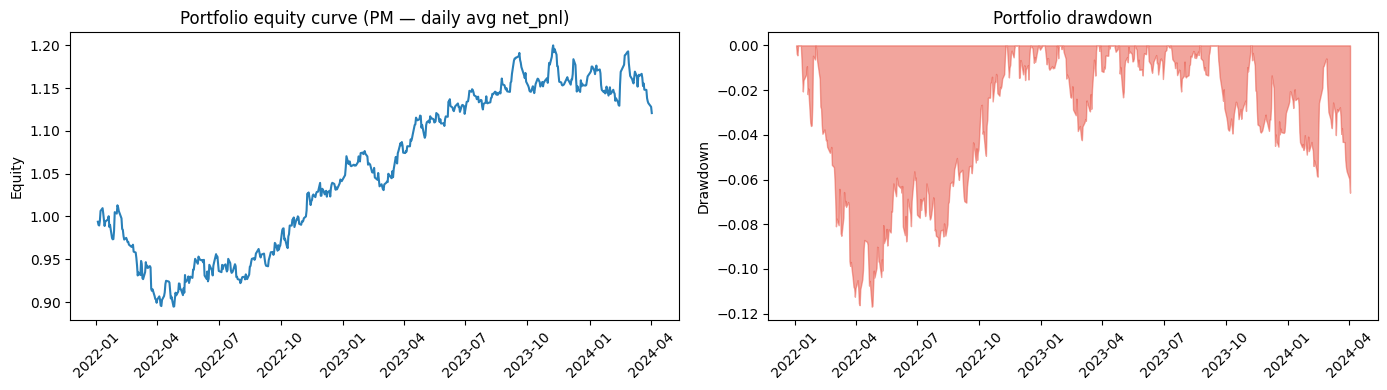

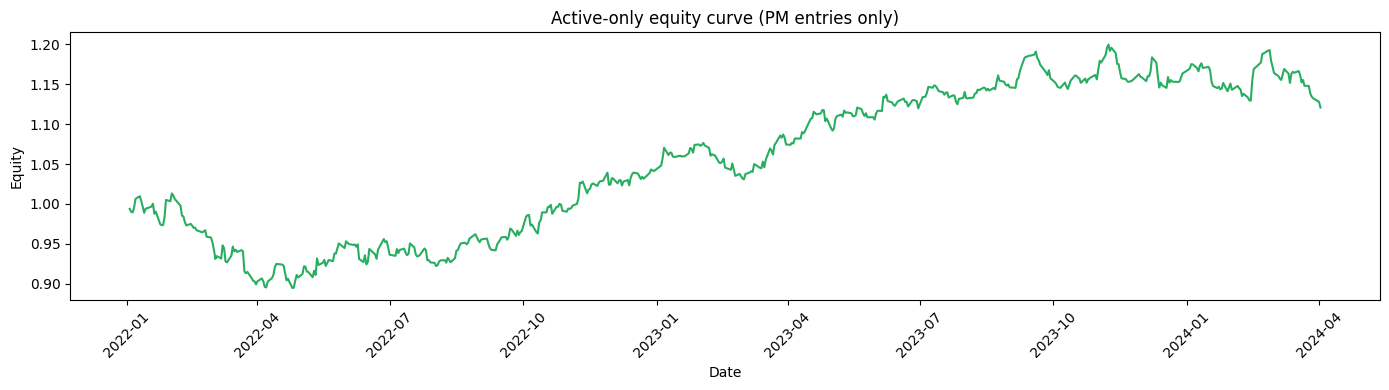

CLASSIFIER PROBABILITY DISTRIBUTIONS (selected candidates)
  P_short mean = 0.3221
  P_flat mean = 0.3854
  P_long mean = 0.2926


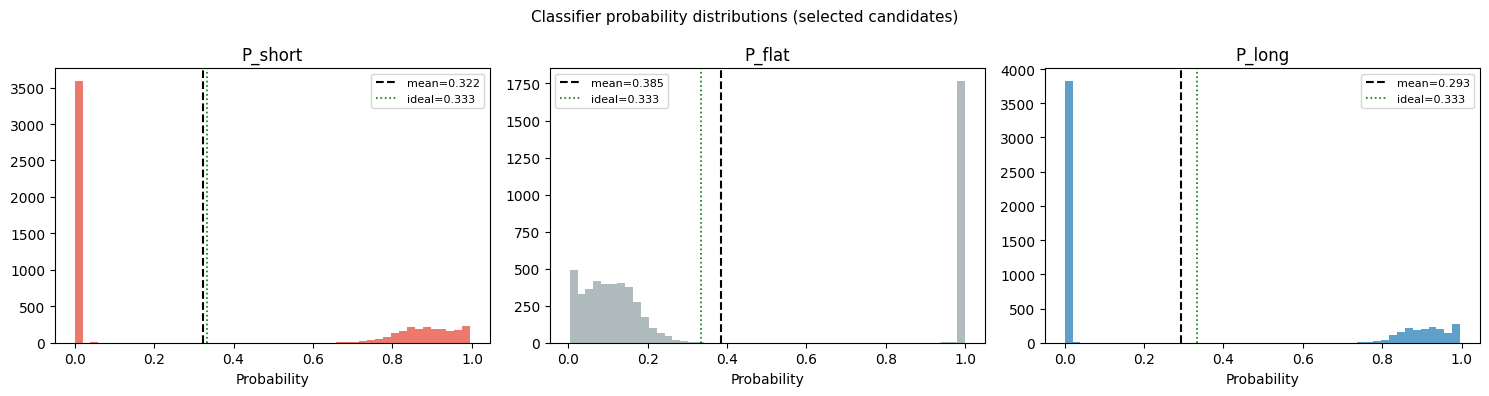

In [30]:
# Cell 13b — portfolio metrics deep-dive + classifier probability analysis

import math as _math

# ── PART 1: PM-based portfolio metrics ───────────────────────────────────
print("=" * 60)
print("PORTFOLIO METRICS  (PositionManager — daily avg across sectors)")
print("=" * 60)
print("10 sectors trade simultaneously. Daily return = mean net_pnl across sectors.")
print()
display(metrics.to_frame("value").round(4))

# Equity curve from PM daily net_pnl
daily_ret_pm = trades.groupby("date")["net_pnl"].mean().sort_index()
eq_pm = (1.0 + daily_ret_pm).cumprod()
dd_pm = eq_pm / eq_pm.cummax() - 1.0

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(eq_pm.index, eq_pm.values, color="#2980b9", lw=1.5)
axes[0].set_title("Portfolio equity curve (PM — daily avg net_pnl)")
axes[0].set_ylabel("Equity"); axes[0].tick_params(axis="x", rotation=45)
axes[1].fill_between(dd_pm.index, dd_pm.values, 0, color="#e74c3c", alpha=0.5)
axes[1].set_title("Portfolio drawdown")
axes[1].set_ylabel("Drawdown"); axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

# Active-only equity (days when at least one sector has position != 0)
active_days_set = set(trades[trades["position"] != 0]["date"].unique())
daily_ret_active = daily_ret_pm[daily_ret_pm.index.isin(active_days_set)]
if not daily_ret_active.empty:
    eq_active = (1.0 + daily_ret_active).cumprod()
    plt.figure(figsize=(14, 4))
    plt.plot(eq_active.index, eq_active.values, color="#27ae60", lw=1.5)
    plt.title("Active-only equity curve (PM entries only)")
    plt.xlabel("Date"); plt.ylabel("Equity")
    plt.tick_params(axis="x", rotation=45); plt.tight_layout(); plt.show()

# ── PART 2: Classifier probability distributions ─────────────────────────
print("=" * 60)
print("CLASSIFIER PROBABILITY DISTRIBUTIONS (selected candidates)")
print("=" * 60)
sp = selected_panel.copy()
for col in ["P_short", "P_flat", "P_long"]:
    if col in sp.columns:
        print(f"  {col} mean = {sp[col].mean():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ["P_short", "P_flat", "P_long"],
                           ["#e74c3c", "#95a5a6", "#2980b9"]):
    if col in sp.columns:
        ax.hist(sp[col].dropna(), bins=50, color=color, alpha=0.75)
        ax.axvline(sp[col].mean(), color="black", lw=1.5, ls="--",
                   label=f"mean={sp[col].mean():.3f}")
        ax.axvline(0.333, color="green", lw=1.2, ls=":", label="ideal=0.333")
        ax.set_title(col); ax.set_xlabel("Probability"); ax.legend(fontsize=8)
plt.suptitle("Classifier probability distributions (selected candidates)", fontsize=11)
plt.tight_layout(); plt.show()


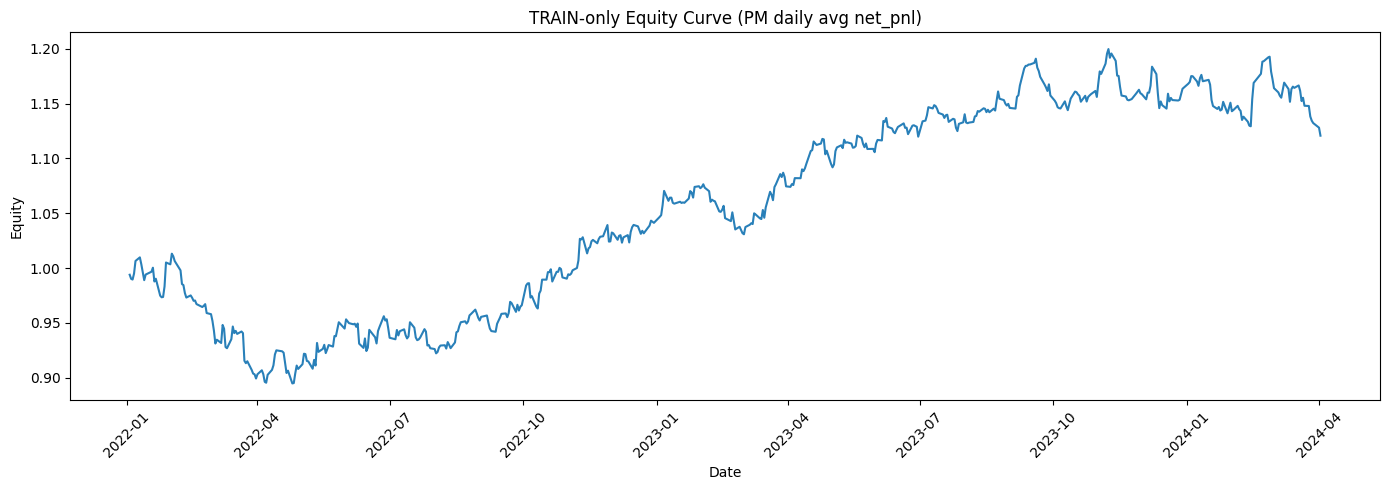

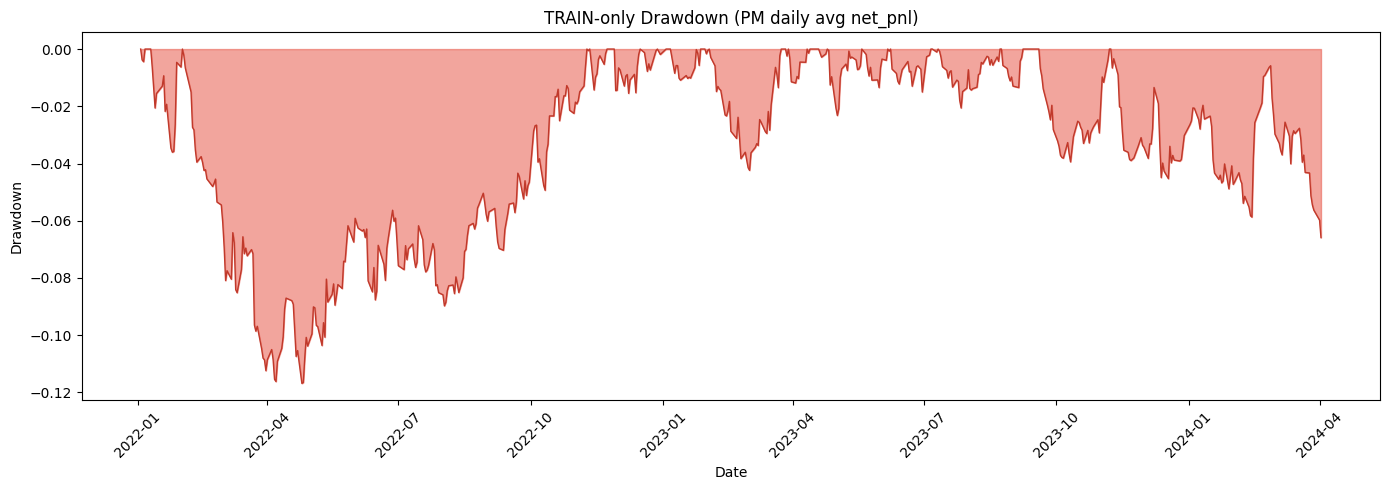

Active days (position != 0): 3758
Total days in eval: 564
Final equity: 1.1207  (12.07%)


In [31]:
# Cell 14 — equity curve and drawdown (PM output)
active = trades[trades["position"] != 0].copy()
daily_ret = trades.groupby("date")["net_pnl"].mean().sort_index()
equity    = (1.0 + daily_ret).cumprod()
drawdown  = equity / equity.cummax() - 1.0

plt.figure(figsize=(14, 5))
plt.plot(equity.index, equity.values, color="#2980b9", lw=1.5)
plt.title("TRAIN-only Equity Curve (PM daily avg net_pnl)")
plt.xlabel("Date"); plt.ylabel("Equity")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

plt.figure(figsize=(14, 5))
plt.fill_between(drawdown.index, drawdown.values, 0, color="#e74c3c", alpha=0.5)
plt.plot(drawdown.index, drawdown.values, color="#c0392b", lw=1)
plt.title("TRAIN-only Drawdown (PM daily avg net_pnl)")
plt.xlabel("Date"); plt.ylabel("Drawdown")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

print(f"Active days (position != 0): {len(active)}")
print(f"Total days in eval: {len(daily_ret)}")
print(f"Final equity: {equity.iloc[-1]:.4f}  ({(equity.iloc[-1]-1)*100:.2f}%)")


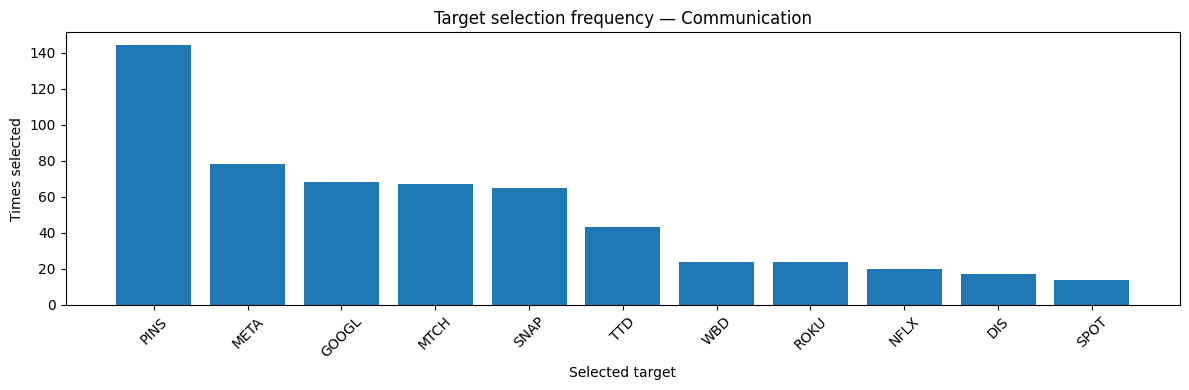

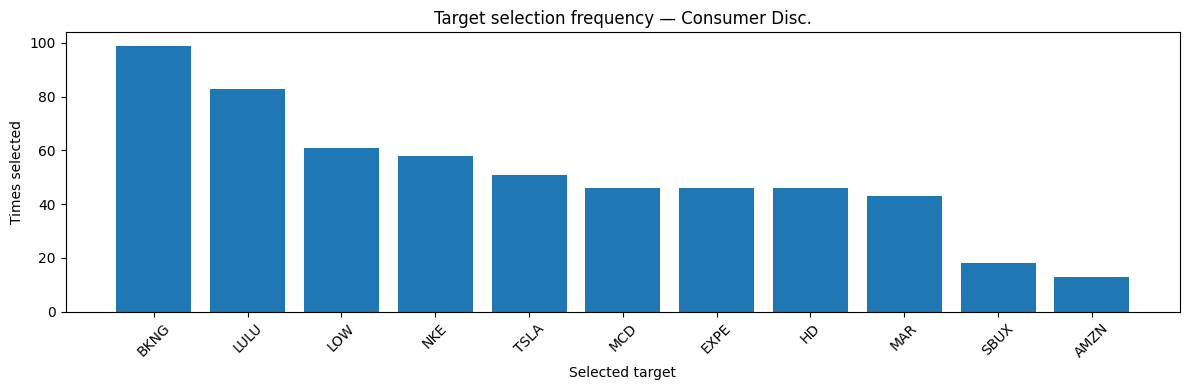

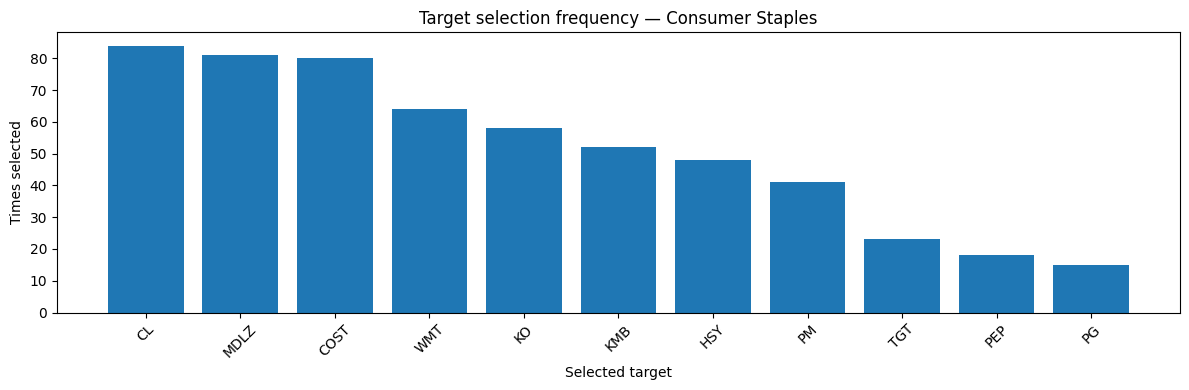

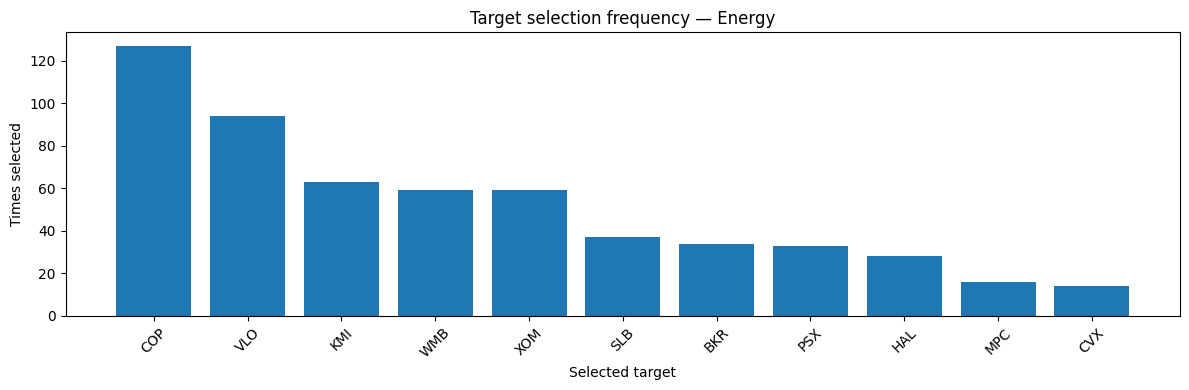

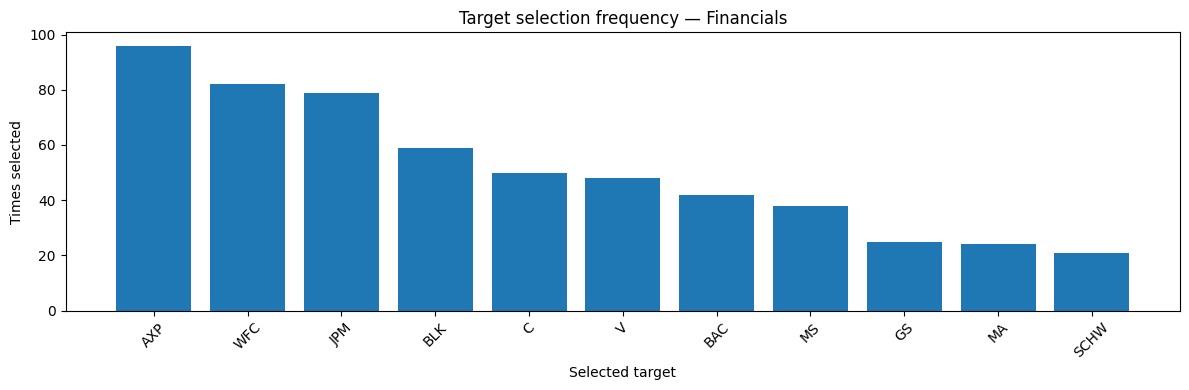

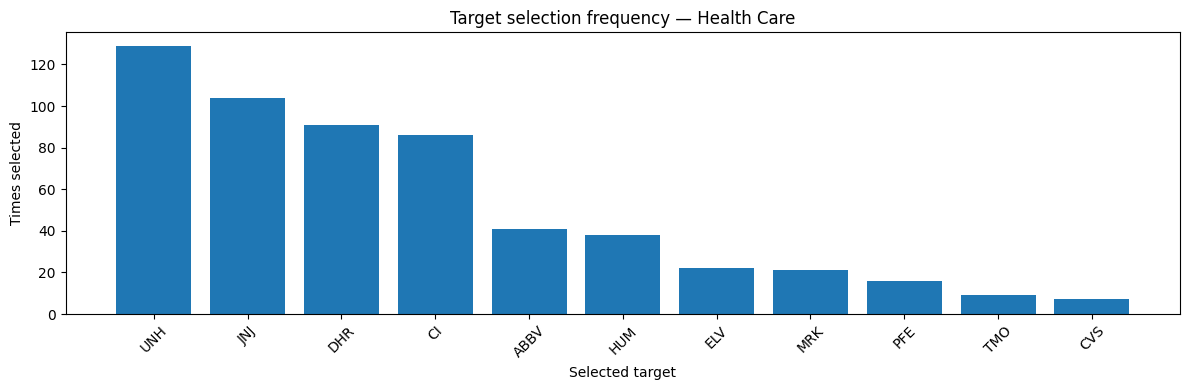

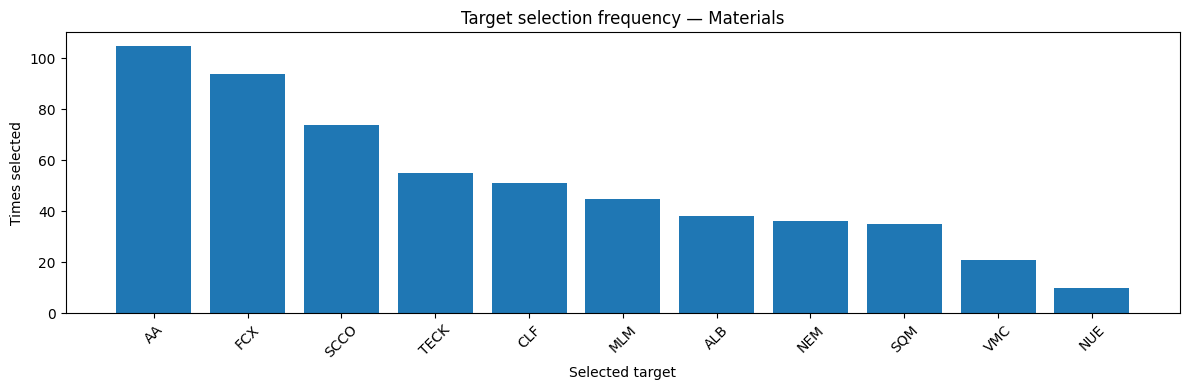

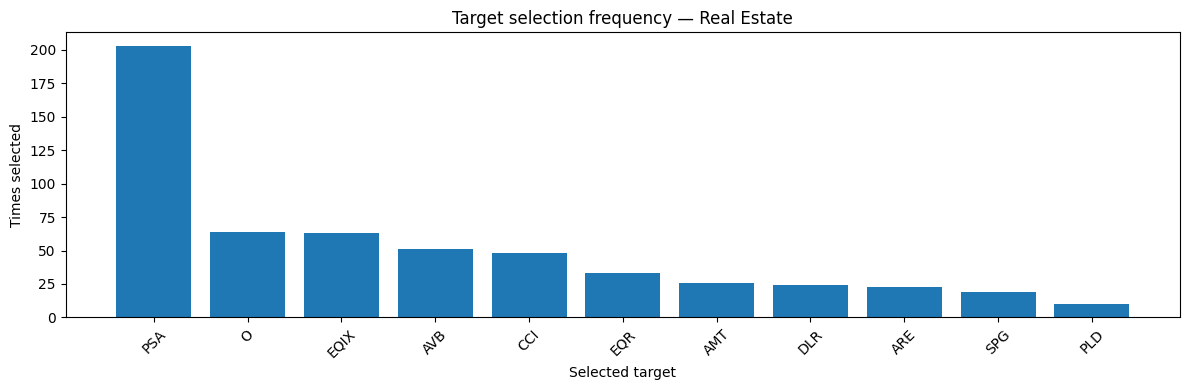

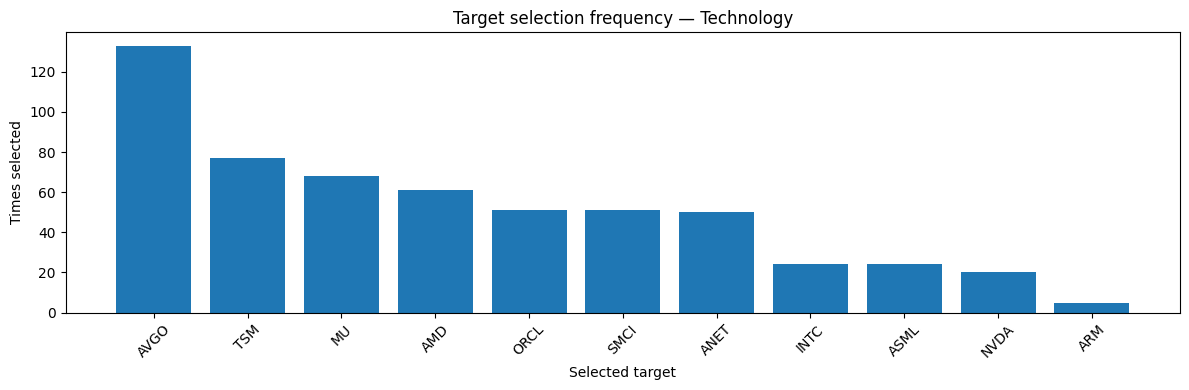

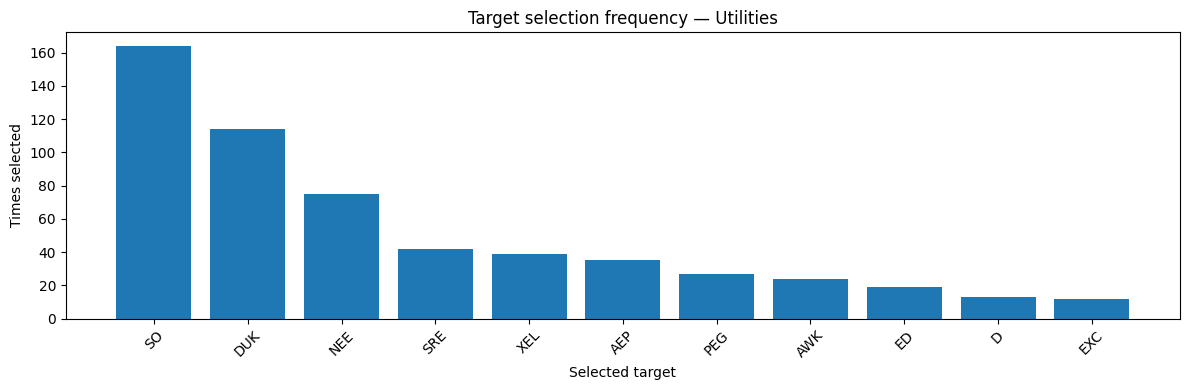

In [32]:
# Cell 15 — plots: target selection frequency
if not selection_summary.empty:
    for sector, sub in selection_summary.groupby("sector"):
        sub = sub.sort_values("times_selected", ascending=False)
        plt.figure(figsize=(12, 4))
        plt.bar(sub["selected_target"], sub["times_selected"])
        plt.title(f"Target selection frequency — {sector}")
        plt.xlabel("Selected target")
        plt.ylabel("Times selected")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


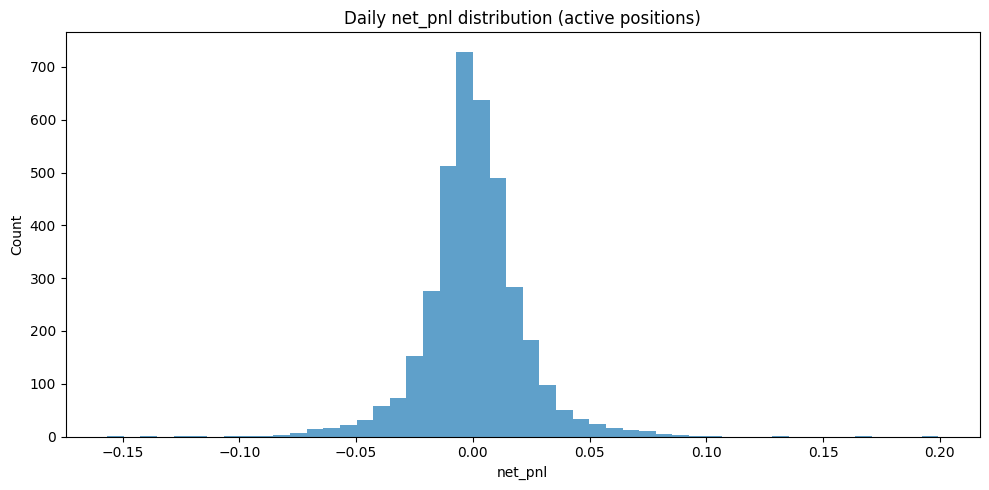

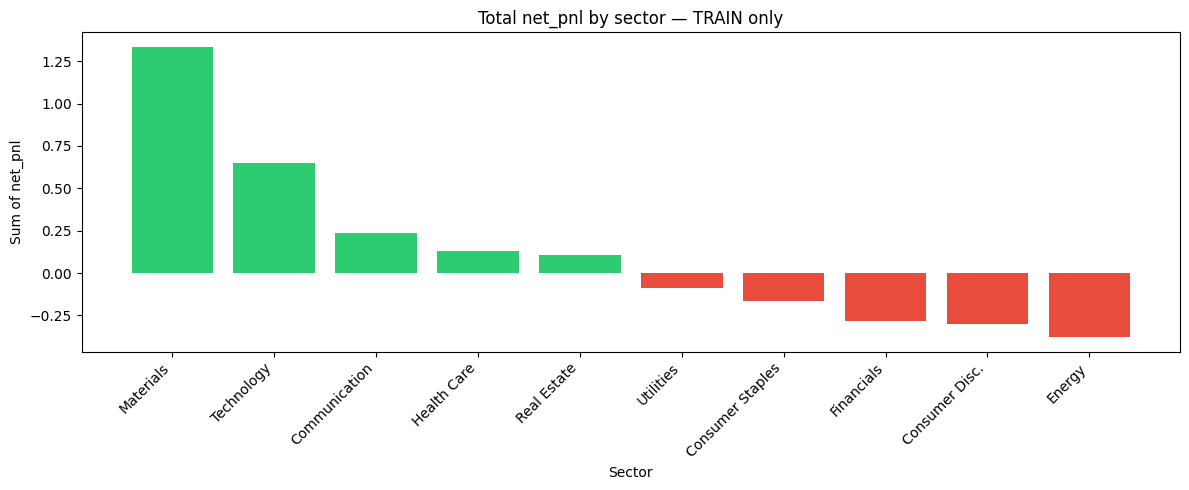

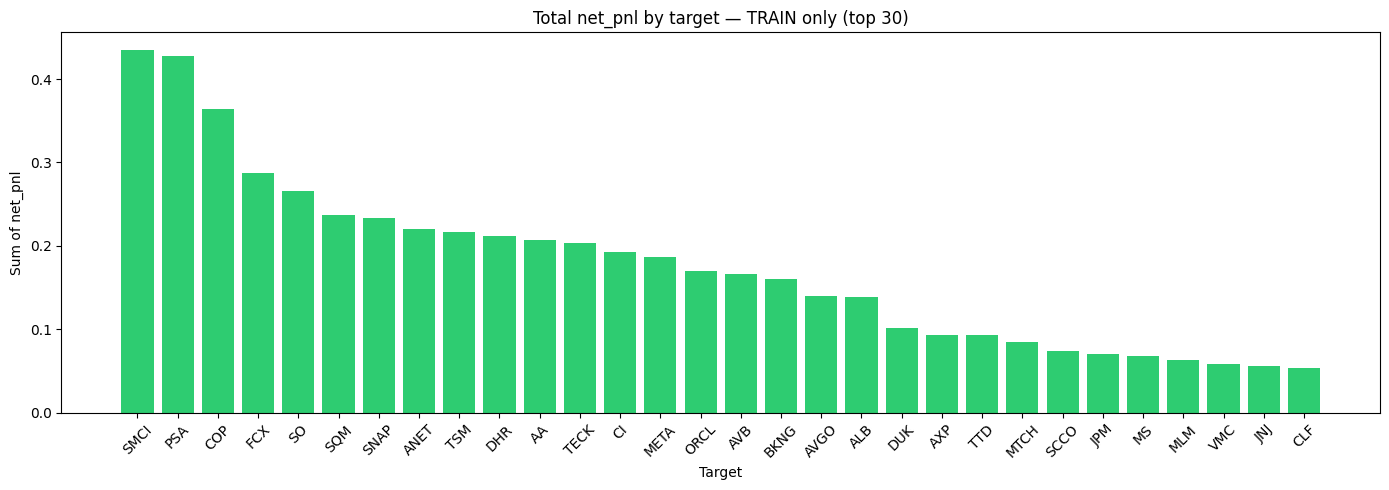

In [33]:
# Cell 16 — PnL by sector and by target

# Daily net_pnl per sector (active days only)
if not active.empty:
    plt.figure(figsize=(10, 5))
    plt.hist(active["net_pnl"].dropna(), bins=50, color="#2980b9", alpha=0.75)
    plt.title("Daily net_pnl distribution (active positions)")
    plt.xlabel("net_pnl"); plt.ylabel("Count"); plt.tight_layout(); plt.show()

pnl_sector = trades.groupby("sector")["net_pnl"].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
plt.bar(pnl_sector.index, pnl_sector.values, color=["#2ecc71" if v >= 0 else "#e74c3c" for v in pnl_sector.values])
plt.title("Total net_pnl by sector — TRAIN only")
plt.xlabel("Sector"); plt.ylabel("Sum of net_pnl")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

pnl_target = trades.groupby("target")["net_pnl"].sum().sort_values(ascending=False).head(30)
plt.figure(figsize=(14, 5))
plt.bar(pnl_target.index, pnl_target.values, color=["#2ecc71" if v >= 0 else "#e74c3c" for v in pnl_target.values])
plt.title("Total net_pnl by target — TRAIN only (top 30)")
plt.xlabel("Target"); plt.ylabel("Sum of net_pnl")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


,sector,selected_target,times_selected,alpha_final,beta_final,bandit_score_final
1,Communication,GOOGL,68,12,6,0.666667
2,Communication,META,78,12,9,0.571429
7,Communication,SNAP,65,16,12,0.571429
5,Communication,PINS,144,18,14,0.562500
3,Communication,MTCH,67,12,11,0.521739
...,...,...,...,...,...,...
100,Utilities,AWK,24,4,8,0.333333
108,Utilities,SRE,42,4,8,0.333333
106,Utilities,PEG,27,2,5,0.285714
101,Utilities,D,13,1,5,0.166667


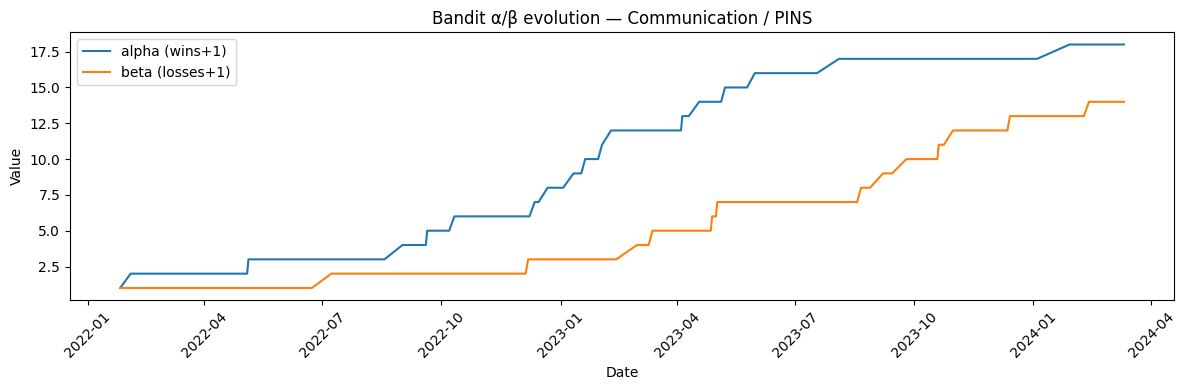

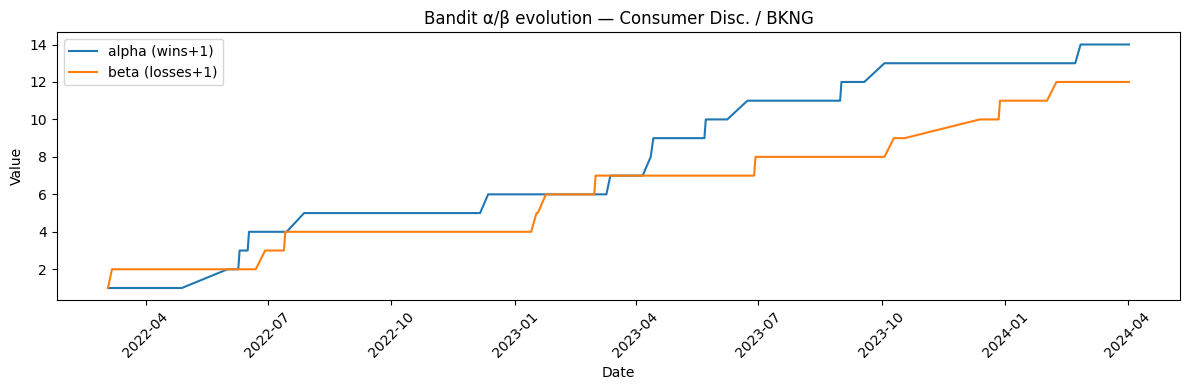

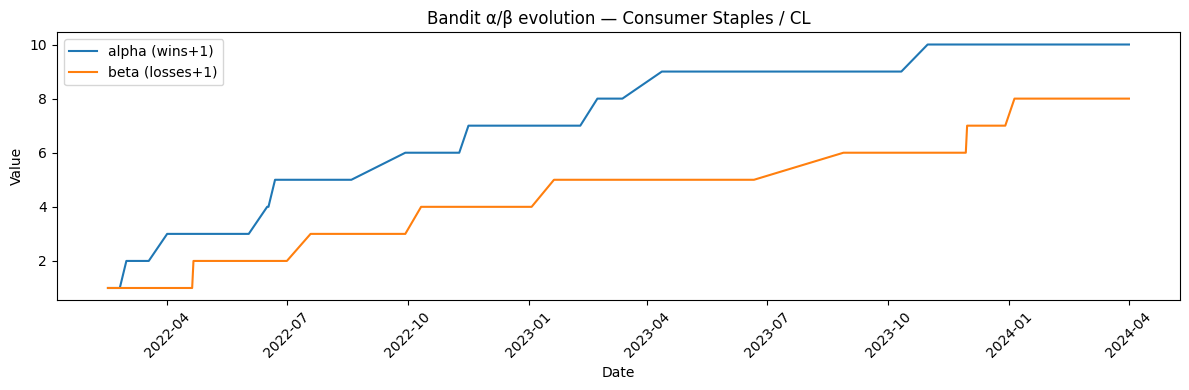

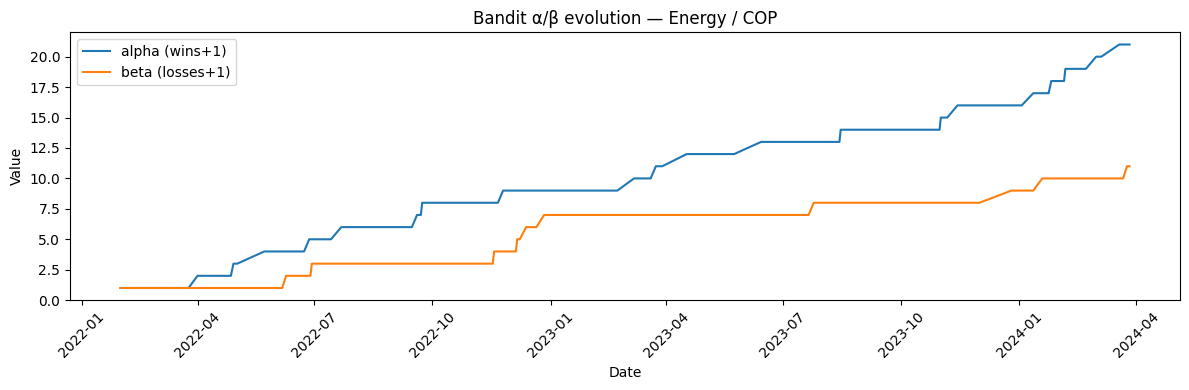

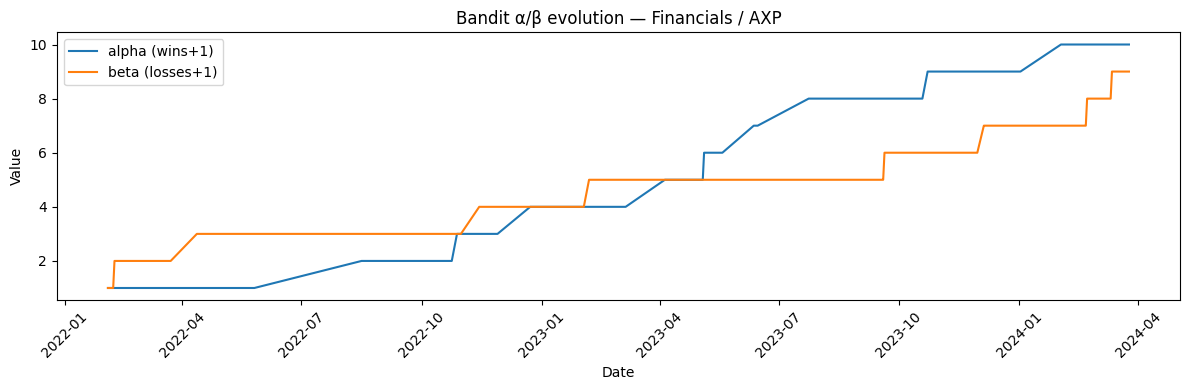

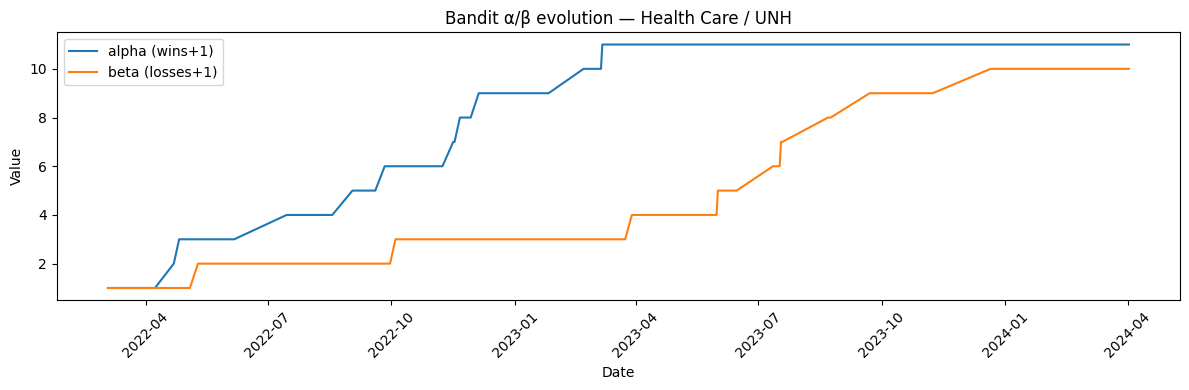

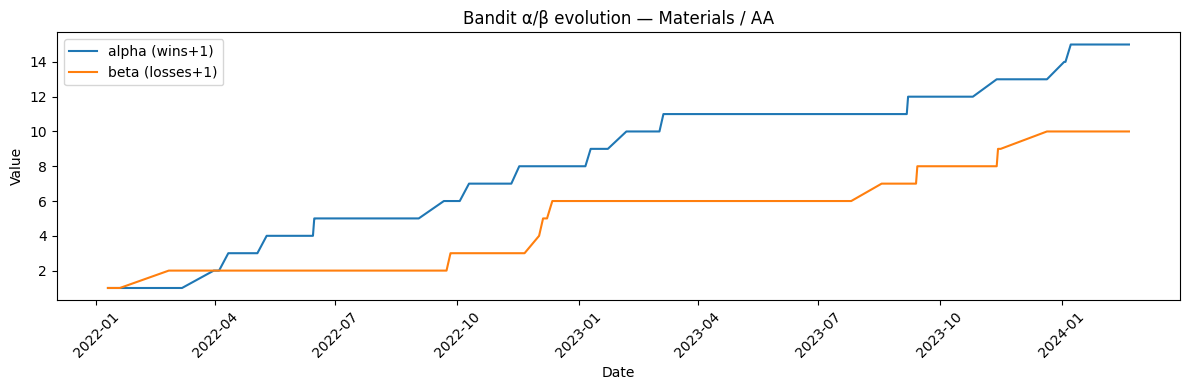

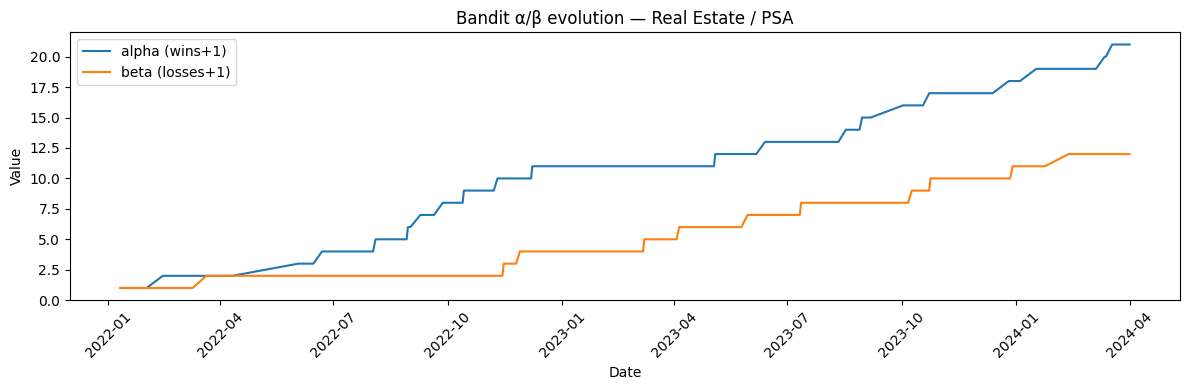

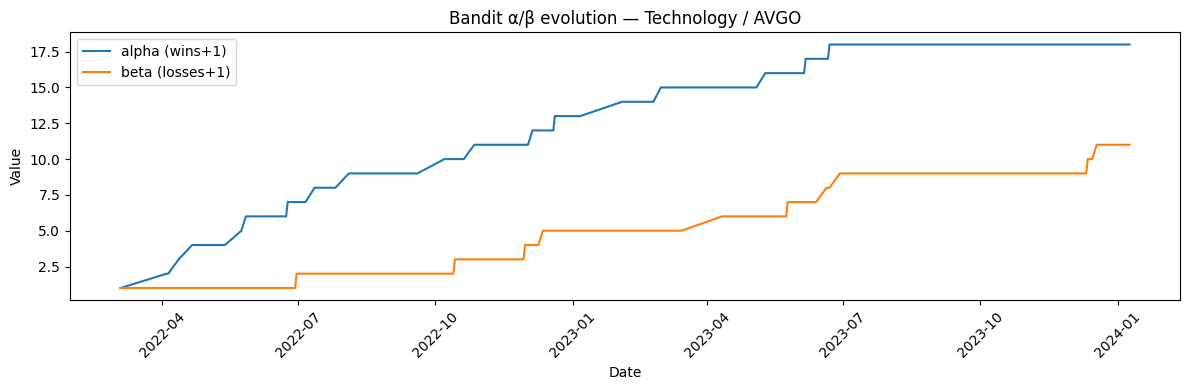

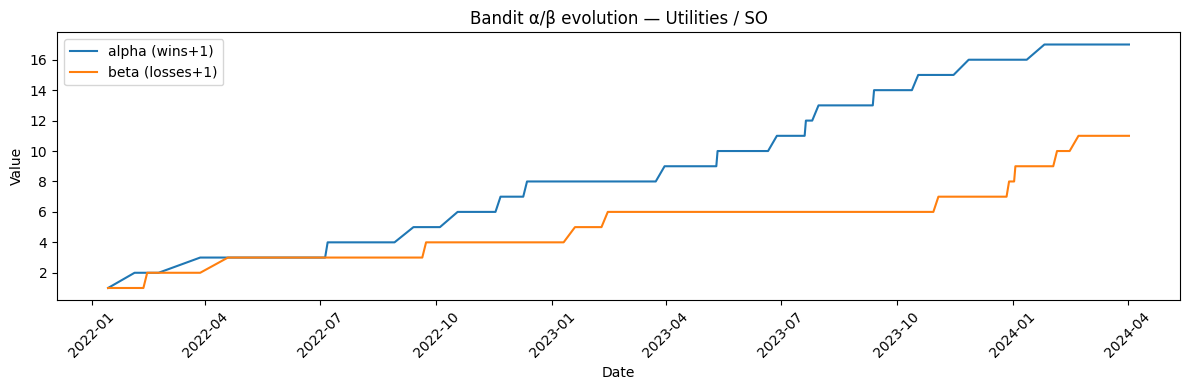

In [34]:
# Cell 17 — bandit diagnostics
if not bandit_states.empty:
    # Summary: alpha/beta progression per sector/target
    bandit_overview = (
        bandit_states.groupby(["sector", "selected_target"])
        .agg(
            times_selected=("selected_target", "size"),
            alpha_final=("alpha_after", "last"),
            beta_final=("beta_after", "last"),
        )
        .reset_index()
    )
    bandit_overview["bandit_score_final"] = (
        bandit_overview["alpha_final"] / (bandit_overview["alpha_final"] + bandit_overview["beta_final"])
    )
    display(bandit_overview.sort_values(["sector", "bandit_score_final"], ascending=[True, False]))

    # Plot alpha/beta evolution for most-selected target in each sector
    for sector, sub in bandit_states.groupby("sector"):
        top_target = sub["selected_target"].value_counts().idxmax()
        ss = sub[sub["selected_target"] == top_target].sort_values("date")
        if len(ss) < 3:
            continue
        plt.figure(figsize=(12, 4))
        plt.plot(ss["date"], ss["alpha_after"], label="alpha (wins+1)")
        plt.plot(ss["date"], ss["beta_after"],  label="beta (losses+1)")
        plt.title(f"Bandit α/β evolution — {sector} / {top_target}")
        plt.xlabel("Date"); plt.ylabel("Value")
        plt.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()


In [35]:
# Cell 18 — sanity checks
sanity = []

sanity.append(("TRAIN_ONLY_MODE active",
               "PASS" if TRAIN_ONLY_MODE else "FAIL"))

sanity.append(("Train tail horizon removed",
               "PASS" if len(train_fit_idx) < len(train_idx) else "FAIL"))

sanity.append(("selected_panel has rows",
               "PASS" if len(selected_panel) > 0 else "FAIL"))

sanity.append(("trades DataFrame has rows",
               "PASS" if len(trades) > 0 else "FAIL"))

# Check selected target is never in its own predictors_used
if "predictors_used" in selected_panel.columns:
    bad = selected_panel.apply(
        lambda r: str(r["target"]) in str(r.get("predictors_used", "")).split(","), axis=1
    ).sum()
    sanity.append(("Selected target excluded from predictors",
                   "PASS" if bad == 0 else f"FAIL ({bad} rows)"))

# NaN check on critical signal columns
nan_rows = int(selected_panel[["P_short", "P_flat", "P_long", "signal"]].isna().any(axis=1).sum())
sanity.append(("No NaN in classifier outputs",
               "PASS" if nan_rows == 0 else f"WARN ({nan_rows} rows)"))

# PM position sanity: position ∈ {-1, 0, 1}
if "position" in trades.columns:
    invalid_pos = int((~trades["position"].isin([-1, 0, 1])).sum())
    sanity.append(("PM positions in {-1,0,1}",
                   "PASS" if invalid_pos == 0 else f"FAIL ({invalid_pos})"))

# net_pnl is finite when position != 0
if "net_pnl" in trades.columns and "position" in trades.columns:
    active_pnl = trades[trades["position"] != 0]["net_pnl"]
    inf_pnl    = int((~np.isfinite(active_pnl.fillna(np.nan))).sum())
    sanity.append(("net_pnl finite when in position",
                   "PASS" if inf_pnl == 0 else f"WARN ({inf_pnl})"))

sanity_df = pd.DataFrame(sanity, columns=["check", "status"])
display(sanity_df)
all_pass = all(s == "PASS" for s in sanity_df["status"])
print("\nAll sanity checks PASS!" if all_pass else "\n⚠ Some checks failed — review above.")


,check,status
0,TRAIN_ONLY_MODE active,PASS
1,Train tail horizon removed,PASS
2,selected_panel has rows,PASS
3,trades DataFrame has rows,PASS
4,Selected target excluded from predictors,PASS
5,No NaN in classifier outputs,PASS
6,"PM positions in {-1,0,1}",PASS
7,net_pnl finite when in position,PASS



All sanity checks PASS!


In [36]:
# Cell 19 — save TRAIN-only outputs
out_dir = PROJECT_ROOT / "outputs"
out_dir.mkdir(exist_ok=True)

# Main outputs
trades.to_csv(out_dir / "dbts_train_trade_log.csv", index=False)
daily_scores.to_csv(out_dir / "dbts_train_daily_target_scores.csv", index=False)
sector_summary.to_csv(out_dir / "dbts_train_sector_summary.csv", index=False)
selection_summary.to_csv(out_dir / "dbts_train_target_selection_summary.csv", index=False)
cm_df.to_csv(out_dir / "dbts_train_confusion_matrix.csv", index=True)
metrics.to_frame("value").to_csv(out_dir / "dbts_train_metrics.csv")
sanity_df.to_csv(out_dir / "dbts_train_sanity_checks.csv", index=False)
selected_panel.to_csv(out_dir / "dbts_train_selected_panel.csv", index=False)

if not completed_trades.empty:
    completed_trades.to_csv(out_dir / "dbts_train_completed_trades.csv", index=False)

if "predictor_summary" in dir() and not predictor_summary.empty:
    predictor_summary.to_csv(out_dir / "dbts_train_predictor_summary.csv", index=False)

saved = [
    "dbts_train_trade_log.csv", "dbts_train_daily_target_scores.csv",
    "dbts_train_sector_summary.csv", "dbts_train_target_selection_summary.csv",
    "dbts_train_confusion_matrix.csv", "dbts_train_metrics.csv",
    "dbts_train_sanity_checks.csv", "dbts_train_selected_panel.csv",
    "dbts_train_completed_trades.csv",
]
print("Saved TRAIN-only DBTS outputs:")
for name in saved:
    p = out_dir / name
    if p.exists():
        print(f"  ✓ {p}")


Saved TRAIN-only DBTS outputs:
  ✓ C:\algo-trading-project\outputs\dbts_train_trade_log.csv
  ✓ C:\algo-trading-project\outputs\dbts_train_daily_target_scores.csv
  ✓ C:\algo-trading-project\outputs\dbts_train_sector_summary.csv
  ✓ C:\algo-trading-project\outputs\dbts_train_target_selection_summary.csv
  ✓ C:\algo-trading-project\outputs\dbts_train_confusion_matrix.csv
  ✓ C:\algo-trading-project\outputs\dbts_train_metrics.csv
  ✓ C:\algo-trading-project\outputs\dbts_train_sanity_checks.csv
  ✓ C:\algo-trading-project\outputs\dbts_train_selected_panel.csv
  ✓ C:\algo-trading-project\outputs\dbts_train_completed_trades.csv


In [37]:
# Cell 20 — conclusion
n_entries   = int(metrics.get("total_entries", 0))
n_long      = int(metrics.get("long_entries", 0))
n_short     = int(metrics.get("short_entries", 0))
sharpe      = metrics.get("sharpe", np.nan)
cum_ret     = metrics.get("cumulative_return", np.nan)
win_rate    = metrics.get("win_rate_days", np.nan)
max_dd      = metrics.get("max_drawdown", np.nan)
active_days = int(metrics.get("active_days", 0))

print("=" * 60)
print("TRAIN-ONLY DIAGNOSTIC SUMMARY")
print("=" * 60)
print(f"  PositionManager entries:  {n_entries:,}  (long {n_long}, short {n_short})")
print(f"  Active-position rows:     {active_days:,}")
print(f"  Completed trades:         {len(completed_trades) if not completed_trades.empty else 0}")
print(f"  Unique selected targets:  {int(selected_panel['target'].nunique())}")
print(f"  Target switches total:    {int(target_switch_summary['target_switches'].sum()) if not target_switch_summary.empty else 0}")
print()
print(f"  Sharpe:             {sharpe:.4f}" if np.isfinite(sharpe) else "  Sharpe:             n/a")
print(f"  Cumulative return:  {cum_ret*100:.2f}%" if np.isfinite(cum_ret) else "  Cumulative return:  n/a")
print(f"  Win rate (days):    {win_rate*100:.1f}%" if np.isfinite(win_rate) else "  Win rate:           n/a")
print(f"  Max drawdown:       {max_dd*100:.2f}%" if np.isfinite(max_dd) else "  Max drawdown:       n/a")
print()
print("Reminder: this is IN-SAMPLE TRAIN ONLY.")
print("Goal: verify the mechanism is alive (can the system earn on data it memorized?).")
print("True OOS evaluation requires running on the held-out test set.")


TRAIN-ONLY DIAGNOSTIC SUMMARY
  PositionManager entries:  1,466  (long 707, short 759)
  Active-position rows:     3,758
  Completed trades:         1466
  Unique selected targets:  110
  Target switches total:    4003

  Sharpe:             0.5391
  Cumulative return:  12.07%
  Win rate (days):    49.3%
  Max drawdown:       -11.69%

Reminder: this is IN-SAMPLE TRAIN ONLY.
Goal: verify the mechanism is alive (can the system earn on data it memorized?).
True OOS evaluation requires running on the held-out test set.


In [38]:

# === FINAL END-TO-END VERIFICATION ===
import pandas as pd
print('All cells executed successfully.')
print(f'  selected_panel: {len(selected_panel):,} rows')
print(f'  trades        : {len(trades):,} rows')
print(f'  completed_trades: {len(completed_trades):,}')
print(f'  bandit_states : {len(bandit_states):,} rows')
print(f'  bandit_updates_applied: {bandit_updates_applied}')
g = (bandit_states.assign(pair=lambda d: list(zip(d['alpha_after'], d['beta_after'])))
                  .groupby(['sector','selected_target'])['pair']
                  .agg(['size','nunique']).reset_index()
                  .rename(columns={'size':'n_dates','nunique':'n_unique'}))
moved = (g.n_unique > 1).sum()
print(f'  bandit pairs with >1 unique state: {moved} / {len(g)}')
assert moved >= len(g) * 0.5, 'Bandit not evolving enough'
print('PASS: notebook runs top-to-bottom and bandit evolves.')


All cells executed successfully.
  selected_panel: 5,640 rows
  trades        : 5,640 rows
  completed_trades: 1,466
  bandit_states : 5,640 rows
  bandit_updates_applied: 1383
  bandit pairs with >1 unique state: 110 / 110
PASS: notebook runs top-to-bottom and bandit evolves.
